# Drosophila Brain LIF Model - FlyWire 783 Connectome

**Reproduction Project Metadata**

| Item | Details |
|------|---------|
| **Original Paper** | Shiu et al. (2024) "A Drosophila computational brain model reveals sensorimotor processing" *Nature* |
| **Reproduction By** | Rui Luo |
| **Completion Date** | **January 10, 2026** |
| **Repository Created** | January 23, 2026 |
| **Connectome Version** | FlyWire v783 (updated from original v630) |
| **Simulator** | Brian2 v2.7 |
| **Language** | Python 3.10 |

---

**Project Status**:
- ✅ Core methodology validated (r=0.85 firing rate correlation)
- ✅ Network construction from FlyWire connectome
- ✅ Basic activation experiments reproduced
- 🔄 Documentation and organization in progress

**Note**: This notebook contains working code with mixed English/Chinese comments. Clean version with full documentation is being prepared.

---

Reproduction based on Philip Shiu's Leaky Integrate-and-Fire model.

**References**: Shiu et al. (2024) "A Drosophila computational brain model reveals sensorimotor processing" Nature

**Data source**: FlyWire proofread version 783

---


## 1. 环境配置与依赖导入

In [2]:
# %%
import numpy as np
import pandas as pd
import pyarrow.feather as feather
from pathlib import Path
from textwrap import dedent
from time import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# Brian2 导入
from brian2 import NeuronGroup, Synapses, PoissonInput, SpikeMonitor, Network,start_scope
from brian2 import mV, ms, Hz
# from brian2 import *

# 可视化
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

#CAVEclient connectome版本id差异
from caveclient import CAVEclient



## 2. 模型参数 (完全遵循 Shiu et al.)


In [3]:
DEFAULT_PARAMS = {
    # trials
    't_run'     : 1000 * ms,              # duration of trial
    'n_run'     : 30,                     # number of runs

    # Kakaria and de Bivort 2017
    'v_0'       : -52 * mV,               # resting potential
    'v_rst'     : -52 * mV,               # reset potential after spike
    'v_th'      : -45 * mV,               # threshold for spiking
    't_mbr'     :  20 * ms,               # membrane time scale

    # Jürgensen et al
    'tau'       : 5 * ms,                 # time constant 

    # Lazar et al
    't_rfc'     : 2.2 * ms,               # refractory period

    # Paul et al 2015
    't_dly'     : 1.8 * ms,               # synaptic delay

    # Free parameter 
    'w_syn'     : .275 * mV,              # weight per synapse
    
    # Activation rates 
    'r_poi'     : 150 * Hz,               # Poisson input rate
    'r_poi2'    :   0 * Hz,               # 2nd Poisson input rate
    'f_poi'     : 250,                    # Poisson scaling factor

    # LIF equations (alpha synapse)
    'eqs'       : dedent(''' 
                    dv/dt = (v_0 - v + g) / t_mbr : volt (unless refractory)
                    dg/dt = -g / tau               : volt (unless refractory) 
                    rfc                            : second
                    '''),
    'eq_th'     : 'v > v_th', 
    'eq_rst'    : 'v = v_rst; w = 0; g = 0 * mV', 
}

## 3. 路径配置 (使用 FlyWire 下载数据)

In [56]:
# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',
    
    # 结果输出
    'path_res': BASE_DIR / 'lif_simulation' / 'results',
}

CONFIG['path_res'].mkdir(parents=True, exist_ok=True)

print("路径配置:")
print(f"  数据目录: {CONFIG['data_dir']}")
print(f"  连接文件: {CONFIG['connections_file']}")
print(f"  Root IDs: {CONFIG['root_ids_file']}")
print(f"  结果目录: {CONFIG['path_res']}")

路径配置:
  数据目录: /Users/charlottel/mylibrary/connectome/lifmodel/data_783
  连接文件: proofread_connections_783.feather
  Root IDs: proofread_root_ids_783.npy
  结果目录: /Users/charlottel/mylibrary/connectome/lifmodel/lif_simulation/results


## 4. 数据加载

In [17]:
client = CAVEclient('flywire_fafb_public')


In [18]:
CLASSIFICATION =  pd.read_csv(Path.home() 
                              / 'mylibrary'/'connectome'/'lifmodel'
                              / 'data_783'/'classification.csv')

In [ ]:
CLASSIFICATION.head(5)

In [5]:
# %%
def load_connectivity_data(filepath, chunk_size=500_000, verbose=True):
    """
    Load connectivity data from feather file using chunk streaming.
    
    使用 FlyWire 官方推荐的 chunk streaming 方法加载大型 feather 文件。
    """
    table = feather.read_table(filepath)
    num_rows = table.num_rows
    col_names = table.column_names
    
    if verbose:
        print(f"   Total rows: {num_rows:,}")
        print(f"   Chunk size: {chunk_size:,}")
    
    # 为每列创建一个列表来收集数据
    col_data = {col: [] for col in col_names}
    
    for i in range(0, num_rows, chunk_size):
        end_row = min(i + chunk_size, num_rows)
        chunk = table.slice(i, end_row - i)
        
        # 逐列提取数据
        for col_name in col_names:
            col = chunk.column(col_name)
            arr = col.combine_chunks()
            
            if str(arr.type) == 'string':
                col_data[col_name].extend(arr.to_pylist())
            else:
                col_data[col_name].append(arr.to_numpy(zero_copy_only=False))
        
        if verbose:
            progress = end_row / num_rows * 100
            print(f"\r   Loading... {progress:5.1f}% ({end_row:,} / {num_rows:,})", end='', flush=True)
    
    if verbose:
        print("\n   Merging chunks...")
    
    # 合并数据
    final_data = {}
    for col_name in col_names:
        if isinstance(col_data[col_name][0], (list, str)):
            final_data[col_name] = col_data[col_name]
        else:
            final_data[col_name] = np.concatenate(col_data[col_name])
    
    result = pd.DataFrame(final_data)
    
    if verbose:
        print("   ✅ Conversion complete")
    
    return result


def load_all_data(config):
    """加载所有数据并创建映射"""
    print("=" * 60)
    print("加载 FlyWire 数据")
    print("=" * 60)
    
    feather_path = config['data_dir'] / config['connections_file']
    npy_path = config['data_dir'] / config['root_ids_file']
    
    # 检查文件
    print(f"\n[检查文件]")
    print(f"   {config['connections_file']}: {'✓' if feather_path.exists() else '✗'}")
    print(f"   {config['root_ids_file']}: {'✓' if npy_path.exists() else '✗'}")
    
    if not (feather_path.exists() and npy_path.exists()):
        raise FileNotFoundError("数据文件缺失，请检查路径")
    
    # 1. 加载 root IDs
    print(f"\n[1/3] 加载 root IDs...")
    root_ids = np.load(npy_path)
    n_neurons = len(root_ids)
    print(f"   神经元数量: {n_neurons:,}")
    
    # 2. 创建 ID 映射
    print(f"\n[2/3] 创建 ID 映射...")
    flyid2i = {int(rid): i for i, rid in enumerate(root_ids)}
    i2flyid = {i: int(rid) for i, rid in enumerate(root_ids)}
    print(f"   ✅ 映射创建完成")
    
    # 3. 加载连接数据
    print(f"\n[3/3] 加载连接数据...")
    df_conn = load_connectivity_data(feather_path, chunk_size=500_000, verbose=True)
    
    # 显示数据信息
    print(f"\n[数据概览]")
    print(f"   列名: {df_conn.columns.tolist()}")
    print(f"   连接数: {len(df_conn):,}")
    print(f"\n   前3行:")
    print(df_conn.head(3).to_string())
    
    return {
        'root_ids': root_ids,
        'n_neurons': n_neurons,
        'flyid2i': flyid2i,
        'i2flyid': i2flyid,
        'df_conn': df_conn,
    }

# 加载数据
DATA = load_all_data(CONFIG)

# %%
# 识别数据列名
def identify_columns(df_conn):
    """自动识别连接数据的列名"""
    cols = df_conn.columns.tolist()
    
    pre_col = next((c for c in cols if 'pre' in c.lower() and 'root' in c.lower()), None)
    post_col = next((c for c in cols if 'post' in c.lower() and 'root' in c.lower()), None)
    
    # 权重列
    weight_col = None
    for c in cols:
        cl = c.lower()
        if 'syn_count' in cl or 'neuropil_synapse_count' in cl:
            weight_col = c
            break
    
    # 神经递质概率列 (6种)
    nt_prob_cols = {
        'gaba': next((c for c in cols if 'gaba' in c.lower()), None),
        'ach': next((c for c in cols if 'ach' in c.lower()), None),
        'glut': next((c for c in cols if 'glut' in c.lower()), None),
        'oct': next((c for c in cols if 'oct' in c.lower()), None),
        'ser': next((c for c in cols if 'ser' in c.lower()), None),
        'da': next((c for c in cols if '_da' in c.lower() or c.lower() == 'da_avg'), None),
    }
    
    print(f"识别到的列:")
    print(f"   预突触 ID 列: {pre_col}")
    print(f"   后突触 ID 列: {post_col}")
    print(f"   权重列 (syn_count): {weight_col}")
    print(f"   神经递质概率列:")
    for nt, col in nt_prob_cols.items():
        print(f"      {nt}: {col}")
    
    return pre_col, post_col, weight_col, nt_prob_cols

PRE_COL, POST_COL, WEIGHT_COL, NT_PROB_COLS = identify_columns(DATA['df_conn'])

加载 FlyWire 数据

[检查文件]
   proofread_connections_783.feather: ✓
   proofread_root_ids_783.npy: ✓

[1/3] 加载 root IDs...
   神经元数量: 139,255

[2/3] 创建 ID 映射...
   ✅ 映射创建完成

[3/3] 加载连接数据...
   Total rows: 16,847,997
   Chunk size: 500,000
   Loading... 100.0% (16,847,997 / 16,847,997)
   Merging chunks...
   ✅ Conversion complete

[数据概览]
   列名: ['pre_pt_root_id', 'post_pt_root_id', 'neuropil', 'syn_count', 'gaba_avg', 'ach_avg', 'glut_avg', 'oct_avg', 'ser_avg', 'da_avg']
   连接数: 16,847,997

   前3行:
       pre_pt_root_id     post_pt_root_id neuropil  syn_count  gaba_avg   ach_avg  glut_avg   oct_avg   ser_avg    da_avg
0  720575940629970489  720575940631267655   AVLP_R          7  0.654330  0.023704  0.272418  0.048125  0.000472  0.000951
1  720575940623828999  720575940612348950    SLP_R          4  0.386517  0.024020  0.580512  0.000817  0.000857  0.007278
2  720575940624078484  720575940616950161    SMP_R          2  0.001719  0.979256  0.001811  0.000016  0.005870  0.011328
识别到的列:
   预突触 

# **task3 test

In [26]:
# 测试1: 导入
from flylif.core.data_loader import load_all_data, identify_columns, validate_data
print("✓ 成功导入数据加载模块")

✓ 成功导入数据加载模块


In [27]:
# 测试2: 加载数据
from pathlib import Path

DATA_NEW = load_all_data(
    data_dir=Path.home() / 'mylibrary' / 'connectome' / 'lifmodel' / 'data_783',
    connections_file='proofread_connections_783.feather',
    root_ids_file='proofread_root_ids_783.npy',
    verbose=True
)

Loading FlyWire Data

[Checking files]
  proofread_connections_783.feather: ✓
  proofread_root_ids_783.npy: ✓

[1/3] Loading root IDs...
  Neurons: 139,255

[2/3] Creating ID mappings...
  ✅ Mapping created

[3/3] Loading connectivity data...

[Loading connectivity data]
  File: proofread_connections_783.feather
  Total rows: 16,847,997
  Chunk size: 500,000
  Loading... 100.0% (16,847,997 / 16,847,997)
  Merging chunks...
  ✅ Conversion complete
  Shape: (16847997, 10)

[Data overview]
  Columns: ['pre_pt_root_id', 'post_pt_root_id', 'neuropil', 'syn_count', 'gaba_avg', 'ach_avg', 'glut_avg', 'oct_avg', 'ser_avg', 'da_avg']
  Connections: 16,847,997

  First 3 rows:
       pre_pt_root_id     post_pt_root_id neuropil  syn_count  gaba_avg   ach_avg  glut_avg   oct_avg   ser_avg    da_avg
0  720575940629970489  720575940631267655   AVLP_R          7  0.654330  0.023704  0.272418  0.048125  0.000472  0.000951
1  720575940623828999  720575940612348950    SLP_R          4  0.386517  0.02402

In [28]:
# 测试3: 验证数据完整性
print("\n✓ 数据加载完成")
print(f"  神经元: {DATA_NEW['n_neurons']:,}")
print(f"  连接: {len(DATA_NEW['df_conn']):,}")


✓ 数据加载完成
  神经元: 139,255
  连接: 16,847,997


In [30]:
# 测试4: 自动识别列名
PRE_COL, POST_COL, WEIGHT_COL, NT_PROB_COLS = identify_columns(DATA_NEW['df_conn'])


[Identified columns]
  Presynaptic ID: pre_pt_root_id
  Postsynaptic ID: post_pt_root_id
  Weight (syn_count): syn_count
  Neurotransmitter probabilities:
    gaba: gaba_avg
    ach: ach_avg
    glut: glut_avg
    oct: oct_avg
    ser: ser_avg
    da: da_avg


In [29]:
# 测试5: 数据验证
validate_data(DATA_NEW)

# 测试6: 与原notebook数据一致性检查
assert DATA_NEW['n_neurons'] == DATA['n_neurons'], "神经元数量不一致"
assert len(DATA_NEW['df_conn']) == len(DATA['df_conn']), "连接数量不一致"
print("\n✓ 与原notebook数据完全一致")

# 测试7: 测试工具函数
from flylif.core.data_loader import print_data_summary, get_neuron_connections
print_data_summary(DATA_NEW)

# 测试8: 查询单个神经元的连接
test_neuron_id = NEU_SUGAR_LEFT[0]
df_pre, df_post = get_neuron_connections(DATA_NEW, test_neuron_id, direction='both')
print(f"\n✓ 神经元 {test_neuron_id}:")
print(f"  输出连接: {len(df_pre)}")
print(f"  输入连接: {len(df_post)}")

# 测试9: 快速加载（使用默认路径）
from flylif.core.data_loader import quick_load
DATA_QUICK = quick_load(version='783', verbose=False)
print(f"\n✓ 快速加载: {DATA_QUICK['n_neurons']:,} 神经元")


[Validating data]
  ✓ Neuron count consistent: 139,255
  ✓ ID mappings consistent
  ✓ Connectivity data: 16,847,997 connections
  ✓ No NaN in critical columns
  ✅ All validations passed

✓ 与原notebook数据完全一致
Data Summary

Neurons: 139,255
  Root IDs shape: (139255,)

Connectivity:
  Total connections: 16,847,997
  Columns: 10

Synapse counts:
  Min: 1
  Max: 2405
  Mean: 3.2

Unique neurons:
  Presynaptic: 138,005
  Postsynaptic: 137,090

✓ 神经元 720575940624963786:
  输出连接: 88
  输入连接: 35

✓ 快速加载: 139,255 神经元



## 5. 构建网络

In [8]:


# %% 5.1 神经元类型判定 (保持不变，已优化)
# -----------------------------------------------------------------------------

def determine_neuron_types_fast(df_conn, pre_col, nt_prob_cols, flyid2i, verbose=True):
    """快速判定神经元类型 - 向量化实现"""
    if verbose:
        print(f"   判定神经元类型...")
        t0 = time()
    
    gaba_col = nt_prob_cols.get('gaba')
    glut_col = nt_prob_cols.get('glut')
    
    if gaba_col is None and glut_col is None:
        if verbose:
            print(f"   ⚠️  无GABA/Glut列，默认兴奋性")
        return {}
    
    pre_ids = df_conn[pre_col].values
    
    # 计算抑制性概率
    inhib_prob = np.zeros(len(df_conn), dtype=np.float32)
    if gaba_col and gaba_col in df_conn.columns:
        inhib_prob += df_conn[gaba_col].values.astype(np.float32)
    if glut_col and glut_col in df_conn.columns:
        inhib_prob += df_conn[glut_col].values.astype(np.float32)
    
    is_inhib_synapse = inhib_prob > 0.5
    
    # pandas groupby 聚合
    df_temp = pd.DataFrame({'pre_id': pre_ids, 'is_inhib': is_inhib_synapse})
    neuron_inhib_ratio = df_temp.groupby('pre_id')['is_inhib'].mean()
    
    # 构建结果
    neuron_signs = {}
    n_exc, n_inh = 0, 0
    
    for pre_id, ratio in neuron_inhib_ratio.items():
        pre_id_int = int(pre_id)
        if pre_id_int in flyid2i:
            neuron_idx = flyid2i[pre_id_int]
            if ratio > 0.5:
                neuron_signs[neuron_idx] = -1
                n_inh += 1
            else:
                neuron_signs[neuron_idx] = 1
                n_exc += 1
    
    if verbose:
        print(f"   兴奋性: {n_exc:,}, 抑制性: {n_inh:,} ({time()-t0:.1f}s)")
    
    return neuron_signs

# %% 5.2 构建网络 (优化版)
# -----------------------------------------------------------------------------

def build_network(data, pre_col, post_col, weight_col, nt_prob_cols, params, 
                  syn_threshold=5, verbose=True):
    """
    预构建 Brian2 网络并保存初始状态 (优化版)
    
    优化:
    1. 神经元类型判定使用向量化
    2. 突触索引预计算使用numpy
    3. 保存原始权重数组用于快速沉默
    """
    start_scope()
    
    if verbose:
        print("=" * 60)
        print("构建 Brian2 网络 (优化版)")
        print("=" * 60)
    
    n_neurons = data['n_neurons']
    flyid2i = data['flyid2i']
    i2flyid = data['i2flyid']
    df_conn = data['df_conn']
    
    # Step 1: 筛选连接
    if verbose:
        print(f"\n[1/7] 筛选连接 (syn_count >= {syn_threshold})")
        t0 = time()
    
    n_before = len(df_conn)
    if weight_col:
        valid_syn_mask = df_conn[weight_col].values >= syn_threshold
        df_conn_filtered = df_conn[valid_syn_mask].copy()
    else:
        df_conn_filtered = df_conn.copy()
    
    n_after = len(df_conn_filtered)
    if verbose:
        print(f"   {n_before:,} -> {n_after:,} ({100*n_after/n_before:.1f}%)")
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # Step 2: 判定神经元类型 (优化版)
    if verbose:
        print(f"\n[2/7] 判定神经元类型")
    neuron_signs = determine_neuron_types_fast(
        df_conn_filtered, pre_col, nt_prob_cols, flyid2i, verbose
    )
    
    # Step 3: 处理连接数据
    if verbose:
        print(f"\n[3/7] 处理连接数据")
        t0 = time()
    
    pre_ids = df_conn_filtered[pre_col].values
    post_ids = df_conn_filtered[post_col].values
    
    # 向量化验证
    pre_ids_int = pre_ids.astype(np.int64)
    post_ids_int = post_ids.astype(np.int64)
    
    # 创建快速查找集合
    valid_ids_set = set(flyid2i.keys())
    
    # 向量化检查
    pre_valid = np.array([int(p) in valid_ids_set for p in pre_ids_int])
    post_valid = np.array([int(p) in valid_ids_set for p in post_ids_int])
    valid_mask = pre_valid & post_valid
    
    n_valid = np.sum(valid_mask)
    if verbose:
        print(f"   有效连接: {n_valid:,} / {len(pre_ids):,}")
    
    # 提取有效连接
    valid_pre_ids = pre_ids_int[valid_mask]
    valid_post_ids = post_ids_int[valid_mask]
    
    # 映射到索引 (向量化)
    i_pre = np.array([flyid2i[int(p)] for p in valid_pre_ids], dtype=np.int32)
    i_post = np.array([flyid2i[int(p)] for p in valid_post_ids], dtype=np.int32)
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # Step 4: 计算突触权重
    if verbose:
        print(f"\n[4/7] 计算突触权重")
        t0 = time()
    
    if weight_col:
        weights_raw = df_conn_filtered[weight_col].values[valid_mask].astype(np.float64)
    else:
        weights_raw = np.ones(n_valid, dtype=np.float64)
    
    # 向量化获取符号
    default_sign = 1
    signs = np.array([neuron_signs.get(idx, default_sign) for idx in i_pre], dtype=np.float64)
    weights = weights_raw * signs
    
    n_exc_syn = np.sum(signs > 0)
    n_inh_syn = np.sum(signs < 0)
    if verbose:
        print(f"   兴奋性突触: {n_exc_syn:,}, 抑制性突触: {n_inh_syn:,}")
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # Step 5: 预计算突触索引 (优化版 - 使用numpy)
    if verbose:
        print(f"\n[5/7] 预计算突触索引")
        t0 = time()
    
    # 使用numpy的高效分组
    # 为每个神经元找到其作为pre的所有突触索引
    unique_pre, inverse_pre = np.unique(i_pre, return_inverse=True)
    
    # 创建索引映射
    pre_syn_indices = {}
    syn_indices = np.arange(n_valid, dtype=np.int64)
    
    for i, neu_idx in enumerate(unique_pre):
        mask = inverse_pre == i
        pre_syn_indices[neu_idx] = syn_indices[mask].copy()
    
    if verbose:
        print(f"   有输出突触的神经元: {len(pre_syn_indices):,}")
        avg_synapses = np.mean([len(v) for v in pre_syn_indices.values()])
        print(f"   平均输出突触/神经元: {avg_synapses:.1f}")
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # Step 6: 创建神经元群和突触
    if verbose:
        print(f"\n[6/7] 创建神经元群 (n={n_neurons:,})")
        t0 = time()
    
    neu = NeuronGroup(
        N=n_neurons,
        model=params['eqs'],
        method='linear',
        threshold=params['eq_th'],
        reset=params['eq_rst'],
        refractory='rfc',
        name='neurons',
        namespace=params,
    )
    neu.v = params['v_0']
    neu.g = 0
    neu.rfc = params['t_rfc']
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    if verbose:
        print(f"\n[6/7] 创建突触 (n={n_valid:,})")
        print(f"   ⚠️  这一步需要几分钟...")
        t0 = time()
    
    syn = Synapses(neu, neu, 'w : volt', on_pre='g += w',
                   delay=params['t_dly'], name='synapses')
    syn.connect(i=i_pre, j=i_post)
    
    # 计算最终权重 (含 w_syn)
    weights_final = weights * float(params['w_syn'] / mV) * mV
    syn.w = weights_final
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # Step 7: 创建 Network 并保存状态
    if verbose:
        print(f"\n[7/7] 创建 Network 并保存初始状态")
        t0 = time()
    
    net = Network(neu, syn)
    net.store('initial')
    
    if verbose:
        print(f"   ✅ 初始状态已保存")
        print(f"   ⏱️  {time()-t0:.1f} 秒")
    
    # 准备权重数组用于快速沉默
    weights_array = np.array(syn.w / mV, dtype=np.float64)  # 转为numpy数组
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"✅ 网络构建完成!")
        print(f"   神经元: {n_neurons:,}")
        print(f"   突触: {n_valid:,}")
        print(f"{'='*60}")
    
    return {
        'net': net,
        'neu': neu,
        'syn': syn,
        'n_neurons': n_neurons,
        'n_synapses': n_valid,
        'flyid2i': flyid2i,
        'i2flyid': i2flyid,
        'params': params.copy(),
        # 沉默实验所需
        'i_pre': i_pre,
        'i_post': i_post,
        'pre_syn_indices': pre_syn_indices,
        'weights_original': weights,  # 不含w_syn的原始权重
        'weights_array': weights_array,  # 当前权重数组 (mV)
        'neuron_signs': neuron_signs,
        'syn_threshold': syn_threshold,
    }


# %% 5.3 运行仿真 (优化版)
# -----------------------------------------------------------------------------

def run_simulation(net_components, neu_exc, neu_exc2=None, neu_slnc=None,
                   params=None, duration=None, n_trials=None, verbose=True):
    """
    运行模拟 (优化版)
    
    优化:
    1. 沉默使用预计算索引直接设置权重
    2. 减少不必要的对象创建
    3. 批量处理spike数据
    
    Parameters
    ----------
    net_components : dict
        build_network() 返回的网络组件
    neu_exc : list
        要激活的神经元 FlyWire IDs (使用 r_poi)
    neu_exc2 : list, optional
        第二组激活神经元 (使用 r_poi2)
    neu_slnc : list, optional
        要沉默的神经元 FlyWire IDs
    params : dict, optional
        可覆盖的参数 (如 r_poi, t_run 等)
    duration : Quantity, optional
        模拟时长
    n_trials : int, optional
        重复次数
    verbose : bool
        是否打印信息
    """
    neu_exc2 = neu_exc2 or []
    neu_slnc = neu_slnc or []
    
    net = net_components['net']
    neu = net_components['neu']
    syn = net_components['syn']
    flyid2i = net_components['flyid2i']
    i2flyid = net_components['i2flyid']
    pre_syn_indices = net_components['pre_syn_indices']
    weights_array = net_components['weights_array']
    
    # 合并参数
    sim_params = net_components['params'].copy()
    if params:
        sim_params.update(params)
    
    if duration is None:
        duration = sim_params['t_run']
    if n_trials is None:
        n_trials = sim_params['n_run']
    
    # 转换 FlyWire ID 到索引
    exc = [flyid2i[n] for n in neu_exc if n in flyid2i]
    exc2 = [flyid2i[n] for n in neu_exc2 if n in flyid2i]
    slnc = [flyid2i[n] for n in neu_slnc if n in flyid2i]
    
    if verbose:
        print(f"\n>>> 仿真配置")
        print(f"    激活: {len(exc)}, 激活2: {len(exc2)}, 沉默: {len(slnc)}")
        print(f"    时长: {duration}, Trials: {n_trials}")
        print(f"    频率: {sim_params['r_poi']}")
    
    # ========== 预计算沉默突触索引 ==========
    slnc_syn_indices = []
    for neuron_idx in slnc:
        if neuron_idx in pre_syn_indices:
            slnc_syn_indices.extend(pre_syn_indices[neuron_idx])
    
    slnc_syn_indices = np.array(slnc_syn_indices, dtype=np.int64) if slnc_syn_indices else np.array([], dtype=np.int64)
    
    if verbose and len(slnc) > 0:
        print(f"    沉默突触: {len(slnc_syn_indices)}")
    
    # 预存原始权重 (用于恢复)
    if len(slnc_syn_indices) > 0:
        original_weights_slnc = weights_array[slnc_syn_indices].copy()
    
    # 运行trials
    all_spike_data = []
    
    if verbose:
        print(f"    🚀 运行中...")
        t0_total = time().time()
    
    for trial_idx in range(n_trials):
        t0_trial = time()
        
        # Step 1: 恢复网络状态
        net.restore('initial')
        
        # Step 2: 应用沉默 (直接设置权重数组)
        if len(slnc_syn_indices) > 0:
            syn.w[slnc_syn_indices] = 0 * mV
        
        # Step 3: 创建监视器和输入
        spk_mon = SpikeMonitor(neu)
        
        pois = []
        for i in exc:
            p = PoissonInput(
                target=neu[i], 
                target_var='v', 
                N=1,
                rate=sim_params['r_poi'], 
                weight=sim_params['w_syn'] * sim_params['f_poi']
            )
            neu[i].rfc = 0 * ms
            pois.append(p)
        
        for i in exc2:
            p = PoissonInput(
                target=neu[i], 
                target_var='v', 
                N=1,
                rate=sim_params['r_poi2'], 
                weight=sim_params['w_syn'] * sim_params['f_poi']
            )
            neu[i].rfc = 0 * ms
            pois.append(p)
        
        # Step 4: 运行
        net.add(spk_mon, *pois)
        net.run(duration)
        
        # Step 5: 提取结果 (批量处理)
        spike_i = np.array(spk_mon.i)
        spike_t = np.array(spk_mon.t)
        
        if len(spike_i) > 0:
            trial_data = pd.DataFrame({
                't': spike_t,
                'trial': trial_idx,
                'neuron_idx': spike_i
            })
            all_spike_data.append(trial_data)
        
        # Step 6: 清理
        net.remove(spk_mon, *pois)
        
        trial_time = time() - t0_trial
        if verbose:
            print(f"\r    Trial {trial_idx + 1}/{n_trials} ({trial_time:.1f}s)", end='', flush=True)
    
    if verbose:
        total_time = time() - t0_total
        print(f"\n    ⏱️  总时间: {total_time:.1f}s ({total_time/n_trials:.1f}s/trial)")
    
    # 合并所有trial数据
    if all_spike_data:
        df = pd.concat(all_spike_data, ignore_index=True)
        df['flywire_id'] = df['neuron_idx'].map(i2flyid)
        df = df[['t', 'trial', 'flywire_id']]
    else:
        df = pd.DataFrame(columns=['t', 'trial', 'flywire_id'])
    
    n_spikes = len(df)
    n_active = df['flywire_id'].nunique() if n_spikes > 0 else 0
    
    if verbose:
        print(f"    📊 Spikes: {n_spikes:,}, 活跃神经元: {n_active:,}")
    
    return {
        'df': df,
        'n_spikes': n_spikes,
        'n_active': n_active,
        'n_trials': n_trials,
        'duration': duration,
        'stim_neurons': neu_exc,
        'silenced_neurons': neu_slnc,
        'params_used': sim_params,
    }


# %% 5.4 快速沉默实验专用函数
# -----------------------------------------------------------------------------

def run_silencing_batch(net_components, neu_exc, neurons_to_silence, target_neurons,
                        freq, n_trials=1, verbose=True):
    """
    批量沉默实验 - 针对单一频率优化
    
    对于沉默实验，主要耗时在于:
    1. 每次restore网络
    2. 每次创建PoissonInput
    
    优化策略:
    - 单频率批量运行
    - 减少打印输出
    
    Parameters
    ----------
    net_components : dict
        网络组件
    neu_exc : list
        激活的神经元
    neurons_to_silence : list
        要逐个沉默的神经元列表
    target_neurons : list
        监测的目标神经元
    freq : float
        激活频率 (Hz)
    n_trials : int
        每个沉默条件的trial数
    
    Returns
    -------
    dict : {neuron_id: {target_id: firing_rate}}
    """
    flyid2i = net_components['flyid2i']
    i2flyid = net_components['i2flyid']
    pre_syn_indices = net_components['pre_syn_indices']
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    
    results = {}
    n_total = len(neurons_to_silence)
    
    if verbose:
        print(f"\n  批量沉默: {n_total} 神经元 @ {freq} Hz")
        t0 = time()
    
    # 转换目标神经元索引
    target_indices = {flyid2i[t]: t for t in target_neurons if t in flyid2i}
    
    for idx, slnc_id in enumerate(neurons_to_silence):
        # 运行沉默仿真
        result = run_simulation(
            net_components=net_components,
            neu_exc=neu_exc,
            neu_slnc=[slnc_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=False
        )
        
        df = result['df']
        
        # 计算目标神经元发放率
        target_rates = {}
        for tid in target_neurons:
            if len(df) > 0:
                count = len(df[df['flywire_id'] == tid])
                target_rates[tid] = count / (n_trials * duration_s)
            else:
                target_rates[tid] = 0.0
        
        results[slnc_id] = target_rates
        
        # 进度显示
        if verbose and (idx + 1) % 5 == 0:
            elapsed = time() - t0
            speed = (idx + 1) / elapsed
            eta = (n_total - idx - 1) / speed
            print(f"\r    进度: {idx+1}/{n_total} ({elapsed:.0f}s, ETA: {eta:.0f}s)", end='', flush=True)
    
    if verbose:
        print(f"\n    ✅ 完成 ({time()-t0:.1f}s)")
    
    return results

In [9]:
# %% 5.5 优化突触索引预计算
# -----------------------------------------------------------------------------
# 替换 build_network 中的 Step 5

def build_network(data, pre_col, post_col, weight_col, nt_prob_cols, params, 
                  syn_threshold=5, verbose=True):
    """
    预构建 Brian2 网络并保存初始状态 (优化版 v2)
    
    优化:
    1. 神经元类型判定使用向量化
    2. 突触索引预计算使用 pandas groupby (更快)
    3. 保存原始权重数组用于快速沉默
    """
    start_scope()
    
    if verbose:
        print("=" * 60)
        print("构建 Brian2 网络 (优化版 v2)")
        print("=" * 60)
    
    n_neurons = data['n_neurons']
    flyid2i = data['flyid2i']
    i2flyid = data['i2flyid']
    df_conn = data['df_conn']
    
    # Step 1: 筛选连接
    if verbose:
        print(f"\n[1/7] 筛选连接 (syn_count >= {syn_threshold})")
        t0 = time()
    
    n_before = len(df_conn)
    if weight_col:
        valid_syn_mask = df_conn[weight_col].values >= syn_threshold
        df_conn_filtered = df_conn[valid_syn_mask].copy()
    else:
        df_conn_filtered = df_conn.copy()
    
    n_after = len(df_conn_filtered)
    if verbose:
        print(f"   {n_before:,} -> {n_after:,} ({100*n_after/n_before:.1f}%)")
        print(f"   ⏱️  {time()-t0:.1f}s")
    
    # Step 2: 判定神经元类型 (优化版)
    if verbose:
        print(f"\n[2/7] 判定神经元类型")
    neuron_signs = determine_neuron_types_fast(
        df_conn_filtered, pre_col, nt_prob_cols, flyid2i, verbose
    )
    
    # Step 3: 处理连接数据
    if verbose:
        print(f"\n[3/7] 处理连接数据")
        t0 = time()
    
    pre_ids = df_conn_filtered[pre_col].values.astype(np.int64)
    post_ids = df_conn_filtered[post_col].values.astype(np.int64)
    
    # 创建快速查找集合
    valid_ids_set = set(flyid2i.keys())
    
    # 向量化检查 - 使用 numpy isin (如果ID范围合适) 或集合查找
    if verbose:
        print(f"   检查有效连接...")
        t1 = time()
    
    pre_valid = np.fromiter((p in valid_ids_set for p in pre_ids), dtype=bool, count=len(pre_ids))
    post_valid = np.fromiter((p in valid_ids_set for p in post_ids), dtype=bool, count=len(post_ids))
    valid_mask = pre_valid & post_valid
    
    n_valid = np.sum(valid_mask)
    if verbose:
        print(f"   有效连接: {n_valid:,} / {len(pre_ids):,}")
        print(f"   ⏱️  {time()-t1:.1f}s")
    
    # 提取有效连接
    valid_pre_ids = pre_ids[valid_mask]
    valid_post_ids = post_ids[valid_mask]
    
    # 映射到索引
    if verbose:
        print(f"   映射索引...")
        t1 = time()
    
    # 使用 numpy 向量化映射 (比列表推导快)
    flyid_keys = np.array(list(flyid2i.keys()), dtype=np.int64)
    flyid_vals = np.array(list(flyid2i.values()), dtype=np.int32)
    
    # 创建排序索引用于快速查找
    sort_idx = np.argsort(flyid_keys)
    sorted_keys = flyid_keys[sort_idx]
    sorted_vals = flyid_vals[sort_idx]
    
    # 使用 searchsorted 进行快速映射
    pre_positions = np.searchsorted(sorted_keys, valid_pre_ids)
    post_positions = np.searchsorted(sorted_keys, valid_post_ids)
    
    i_pre = sorted_vals[pre_positions].astype(np.int32)
    i_post = sorted_vals[post_positions].astype(np.int32)
    
    if verbose:
        print(f"   ⏱️  {time()-t1:.1f}s")
        print(f"   总时间: {time()-t0:.1f}s")
    
    # Step 4: 计算突触权重
    if verbose:
        print(f"\n[4/7] 计算突触权重")
        t0 = time()
    
    if weight_col:
        weights_raw = df_conn_filtered[weight_col].values[valid_mask].astype(np.float64)
    else:
        weights_raw = np.ones(n_valid, dtype=np.float64)
    
    # 向量化获取符号 - 使用 numpy 默认值
    signs = np.ones(n_valid, dtype=np.float64)
    for idx in range(n_valid):
        neu_idx = i_pre[idx]
        if neu_idx in neuron_signs:
            signs[idx] = neuron_signs[neu_idx]
    
    weights = weights_raw * signs
    
    n_exc_syn = np.sum(signs > 0)
    n_inh_syn = np.sum(signs < 0)
    if verbose:
        print(f"   兴奋性: {n_exc_syn:,}, 抑制性: {n_inh_syn:,}")
        print(f"   ⏱️  {time()-t0:.1f}s")
    
    # ========== Step 5: 预计算突触索引 (优化版 - 使用 pandas) ==========
    if verbose:
        print(f"\n[5/7] 预计算突触索引 (pandas优化)")
        t0 = time()
    
    # 方法: 使用 pandas groupby + indices，比 numpy 循环快很多
    syn_indices = np.arange(n_valid, dtype=np.int64)
    
    # 创建 DataFrame
    df_syn = pd.DataFrame({
        'pre': i_pre,
        'syn_idx': syn_indices
    })
    
    # 使用 groupby 获取每个神经元的突触索引列表
    # 这里的关键是使用 .indices 属性或 .apply(list)
    grouped = df_syn.groupby('pre')['syn_idx']
    
    # 方法1: 直接获取 groups 字典 (最快)
    pre_syn_indices = {int(k): v.values for k, v in grouped}
    
    if verbose:
        n_pre_neurons = len(pre_syn_indices)
        avg_syn = n_valid / n_pre_neurons if n_pre_neurons > 0 else 0
        print(f"   神经元数: {n_pre_neurons:,}")
        print(f"   平均突触/神经元: {avg_syn:.1f}")
        print(f"   ⏱️  {time()-t0:.1f}s")
    
    # Step 6: 创建神经元群和突触
    if verbose:
        print(f"\n[6/7] 创建神经元群 (n={n_neurons:,})")
        t0 = time()
    
    neu = NeuronGroup(
        N=n_neurons,
        model=params['eqs'],
        method='linear',
        threshold=params['eq_th'],
        reset=params['eq_rst'],
        refractory='rfc',
        name='neurons',
        namespace=params,
    )
    neu.v = params['v_0']
    neu.g = 0
    neu.rfc = params['t_rfc']
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f}s")
        print(f"\n   创建突触 (n={n_valid:,})...")
        t0 = time()
    
    syn = Synapses(neu, neu, 'w : volt', on_pre='g += w',
                   delay=params['t_dly'], name='synapses')
    syn.connect(i=i_pre, j=i_post)
    
    weights_final = weights * float(params['w_syn'] / mV) * mV
    syn.w = weights_final
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f}s")
    
    # Step 7: 创建 Network 并保存状态
    if verbose:
        print(f"\n[7/7] 创建 Network")
        t0 = time()
    
    net = Network(neu, syn)
    net.store('initial')
    
    if verbose:
        print(f"   ⏱️  {time()-t0:.1f}s")
    
    # 准备权重数组
    weights_array = np.array(syn.w / mV, dtype=np.float64)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"✅ 网络构建完成!")
        print(f"   神经元: {n_neurons:,}, 突触: {n_valid:,}")
        print(f"{'='*60}")
    
    return {
        'net': net,
        'neu': neu,
        'syn': syn,
        'n_neurons': n_neurons,
        'n_synapses': n_valid,
        'flyid2i': flyid2i,
        'i2flyid': i2flyid,
        'params': params.copy(),
        'i_pre': i_pre,
        'i_post': i_post,
        'pre_syn_indices': pre_syn_indices,
        'weights_original': weights,
        'weights_array': weights_array,
        'neuron_signs': neuron_signs,
        'syn_threshold': syn_threshold,
    }


In [10]:
# %% 5.6 重新构建网络
# -----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("重新构建网络 (优化版 v2)")
print("=" * 60)

t0_build = time()

NET = build_network(
    data=DATA,
    pre_col=PRE_COL,
    post_col=POST_COL,
    weight_col=WEIGHT_COL,
    nt_prob_cols=NT_PROB_COLS,
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=True
)

print(f"\n🎉 总构建时间: {time()-t0_build:.1f} 秒")


重新构建网络 (优化版 v2)
构建 Brian2 网络 (优化版 v2)

[1/7] 筛选连接 (syn_count >= 5)
   16,847,997 -> 2,710,038 (16.1%)
   ⏱️  0.9s

[2/7] 判定神经元类型
   判定神经元类型...
   兴奋性: 87,914, 抑制性: 41,058 (0.4s)

[3/7] 处理连接数据
   检查有效连接...
   有效连接: 2,710,038 / 2,710,038
   ⏱️  1.7s
   映射索引...
   ⏱️  1.0s
   总时间: 2.7s

[4/7] 计算突触权重
   兴奋性: 1,639,278, 抑制性: 1,070,760
   ⏱️  1.6s

[5/7] 预计算突触索引 (pandas优化)
   神经元数: 128,972
   平均突触/神经元: 21.0
   ⏱️  2.0s

[6/7] 创建神经元群 (n=139,255)
   ⏱️  0.0s

   创建突触 (n=2,710,038)...
   ⏱️  0.2s

[7/7] 创建 Network
   ⏱️  0.0s

✅ 网络构建完成!
   神经元: 139,255, 突触: 2,710,038

🎉 总构建时间: 7.8 秒


In [ ]:
# %% 5.7 验证突触索引
# -----------------------------------------------------------------------------

print("\n[验证突触索引]")
pre_syn_indices = NET['pre_syn_indices']
print(f"  索引字典大小: {len(pre_syn_indices):,}")

# 抽样检查
sample_neurons = list(pre_syn_indices.keys())[:3]
for neu_idx in sample_neurons:
    indices = pre_syn_indices[neu_idx]
    print(f"  神经元 {neu_idx}: {len(indices)} 个输出突触")

# ** task2 test

In [11]:
# 测试1: 导入
from flylif.core.network import build_network, print_network_stats

print("✓ 成功导入网络构建模块")

# 测试2: 构建网络（使用notebook中已加载的数据）
NET_TEST = build_network(
    data=DATA,
    pre_col=PRE_COL,
    post_col=POST_COL,
    weight_col=WEIGHT_COL,
    nt_prob_cols=NT_PROB_COLS,
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=True
)

# 测试3: 验证结果
print("\n✓ 网络构建完成")
print(f"  神经元: {NET_TEST['n_neurons']:,}")
print(f"  突触: {NET_TEST['n_synapses']:,}")

# 测试4: 打印统计信息
print_network_stats(NET_TEST)

# 测试5: 验证与原notebook结果一致
assert NET_TEST['n_neurons'] == NET['n_neurons'], "神经元数量不匹配"
assert NET_TEST['n_synapses'] == NET['n_synapses'], "突触数量不匹配"
print("\n✓ 结果与原notebook一致")

✓ 成功导入网络构建模块
Building Brian2 Network (optimized v2)

[1/7] Filtering connections (syn_count >= 5)
   16,847,997 -> 2,710,038 (16.1%)
   ⏱️  0.5s

[2/7] Determining neuron types
   Determining neuron types...
   Excitatory: 87,914, Inhibitory: 41,058 (0.2s)

[3/7] Processing connection data
   Checking valid connections...
   Valid connections: 2,710,038 / 2,710,038
   ⏱️  1.3s
   Mapping indices...
   ⏱️  0.8s
   Total time: 2.2s

[4/7] Calculating synapse weights
   Excitatory: 1,639,278, Inhibitory: 1,070,760
   ⏱️  1.4s

[5/7] Pre-computing synapse indices (pandas optimization)
   Neurons: 128,972
   Avg synapses/neuron: 21.0
   ⏱️  2.4s

[6/7] Creating NeuronGroup (n=139,255)
   ⏱️  0.0s

   Creating synapses (n=2,710,038)...
   ⚠️  This step may take several minutes...
   ⏱️  0.2s

[7/7] Creating Network
   ⏱️  0.0s

✅ Network construction complete!
   Neurons: 139,255, Synapses: 2,710,038


WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Users/charlottel/MyLibrary/connectome/LIFmodel/LIF_simulation/flylif/core/network.py', line 357, in build_network
    syn = Synapses(neu, neu, 'w : volt', on_pre='g += w', [brian2.core.base.unused_brian_object]



✓ 网络构建完成
  神经元: 139,255
  突触: 2,710,038
Network Statistics

Neurons: 139,255
  Excitatory: 87,914
  Inhibitory: 41,058
  Unclassified: 10,283

Synapses: 2,710,038
  Synapse threshold: 5
  Neurons with output: 128,972
  Avg synapses/neuron: 21.0

Weights (mV):
  Min: -661.375
  Max: 356.400
  Mean: 0.605
  Std: 5.109

✓ 结果与原notebook一致


In [1]:
# Cell 1: 复制新代码到文件
# 从上面artifact复制完整代码
# 保存为 flylif/core/data_loader.py（覆盖）
import numpy as np
import pandas as pd
from pathlib import Path
from brian2 import *

# Cell 2: 验证更新
with open('flylif/core/data_loader.py', 'r') as f:
    content = f.read()

# 检查关键代码是否存在
checks = {
    '筛选代码': 'df_conn[weight_col] >= syn_threshold' in content,
    'neuropil删除': "'neuropil'" in content,
    '4列强制': 'essential = [' in content,
}

for name, exists in checks.items():
    print(f"{name}: {'✓' if exists else '✗'}")

# Cell 3: Restart Kernel后测试
# Kernel → Restart Kernel

# Cell 4: 重新导入
from flylif.core.data_loader import load_simulation_data
from pathlib import Path

# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',
}

DATA_opt = load_simulation_data(CONFIG)



筛选代码: ✓
neuropil删除: ✗
4列强制: ✗
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%


In [5]:
# ==================== 新cell：数据验证 ====================
print("数据完整性检查")
print("=" * 60)

# 1. 基本统计
print("\n[1] 基本信息:")
print(f"   行数: {len(DATA_opt['df_conn']):,}")
print(f"   列数: {len(DATA_opt['df_conn'].columns)}")
print(f"   列名: {DATA_opt['df_conn'].columns.tolist()}")

# 2. 数据类型
print("\n[2] 数据类型:")
print(DATA_opt['df_conn'].dtypes)

# 3. 数值范围检查
print("\n[3] 数值范围:")
print(f"   syn_count范围: {DATA_opt['df_conn']['syn_count'].min()} - {DATA_opt['df_conn']['syn_count'].max()}")
print(f"   syn_count中位数: {DATA_opt['df_conn']['syn_count'].median()}")
print(f"   neuron_sign值: {DATA_opt['df_conn']['neuron_sign'].unique()}")

# 4. 兴奋/抑制比例
print("\n[4] 兴奋/抑制统计:")
n_exc = (DATA_opt['df_conn']['neuron_sign'] == 1).sum()
n_inh = (DATA_opt['df_conn']['neuron_sign'] == -1).sum()
print(f"   兴奋性突触: {n_exc:,} ({100*n_exc/len(DATA_opt['df_conn']):.1f}%)")
print(f"   抑制性突触: {n_inh:,} ({100*n_inh/len(DATA_opt['df_conn']):.1f}%)")

# 5. 验证筛选正确
print("\n[5] 筛选验证:")
min_syn = DATA_opt['df_conn']['syn_count'].min()
print(f"   最小syn_count: {min_syn}")
if min_syn >= 5:
    print(f"   ✅ 筛选正确 (全部 >= 5)")
else:
    print(f"   ❌ 筛选有问题 (存在 < 5)")

# 6. 内存详细
print("\n[6] 内存使用:")
mem_detail = DATA_opt['df_conn'].memory_usage(deep=True)
for col, size in mem_detail.items():
    if col != 'Index':
        print(f"   {col:20s}: {size/1e6:6.1f} MB")
print(f"   {'总计':20s}: {mem_detail.sum()/1e6:6.1f} MB")

# 7. 缺失值检查
print("\n[7] 缺失值:")
print(DATA_opt['df_conn'].isnull().sum())

print("\n" + "=" * 60)
print("检查完成")
print("=" * 60)

数据完整性检查

[1] 基本信息:
   行数: 2,710,038
   列数: 4
   列名: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']

[2] 数据类型:
pre_pt_root_id     int64
post_pt_root_id    int64
syn_count          int64
neuron_sign         int8
dtype: object

[3] 数值范围:
   syn_count范围: 5 - 2405
   syn_count中位数: 8.0
   neuron_sign值: [-1  1]

[4] 兴奋/抑制统计:
   兴奋性突触: 1,616,621 (59.7%)
   抑制性突触: 1,093,417 (40.3%)

[5] 筛选验证:
   最小syn_count: 5
   ✅ 筛选正确 (全部 >= 5)

[6] 内存使用:
   pre_pt_root_id      :   21.7 MB
   post_pt_root_id     :   21.7 MB
   syn_count           :   21.7 MB
   neuron_sign         :    2.7 MB
   总计                  :   67.8 MB

[7] 缺失值:
pre_pt_root_id     0
post_pt_root_id    0
syn_count          0
neuron_sign        0
dtype: int64

检查完成


## 6. Utility functions and helpers

In [ ]:
# Sugar GRN 神经元 FlyWire IDs
NEU_SUGAR = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570,
]

print(f"糖感神经元数量: {len(NEU_SUGAR)}")
print(f"神经元 IDs: {NEU_SUGAR[:3]}... (共 {len(NEU_SUGAR)} 个)")

### 6.1 Query connections

In [ ]:
def query_connections_by_id(id_list, pre_id=None, post_id=None, df_conn = DATA['df_conn']):
    """
    根据神经元 ID 列表查询连接表
    
    Parameters
    ----------
    df_conn : DataFrame
        连接数据 (DATA['df_conn'])
    id_list : list
        神经元 FlyWire IDs
    pre_id : list, optional
        指定突触前神经元 IDs，此时 id_list 作为 post
    post_id : list, optional
        指定突触后神经元 IDs，此时 id_list 作为 pre
    
    Returns
    -------
    df_as_pre, df_as_post : DataFrame or None
        根据输入参数返回相应的表格
    """
    df_as_pre = None
    df_as_post = None
    
    if pre_id is not None:
        # pre_id 作为 pre, id_list 作为 post
        df = df_conn[
            (df_conn['pre_pt_root_id'].isin(pre_id)) & 
            (df_conn['post_pt_root_id'].isin(id_list))
        ]
        print(f"Pre={len(pre_id)} -> Post(id_list)={len(id_list)}: {len(df):,} 行")
        return df
    
    elif post_id is not None:
        # id_list 作为 pre, post_id 作为 post
        df = df_conn[
            (df_conn['pre_pt_root_id'].isin(id_list)) & 
            (df_conn['post_pt_root_id'].isin(post_id))
        ]
        print(f"Pre(id_list)={len(id_list)} -> Post={len(post_id)}: {len(df):,} 行")
        return df
    
    else:
        # 默认行为：分别查询 id_list 作为 pre 和 post
        df_as_pre = df_conn[df_conn['pre_pt_root_id'].isin(id_list)]
        df_as_post = df_conn[df_conn['post_pt_root_id'].isin(id_list)]
        
        print(f"作为 Pre: {len(df_as_pre):,} 行")
        print(f"作为 Post: {len(df_as_post):,} 行")
        
        return df_as_pre, df_as_post


# # 使用示例
# # ============================================

# # 1. 默认模式：查询 id_list 分别作为 pre 和 post
# # df_pre, df_post = query_connections_by_id(NEU_SUGAR)

# # 2. 指定 pre_id：查询 pre_id -> id_list 的连接
# other_neurons = [720575940625102692	]
# # df = query_connections_by_id(NEU_SUGAR, pre_id=other_neurons)
# # df.head()
# # 3. 指定 post_id：查询 id_list -> post_id 的连接
# df = query_connections_by_id(NEU_SUGAR, post_id=other_neurons)
# # df.head()
# #创建一个新的df，按synape数量降序排列
# df_sorted = df.sort_values(by='syn_count', ascending=False)
# df_sorted.head()

### 6.2 Query classification

In [ ]:
def query_classification_by_id(id_list, df_conn = CLASSIFICATION):
    """
    根据神经元 ID 列表查询classification表
    
    Parameters
    ----------
    df_conn : DataFrame
        classification数据 (CLASSIFICATION)
    id_list : list
        神经元 FlyWire IDs

    
    Returns
    -------
    df_classicfication : DataFrame or None
    ccolunm: root_id	flow	super_class	class	sub_class	hemilineage	side	nerve
        根据输入参数返回相应的表格
    """
    
    # 查询 id_list 的特征
    df_classification = df_conn[df_conn['root_id'].isin(id_list)]
    print(f"查询neurons: {len(df_classification):,} 个")
        
    return df_classification


# # 使用示例
# # ============================================
# df = query_classification_by_id(NEU_SUGAR)
# df.head(5)

### 6.3 CAVE id version

In [13]:
#v630 to v783 id renew
# def cave_id(old_list, new_ver=783):
#     '''将旧版本 root ID 映射到新版本
    
#     Args:
#         old_list: 旧版本的 root ID 列表
#         new_ver: 目标版本号，默认 783
    
#     Returns:
#         新版本的 root ID 列表
#     '''
#     new_list = []
#     timestamp = client.materialize.get_timestamp(new_ver)
    
#     for old_root in old_list:
#         svs = client.chunkedgraph.get_leaves(old_root, stop_layer=1)
#         sv = svs[0]
#         new_root = client.chunkedgraph.get_root_id(supervoxel_id=sv, timestamp=timestamp)
#         new_list.append(new_root)
    
#     return new_list


from concurrent.futures import ThreadPoolExecutor

def cave_id(old_list, new_ver=783, n_workers=10):
    """并行转换ID"""
    timestamp = client.materialize.get_timestamp(new_ver)
    
    def convert_single(old_root):
        svs = client.chunkedgraph.get_leaves(old_root, stop_layer=1)
        sv = svs[0]
        new_root = client.chunkedgraph.get_root_id(
            supervoxel_id=sv, 
            timestamp=timestamp
        )
        return new_root
    
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        new_list = list(executor.map(convert_single, old_list))
    
    return new_list

# # 预期耗时：
# # 21个ID / 10并行 ≈ 3组
# # 每组：max(200ms, 300ms) = 300ms
# # 总计：3 × 300ms ≈ 1秒


### 6.4 Load results

In [ ]:
# %% 10.14 辅助函数: 加载已保存的结果
# =============================================================================

def load_experiment_results(results_dir):
    """
    加载所有已保存的实验结果
    
    Parameters
    ----------
    results_dir : Path
        结果目录
    
    Returns
    -------
    dict : {experiment_name: results}
    """
    results = {}
    
    # 实验1
    exp1_file = results_dir / 'exp1_sugar_activation' / 'freq_sweep_results.pkl'
    if exp1_file.exists():
        with open(exp1_file, 'rb') as f:
            results['exp1'] = pickle.load(f)
        print(f"  ✅ 加载实验1: {exp1_file}")
    
    # 实验2
    exp2_file = results_dir / 'exp2_sufficiency' / 'sufficiency_results.pkl'
    if exp2_file.exists():
        with open(exp2_file, 'rb') as f:
            results['exp2'] = pickle.load(f)
        print(f"  ✅ 加载实验2: {exp2_file}")
    
    # 实验3
    exp3_file = results_dir / 'exp3_silencing' / 'silencing_results.pkl'
    if exp3_file.exists():
        with open(exp3_file, 'rb') as f:
            results['exp3'] = pickle.load(f)
        print(f"  ✅ 加载实验3: {exp3_file}")
    
    # 实验4
    exp4_file = results_dir / 'exp4_sugar_bitter' / 'sugar_bitter_results.pkl'
    if exp4_file.exists():
        with open(exp4_file, 'rb') as f:
            results['exp4'] = pickle.load(f)
        print(f"  ✅ 加载实验4: {exp4_file}")
    
    # 实验5
    exp5_file = results_dir / 'exp5_sugar_ir94e' / 'sugar_ir94e_results.pkl'
    if exp5_file.exists():
        with open(exp5_file, 'rb') as f:
            results['exp5'] = pickle.load(f)
        print(f"  ✅ 加载实验5: {exp5_file}")
    
    return results


# 示例: 如何加载已保存的结果
print("\n[加载已保存结果的示例代码]")
print("""
# 加载所有结果
loaded_results = load_experiment_results(RESULTS_DIR)

# 访问特定实验
if 'exp1' in loaded_results:
    result_exp1 = loaded_results['exp1']
    print(f"实验1响应神经元: {result_exp1['n_responsive']}")
""")



## 7. 测试运行: 激活单个sugar GRNs


### 7.1. test run 分析与可视化


In [ ]:
def analyze_results(df, title=""):
    """分析实验结果"""
    print("\n" + "=" * 60)
    print(f"结果分析: {title}")
    print("=" * 60)
    
    n_trials = df['trial'].nunique()
    n_spikes = len(df)
    n_active = df['flywire_id'].nunique()
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    
    print(f"\n基本统计:")
    print(f"  Trial 数: {n_trials}")
    print(f"  总 spike 数: {n_spikes:,}")
    print(f"  活跃神经元: {n_active:,}")
    
    # 发放率
    spike_counts = df.groupby('flywire_id').size()
    mean_rates = spike_counts / (n_trials * duration_s)
    
    print(f"\n发放率 (Hz):")
    print(f"  平均: {mean_rates.mean():.2f}")
    print(f"  最大: {mean_rates.max():.2f}")
    print(f"  中位数: {mean_rates.median():.2f}")
    
    # Top 神经元
    top = mean_rates.sort_values(ascending=False).head(15)
    print(f"\nTop 15 活跃神经元:")
    for i, (fid, rate) in enumerate(top.items(), 1):
        print(f"  {i:2d}. {fid}: {rate:.1f} Hz")
    
    return {'mean_rates': mean_rates, 'n_active': n_active, 'n_spikes': n_spikes}


def plot_results(df, title="", save_path=None):
    """绘制结果图"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    duration_ms = float(DEFAULT_PARAMS['t_run'] / ms)
    n_trials = df['trial'].nunique()
    
    # 1. Raster plot (单个 trial)
    ax1 = axes[0, 0]
    df_t0 = df[df['trial'] == 0]
    top_neurons = df_t0.groupby('flywire_id').size().sort_values(ascending=False).head(50).index
    neuron_y = {nid: i for i, nid in enumerate(top_neurons)}
    
    for _, row in df_t0[df_t0['flywire_id'].isin(top_neurons)].iterrows():
        ax1.scatter(row['t'] * 1000, neuron_y[row['flywire_id']], s=2, c='black', alpha=0.7)
    
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Neuron')
    ax1.set_title(f'Spike Raster (Trial 0, Top 50 neurons)')
    ax1.set_xlim(0, duration_ms)
    
    # 2. Population PSTH
    ax2 = axes[0, 1]
    bin_size = 10
    bins = np.arange(0, duration_ms + bin_size, bin_size)
    spike_times = df['t'].values * 1000
    counts, _ = np.histogram(spike_times, bins=bins)
    rate = counts / (bin_size / 1000) / n_trials
    
    ax2.bar(bins[:-1], rate, width=bin_size * 0.9, alpha=0.7, color='steelblue')
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel('Population Rate (spikes/s)')
    ax2.set_title('Population PSTH')
    
    # 3. 发放率分布
    ax3 = axes[1, 0]
    duration_s = duration_ms / 1000
    spike_counts = df.groupby('flywire_id').size()
    mean_rates = spike_counts / (n_trials * duration_s)
    
    ax3.hist(mean_rates[mean_rates > 0], bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax3.set_xlabel('Firing Rate (Hz)')
    ax3.set_ylabel('Neuron Count')
    ax3.set_title(f'Firing Rate Distribution (n={len(mean_rates[mean_rates>0])})')
    
    # 4. 每个 trial 的活跃神经元数
    ax4 = axes[1, 1]
    active_per_trial = df.groupby('trial')['flywire_id'].nunique()
    ax4.bar(active_per_trial.index, active_per_trial.values, alpha=0.7, color='seagreen')
    ax4.set_xlabel('Trial')
    ax4.set_ylabel('Active Neurons')
    ax4.set_title('Active Neurons per Trial')
    ax4.axhline(active_per_trial.mean(), color='red', linestyle='--', label=f'Mean: {active_per_trial.mean():.0f}')
    ax4.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"图片已保存: {save_path}")
    
    plt.show()
    return fig

### 7.2 激活单个sugar GRNs

In [ ]:
# Sugar GRN 神经元 FlyWire IDs
NEU_SUGAR = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570,
]

print(f"糖感神经元数量: {len(NEU_SUGAR)}")
print(f"神经元 IDs: {NEU_SUGAR[:3]}... (共 {len(NEU_SUGAR)} 个)")

In [ ]:
print("=" * 60)
print("测试: 激活单个糖感神经元 (1 trial)")
print("=" * 60)

# 选择第一个糖感神经元
single_neuron = [NEU_SUGAR[0]]
print(f"\n激活神经元 ID: {single_neuron[0]}")

# 运行单次模拟
result_single = run_simulation(
    net_components=NET,
    neu_exc=single_neuron,
    n_trials=5,  # 快速测试用 1，正式运行改为 30 或删除此行
    verbose=True
)

In [ ]:
# %%
# 查看结果
print("\n" + "=" * 60)
print("结果概览")
print("=" * 60)

print(f"\nDataFrame 形状: {df_single.shape}")
print(f"列名: {df_single.columns.tolist()}")

# print(f"\n前 10 行:")
# print(df_single.head(10))

print(f"\n统计:")
print(f"  总 spike 数: {len(df_single):,}")
print(f"  活跃神经元数: {df_single['flywire_id'].nunique():,}")

# 被激活的神经元自身的 spike
stim_spikes = df_single[df_single['flywire_id'] == single_neuron[0]]
print(f"  刺激神经元 spike 数: {len(stim_spikes)}")

# 下游神经元
downstream = df_single[df_single['flywire_id'] != single_neuron[0]]
print(f"  下游神经元 spike 数: {len(downstream):,}")
print(f"  下游活跃神经元数: {downstream['flywire_id'].nunique():,}")

# %%
# 简单可视化
if len(df_single) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1. Spike 时间分布
    ax1 = axes[0]
    ax1.hist(df_single['t'] * 1000, bins=50, edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Spike Count')
    ax1.set_title('Spike Time Distribution')
    
    # 2. 神经元发放率分布
    ax2 = axes[1]
    spike_counts = df_single.groupby('flywire_id').size()
    ax2.hist(spike_counts, bins=30, edgecolor='black', alpha=0.7, color='coral')
    ax2.set_xlabel('Spikes per Neuron')
    ax2.set_ylabel('Neuron Count')
    ax2.set_title('Spike Count Distribution')
    
    plt.tight_layout()
    plt.show()
else:
    print("没有检测到 spike")

In [ ]:
#按下游neuron spike数量排序
downstream_sp_sort = (downstream.groupby('flywire_id')
    .size().reset_index(name='spike_count').
    sort_values(by='spike_count', ascending=False)
                     )
downstream_sp_sort.head(5)

In [ ]:
#也可以按这个sp_n顺序查询
ds_sp_sored_id = downstream_sp_sort['flywire_id']
df1 = query_connections_by_id(ds_sp_sored_id, pre_id=single_neuron)

order = ds_sp_sored_id.tolist()
df1['post_pt_root_id'] = pd.Categorical(
    df1['post_pt_root_id'],
    categories=order,
    ordered=True
)

df1_sorted = df1.sort_values('post_pt_root_id')
df1_sorted.head()

In [ ]:
#也可以按synapse count顺序来查询
df1_sorted_sy = df1.sort_values(by='syn_count', ascending=False)
df1_sorted_sy.head(5)


返回的结果
`run_simulation` returned dictionary：

-   {'df': df,
-    'spike_trains': spike_trains,
-    'n_spikes': n_spikes,
-    'n_active': n_active,
-    'duration': duration,
-    'stim_neurons': neu_exc,
-    'params_used': sim_params  }

### 7.3 激活 all sugar GRNs

In [ ]:
print("\n" + "=" * 60)
print("测试: 激活全部糖感神经元 ")
print("=" * 60)

print(f"\n激活神经元数量: {len(NEU_SUGAR)}")

# 运行模拟
result_all = run_simulation(
    net_components=NET,
    neu_exc=NEU_SUGAR,
    n_trials=30,  # 快速测试
    verbose=True
)

In [ ]:
df_all = result_all['df']

In [ ]:
# %%
# 结果分析
if len(df_all) > 0:
    print("\n" + "=" * 60)
    print("全部糖感神经元激活 - 结果")
    print("=" * 60)
    
    # 基本统计
    print(f"\n总 spike 数: {len(df_all):,}")
    print(f"活跃神经元数: {df_all['flywire_id'].nunique():,}")
    
    # 刺激神经元 vs 下游神经元
    stim_mask = df_all['flywire_id'].isin(NEU_SUGAR)
    stim_spikes = df_all[stim_mask]
    downstream_spikes = df_all[~stim_mask]
    
    print(f"\n刺激神经元:")
    print(f"  spike 数: {len(stim_spikes):,}")
    print(f"  活跃数: {stim_spikes['flywire_id'].nunique()}")
    
    print(f"\n下游神经元:")
    print(f"  spike 数: {len(downstream_spikes):,}")
    print(f"  活跃数: {downstream_spikes['flywire_id'].nunique():,}")
    
    # Top 活跃下游神经元
    downstream_counts = downstream_spikes.groupby('flywire_id').size().sort_values(ascending=False)
    print(f"\nTop 10 活跃下游神经元:")
    for i, (fid, count) in enumerate(downstream_counts.head(10).items(), 1):
        rate = count / 1.0  # 1秒模拟
        print(f"  {i:2d}. {fid}: {count} spikes ({rate:.1f} Hz)")

In [ ]:
print("\n" + "=" * 60)
print("测试: 激活全部糖感神经元 ")
print("=" * 60)

print(f"\n激活神经元数量: {len(NEU_SUGAR)}")

# 运行模拟
result_all = run_simulation(
    net_components=NET,
    neu_exc=NEU_SUGAR,
    n_trials=30,  # 快速测试
    verbose=True
)


## 8. 复现结果对比与可视化

### 8.1 setup & functions

#### 8.1.1 setup & neuron poplation loading

In [14]:
# =============================================================================
# Section 10: 味觉系统仿真实验 (Gustatory System Simulations)
# =============================================================================
# 复现 Shiu et al. (2024) 论文中的味觉感觉运动处理仿真
#
# 实验列表:
#   实验1: 糖GRN激活与神经元响应谱
#   实验2: MN9激活充分性测试
#   实验3: MN9必要性测试（沉默实验）
#   实验4: 苦味-糖交互作用
#   实验5: Ir94e-糖交互作用
#
# 参考: Figure 1c-h, Figure 3b-c, Figure 4a-e

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

# 创建结果目录
RESULTS_DIR = CONFIG['path_res'] / 'taste_simulations'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("Section 10: 味觉系统仿真实验")
print("=" * 70)
print(f"结果保存目录: {RESULTS_DIR}")

Section 10: 味觉系统仿真实验
结果保存目录: /Users/charlottel/mylibrary/connectome/lifmodel/lif_simulation/results/taste_simulations


In [15]:
# %% 10.2 神经元ID列表定义
# -----------------------------------------------------------------------------
# 注意: 以下ID需要根据FlyWire 783数据集更新
# 可从论文Supplementary Data或FlyWire Codex获取

# Sugar GRNs (左半球，来自论文)
# 论文使用左半球GRN激活，记录对侧（右侧）MN9响应
NEU_SUGAR_LEFT_630 = [720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570,
]

# Water GRNs (左半球)
NEU_WATER_LEFT_630 = [720575940612950568,720575940631898285,720575940606002609,720575940612579053,720575940622902535,
  720575940616177458,720575940660292225,720575940622486922,720575940613786774,720575940629852866,
  720575940625861168,720575940613996959,720575940617857694,720575940644965399,720575940625203504,
  720575940630553415,720575940635172191,720575940634796536
]

# Bitter GRNs (Gr66a+, 左半球)
NEU_BITTER_LEFT_630 = [    720575940621778381, 720575940602353632, 720575940617094208, 720575940619197093, 720575940626287336,
    720575940618600651, 720575940627692048, 720575940630195909, 720575940646212996, 720575940610483162,
    720575940645743412, 720575940627578156, 720575940622298631, 720575940621008895, 720575940629146711,
    720575940610259370, 720575940610481370, 720575940619028208, 720575940614281266, 720575940613061118,
    720575940604027168
]

# Ir94e GRNs (左半球)
# TODO: 替换为实际的Ir94e GRN IDs
NEU_IR94E_LEFT_630 = [ 
    720575940614211295, 720575940638218173, 720575940628832256, 720575940626016017, 720575940621375231,
    720575940612920386, 720575940614273292, 720575940628198503, 720575940626241636, 720575940619387814,
    720575940624604560, 720575940615274425, 720575940610683315, 720575940627265265, 720575940624079544,
    720575940629211607, 720575940615089369, 720575940631082124
]

# Motor Neuron 9 (MN9) - 控制rostrum lifting
# 左侧MN9 (同侧于左半球GRN)
NEU_MN9_LEFT_630 = [720575940645521262]  #720575940618238523

# 右侧MN9 (对侧于左半球GRN) - 这是主要观察目标
NEU_MN9_RIGHT_630 = [720575940660219265] 

# 合并MN9
NEU_MN9_ALL_630 = NEU_MN9_LEFT_630 + NEU_MN9_RIGHT_630

In [19]:
#换到v783

NEU_SUGAR_LEFT = cave_id (NEU_SUGAR_LEFT_630)
NEU_WATER_LEFT = cave_id (NEU_WATER_LEFT_630)
NEU_BITTER_LEFT = cave_id (NEU_BITTER_LEFT_630)
NEU_IR94E_LEFT = cave_id (NEU_IR94E_LEFT_630)
NEU_MN9_LEFT= cave_id (NEU_MN9_LEFT_630)
NEU_MN9_RIGHT= cave_id (NEU_MN9_RIGHT_630)
NEU_MN9_ALL= cave_id (NEU_MN9_ALL_630)

print("\n[定义神经元ID列表]")
# 打印统计
print(f"  Sugar GRNs (左): {len(NEU_SUGAR_LEFT)}")
print(f"  Water GRNs (左): {len(NEU_WATER_LEFT)}")
print(f"  Bitter GRNs (左): {len(NEU_BITTER_LEFT)}")
print(f"  Ir94e GRNs (左): {len(NEU_IR94E_LEFT)}")
print(f"  MN9 (左/右): {len(NEU_MN9_LEFT)}/{len(NEU_MN9_RIGHT)}")


[定义神经元ID列表]
  Sugar GRNs (左): 21
  Water GRNs (左): 18
  Bitter GRNs (左): 21
  Ir94e GRNs (左): 18
  MN9 (左/右): 1/1


In [ ]:
#test
print (NEU_MN9_LEFT) ##通过flywire网页版查询到最新id：720575940618238523

In [ ]:
query_classification_by_id(NEU_MN9_LEFT)
# query_connections_by_id(NEU_MN9_LEFT)

#### 8.1.2 核心仿真函数

In [ ]:
# %% 10.3 核心仿真函数
# -----------------------------------------------------------------------------

def frequency_sweep(net_components, neu_exc, freq_list, n_trials=30, 
                    target_neurons=None, label="", verbose=True):
    """
    频率扫描实验：在不同激活频率下记录神经元响应
    
    对应论文 Figure 1d 的数据生成
    
    Parameters
    ----------
    net_components : dict
        build_network() 返回的网络组件
    neu_exc : list
        要激活的神经元 FlyWire IDs
    freq_list : list
        激活频率列表 (Hz), 如 [10, 20, 50, 80, 100, 120, 150, 200]
    n_trials : int
        每个频率的重复次数 (论文使用30)
    target_neurons : list, optional
        特别关注的目标神经元（如MN9），将计算mean±std
    label : str
        实验标签（用于打印）
    verbose : bool
        是否打印进度
    
    Returns
    -------
    dict : {
        'freq_list': [...],
        'all_firing_rates': {freq: {neuron_id: mean_rate}},
        'target_rates': {freq: {target_id: (mean, std)}},
        'n_responsive': {freq: count},
        'raw_data': {freq: DataFrame}  # 原始spike数据
    }
    """
    results = {
        'freq_list': freq_list,
        'all_firing_rates': {},
        'target_rates': {},
        'n_responsive': {},
        'raw_data': {},
        'label': label,
    }
    
    target_neurons = target_neurons or []
    i2flyid = net_components['i2flyid']
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    
    if verbose:
        print("\n" + "=" * 60)
        print(f"频率扫描实验: {label}")
        print("=" * 60)
        print(f"  激活神经元: {len(neu_exc)}")
        print(f"  频率列表: {freq_list}")
        print(f"  Trials/频率: {n_trials}")
        if target_neurons:
            print(f"  目标神经元: {len(target_neurons)}")
    
    t0_total = time()
    
    for freq_idx, freq in enumerate(freq_list):
        if verbose:
            print(f"\n  [{freq_idx+1}/{len(freq_list)}] 频率: {freq} Hz", end=" ")
        
        t0_freq = time()
        
        # 设置激活频率
        params_override = {'r_poi': freq * Hz}
        
        # 运行仿真
        result = run_simulation(
            net_components=net_components,
            neu_exc=neu_exc,
            params=params_override,
            n_trials=n_trials,
            verbose=False
        )
        
        df = result['df']
        results['raw_data'][freq] = df.copy()
        
        # 计算每个神经元的平均发放率
        if len(df) > 0:
            spike_counts = df.groupby('flywire_id').size()
            firing_rates = spike_counts / (n_trials * duration_s)
            results['all_firing_rates'][freq] = firing_rates.to_dict()
            results['n_responsive'][freq] = len(firing_rates[firing_rates > 0])
            
            # 记录目标神经元的发放率 (计算每个trial的rate用于std)
            if target_neurons:
                target_rates = {}
                for tid in target_neurons:
                    trial_rates = []
                    for t in range(n_trials):
                        trial_df = df[df['trial'] == t]
                        count = len(trial_df[trial_df['flywire_id'] == tid])
                        trial_rates.append(count / duration_s)
                    target_rates[tid] = (np.mean(trial_rates), np.std(trial_rates))
                results['target_rates'][freq] = target_rates
        else:
            results['all_firing_rates'][freq] = {}
            results['n_responsive'][freq] = 0
            if target_neurons:
                results['target_rates'][freq] = {tid: (0.0, 0.0) for tid in target_neurons}
        
        if verbose:
            elapsed = time() - t0_freq
            print(f"-> {results['n_responsive'][freq]} 响应 ({elapsed:.1f}s)")
    
    if verbose:
        total_time = time() - t0_total
        print(f"\n  ✅ 完成! 总时间: {total_time/60:.1f} 分钟")
    
    return results


def sufficiency_test(net_components, neurons_to_test, target_neurons,
                     freq_list=[25, 50, 100, 150, 200], n_trials=30, 
                     label="", verbose=True):
    """
    充分性测试：逐个激活神经元，检测是否能激活目标神经元
    
    对应论文 Figure 1e 的数据生成
    
    Parameters
    ----------
    net_components : dict
        网络组件
    neurons_to_test : list
        要测试的神经元ID列表（通常是糖响应的前200个）
    target_neurons : list
        目标神经元（如MN9）
    freq_list : list
        测试频率 [25, 50, 100, 150, 200]
    n_trials : int
        每次测试的trial数
    
    Returns
    -------
    dict : {
        'neurons_tested': [...],
        'freq_list': [...],
        'target_neurons': [...],
        'sufficiency_matrix': {neuron_id: {freq: {target: rate}}}
    }
    """
    results = {
        'neurons_tested': neurons_to_test.copy(),
        'freq_list': freq_list,
        'target_neurons': target_neurons,
        'sufficiency_matrix': {},
        'label': label,
    }
    
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    n_total = len(neurons_to_test)
    
    if verbose:
        print("\n" + "=" * 60)
        print(f"充分性测试: {label}")
        print("=" * 60)
        print(f"  测试神经元: {n_total}")
        print(f"  目标神经元: {len(target_neurons)}")
        print(f"  频率: {freq_list}")
        print(f"  预计操作: {n_total * len(freq_list)} 次仿真")
    
    t0_total = time()
    
    for idx, neu_id in enumerate(neurons_to_test):
        results['sufficiency_matrix'][neu_id] = {}
        
        for freq in freq_list:
            params_override = {'r_poi': freq * Hz}
            
            result = run_simulation(
                net_components=net_components,
                neu_exc=[neu_id],
                params=params_override,
                n_trials=n_trials,
                verbose=False
            )
            
            df = result['df']
            target_rates = {}
            
            for tid in target_neurons:
                if len(df) > 0:
                    count = len(df[df['flywire_id'] == tid])
                    rate = count / (n_trials * duration_s)
                else:
                    rate = 0.0
                target_rates[tid] = rate
            
            results['sufficiency_matrix'][neu_id][freq] = target_rates
        
        if verbose and (idx + 1) % 20 == 0:
            elapsed = time() - t0_total
            eta = elapsed / (idx + 1) * (n_total - idx - 1)
            print(f"  进度: {idx + 1}/{n_total} ({elapsed/60:.1f}min, ETA: {eta/60:.1f}min)")
    
    if verbose:
        total_time = time() - t0_total
        print(f"\n  ✅ 完成! 总时间: {total_time/60:.1f} 分钟")
    
    return results


def silencing_experiment(net_components, neu_exc, neurons_to_silence, target_neurons,
                         freq_list=[50, 60, 70, 80, 90, 100, 110, 120], 
                         n_trials=30, label="", verbose=True):
    """
    沉默实验：激活输入神经元，同时逐个沉默测试神经元，记录对目标的影响
    
    对应论文 Figure 1f-g 的数据生成
    
    Parameters
    ----------
    net_components : dict
        网络组件
    neu_exc : list
        持续激活的神经元（如Sugar GRNs）
    neurons_to_silence : list
        要逐个沉默的神经元
    target_neurons : list
        监测的目标神经元（如MN9）
    freq_list : list
        激活频率列表 [50, 60, 70, 80, 90, 100, 110, 120]
    n_trials : int
        每次实验的trial数
    
    Returns
    -------
    dict : {
        'control_rates': {freq: {target: rate}},
        'silencing_matrix': {neuron_id: {freq: {target: relative_rate%}}}
    }
    """
    results = {
        'neurons_silenced': neurons_to_silence.copy(),
        'freq_list': freq_list,
        'target_neurons': target_neurons,
        'neu_exc': neu_exc,
        'control_rates': {},
        'silencing_matrix': {},
        'label': label,
    }
    
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    n_total = len(neurons_to_silence)
    
    if verbose:
        print("\n" + "=" * 60)
        print(f"沉默实验: {label}")
        print("=" * 60)
        print(f"  激活神经元: {len(neu_exc)}")
        print(f"  沉默神经元: {n_total}")
        print(f"  目标神经元: {len(target_neurons)}")
        print(f"  频率: {freq_list}")
    
    t0_total = time()
    
    # Step 1: 获取对照（无沉默）
    if verbose:
        print("\n  [Step 1] 获取对照数据...")
    
    for freq in freq_list:
        params_override = {'r_poi': freq * Hz}
        result = run_simulation(
            net_components=net_components,
            neu_exc=neu_exc,
            params=params_override,
            n_trials=n_trials,
            verbose=False
        )
        
        df = result['df']
        control = {}
        for tid in target_neurons:
            if len(df) > 0:
                count = len(df[df['flywire_id'] == tid])
                control[tid] = count / (n_trials * duration_s)
            else:
                control[tid] = 0.0
        results['control_rates'][freq] = control
        
        if verbose:
            rates_str = ", ".join([f"{r:.1f}" for r in control.values()])
            print(f"    {freq} Hz: MN9 = [{rates_str}] Hz")
    
    # Step 2: 逐个沉默
    if verbose:
        print(f"\n  [Step 2] 沉默测试 ({n_total} 神经元 × {len(freq_list)} 频率)...")
    
    for idx, slnc_id in enumerate(neurons_to_silence):
        results['silencing_matrix'][slnc_id] = {}
        
        for freq in freq_list:
            params_override = {'r_poi': freq * Hz}
            
            result = run_simulation(
                net_components=net_components,
                neu_exc=neu_exc,
                neu_slnc=[slnc_id],
                params=params_override,
                n_trials=n_trials,
                verbose=False
            )
            
            df = result['df']
            relative_rates = {}
            
            for tid in target_neurons:
                if len(df) > 0:
                    count = len(df[df['flywire_id'] == tid])
                    rate = count / (n_trials * duration_s)
                else:
                    rate = 0.0
                
                # 计算相对发放率 (%)
                control_rate = results['control_rates'][freq][tid]
                if control_rate > 0:
                    relative_rates[tid] = (rate / control_rate) * 100
                else:
                    relative_rates[tid] = 100.0 if rate == 0 else np.inf
            
            results['silencing_matrix'][slnc_id][freq] = relative_rates
        
        if verbose and (idx + 1) % 20 == 0:
            elapsed = time() - t0_total
            eta = elapsed / (idx + 1) * (n_total - idx - 1)
            print(f"    进度: {idx + 1}/{n_total} ({elapsed/60:.1f}min, ETA: {eta/60:.1f}min)")
    
    if verbose:
        total_time = time() - t0_total
        print(f"\n  ✅ 完成! 总时间: {total_time/60:.1f} 分钟")
    
    return results


def dual_modality_experiment(net_components, neu_exc1, neu_exc2, 
                             freq_range1, freq_range2, target_neurons,
                             n_trials=30, label="", verbose=True):
    """
    双模态实验：同时激活两组神经元，扫描频率组合
    
    对应论文 Figure 3b-c, Figure 4e 的数据生成
    
    Parameters
    ----------
    net_components : dict
        网络组件
    neu_exc1 : list
        第一组神经元（如Sugar GRNs，使用r_poi）
    neu_exc2 : list
        第二组神经元（如Bitter/Ir94e GRNs，使用r_poi2）
    freq_range1 : list
        第一组的频率范围
    freq_range2 : list
        第二组的频率范围
    target_neurons : list
        目标神经元
    
    Returns
    -------
    dict : {
        'interaction_matrix': {(f1, f2): {target: rate}},
        'matrix_2d': numpy array for heatmap
    }
    """
    results = {
        'freq_range1': freq_range1,
        'freq_range2': freq_range2,
        'target_neurons': target_neurons,
        'neu_exc1': neu_exc1,
        'neu_exc2': neu_exc2,
        'interaction_matrix': {},
        'label': label,
    }
    
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    total_combos = len(freq_range1) * len(freq_range2)
    
    if verbose:
        print("\n" + "=" * 60)
        print(f"双模态交互实验: {label}")
        print("=" * 60)
        print(f"  模态1神经元: {len(neu_exc1)}")
        print(f"  模态2神经元: {len(neu_exc2)}")
        print(f"  频率组合: {len(freq_range1)} × {len(freq_range2)} = {total_combos}")
    
    t0_total = time()
    combo_idx = 0
    
    for f1 in freq_range1:
        for f2 in freq_range2:
            combo_idx += 1
            
            # 设置双频率参数
            params_override = {
                'r_poi': f1 * Hz,
                'r_poi2': f2 * Hz,
            }
            
            result = run_simulation(
                net_components=net_components,
                neu_exc=neu_exc1,
                neu_exc2=neu_exc2,
                params=params_override,
                n_trials=n_trials,
                verbose=False
            )
            
            df = result['df']
            target_rates = {}
            
            for tid in target_neurons:
                if len(df) > 0:
                    count = len(df[df['flywire_id'] == tid])
                    target_rates[tid] = count / (n_trials * duration_s)
                else:
                    target_rates[tid] = 0.0
            
            results['interaction_matrix'][(f1, f2)] = target_rates
            
            if verbose and combo_idx % 50 == 0:
                elapsed = time() - t0_total
                eta = elapsed / combo_idx * (total_combos - combo_idx)
                print(f"  进度: {combo_idx}/{total_combos} ({elapsed/60:.1f}min, ETA: {eta/60:.1f}min)")
    
    # 构建2D矩阵用于可视化
    if target_neurons:
        tid = target_neurons[0]
        matrix = np.zeros((len(freq_range2), len(freq_range1)))
        for i, f2 in enumerate(freq_range2):
            for j, f1 in enumerate(freq_range1):
                matrix[i, j] = results['interaction_matrix'].get((f1, f2), {}).get(tid, 0)
        results['matrix_2d'] = matrix
    
    if verbose:
        total_time = time() - t0_total
        print(f"\n  ✅ 完成! 总时间: {total_time/60:.1f} 分钟")
    
    return results

#### 8.1.3 可视化函数

In [ ]:

def plot_response_heatmap(freq_sweep_results, top_n=200, 
                          title="Neural Response to GRN Activation",
                          cmap='viridis', figsize=(10, 12), save_path=None):
    """
    绘制响应热图 (Figure 1d 风格)
    
    Y轴按最高频率时的发放率降序排列
    """
    freq_list = freq_sweep_results['freq_list']
    all_rates = freq_sweep_results['all_firing_rates']
    
    # 获取最高频率下响应最强的神经元
    max_freq = max(freq_list)
    if max_freq not in all_rates or len(all_rates[max_freq]) == 0:
        print("⚠️ 没有响应数据")
        return None
    
    rates_at_max = pd.Series(all_rates[max_freq])
    top_neurons = rates_at_max.sort_values(ascending=False).head(top_n).index.tolist()
    
    # 构建矩阵
    matrix = np.zeros((len(top_neurons), len(freq_list)))
    for j, freq in enumerate(freq_list):
        for i, neu_id in enumerate(top_neurons):
            if freq in all_rates and neu_id in all_rates[freq]:
                matrix[i, j] = all_rates[freq][neu_id]
    
    # 绘图
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, interpolation='nearest')
    
    ax.set_xlabel('GRN Firing Rate (Hz)')
    ax.set_ylabel('Responsive Neurons (sorted by rate)')
    ax.set_title(title, fontweight='bold')
    
    ax.set_xticks(range(len(freq_list)))
    ax.set_xticklabels(freq_list)
    
    # Y轴标签
    n_neurons = len(top_neurons)
    y_ticks = [0, n_neurons//4, n_neurons//2, 3*n_neurons//4, n_neurons-1]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(i+1) for i in y_ticks])
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Predicted Firing Rate (Hz)')
    
    # 添加统计信息
    textstr = f'Top {top_n} neurons\nMax rate: {matrix.max():.1f} Hz'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig, top_neurons


def plot_mn9_response_curve(freq_sweep_results, mn9_ipsi, mn9_contra,
                            title="MN9 Response to Unilateral GRN Activation",
                            figsize=(9, 6), save_path=None):
    """
    绘制MN9发放率曲线 (Figure 1c 风格)
    
    展示单侧GRN激活后同侧和对侧MN9的响应差异
    """
    freq_list = freq_sweep_results['freq_list']
    target_rates = freq_sweep_results['target_rates']
    
    ipsi_means, ipsi_stds = [], []
    contra_means, contra_stds = [], []
    
    for freq in freq_list:
        if freq in target_rates:
            # 同侧MN9
            if mn9_ipsi and mn9_ipsi in target_rates[freq]:
                m, s = target_rates[freq][mn9_ipsi]
            else:
                m, s = 0, 0
            ipsi_means.append(m)
            ipsi_stds.append(s)
            
            # 对侧MN9
            if mn9_contra and mn9_contra in target_rates[freq]:
                m, s = target_rates[freq][mn9_contra]
            else:
                m, s = 0, 0
            contra_means.append(m)
            contra_stds.append(s)
        else:
            ipsi_means.append(0)
            ipsi_stds.append(0)
            contra_means.append(0)
            contra_stds.append(0)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 绘制误差棒图
    ax.errorbar(freq_list, ipsi_means, yerr=ipsi_stds, 
                marker='o', markersize=8, capsize=4, capthick=1.5,
                linewidth=2, label='Ipsilateral MN9', color='#1f77b4')
    ax.errorbar(freq_list, contra_means, yerr=contra_stds, 
                marker='s', markersize=8, capsize=4, capthick=1.5,
                linewidth=2, label='Contralateral MN9', color='#ff7f0e')
    
    ax.set_xlabel('Sugar GRN Firing Rate (Hz)')
    ax.set_ylabel('Predicted MN9 Firing Rate (Hz)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # 添加P值标注位置（示意）
    ax.set_xlim(min(freq_list) - 10, max(freq_list) + 10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig


def plot_sufficiency_heatmap(sufficiency_results, target_neuron, neuron_order=None,
                             title="Sufficiency Test: Predicted MN9 Activation",
                             cmap='magma', figsize=(8, 12), save_path=None):
    """
    绘制充分性热图 (Figure 1e 风格)
    """
    freq_list = sufficiency_results['freq_list']
    matrix_data = sufficiency_results['sufficiency_matrix']
    
    if neuron_order is None:
        neuron_order = sufficiency_results['neurons_tested']
    
    # 构建矩阵
    matrix = np.zeros((len(neuron_order), len(freq_list)))
    for i, neu_id in enumerate(neuron_order):
        if neu_id in matrix_data:
            for j, freq in enumerate(freq_list):
                if freq in matrix_data[neu_id]:
                    matrix[i, j] = matrix_data[neu_id][freq].get(target_neuron, 0)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, interpolation='nearest')
    
    ax.set_xlabel('Activation Firing Rate (Hz)')
    ax.set_ylabel('Neurons Tested')
    ax.set_title(title, fontweight='bold')
    
    ax.set_xticks(range(len(freq_list)))
    ax.set_xticklabels(freq_list)
    
    n_neurons = len(neuron_order)
    y_ticks = [0, n_neurons//4, n_neurons//2, 3*n_neurons//4, n_neurons-1]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(i+1) for i in y_ticks])
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Predicted MN9 Firing Rate (Hz)')
    
    # 统计能激活MN9的神经元数量
    n_activate = np.sum(matrix[:, -1] > 0)  # 最高频率时
    ax.text(0.02, 0.98, f'Neurons activating MN9\nat {freq_list[-1]}Hz: {n_activate}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig


def plot_silencing_heatmap(silencing_results, target_neuron, neuron_order=None,
                           title="Silencing Effects on MN9",
                           figsize=(10, 12), save_path=None):
    """
    绘制沉默效应热图 (Figure 1f 风格)
    
    使用发散色阶，100%为中心
    """
    freq_list = silencing_results['freq_list']
    matrix_data = silencing_results['silencing_matrix']
    
    if neuron_order is None:
        neuron_order = silencing_results['neurons_silenced']
    
    # 构建矩阵
    matrix = np.zeros((len(neuron_order), len(freq_list)))
    for i, neu_id in enumerate(neuron_order):
        if neu_id in matrix_data:
            for j, freq in enumerate(freq_list):
                if freq in matrix_data[neu_id]:
                    val = matrix_data[neu_id][freq].get(target_neuron, 100)
                    matrix[i, j] = val if val != np.inf else 200
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 使用发散色阶
    cmap = plt.cm.RdBu_r
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=250)
    
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    
    ax.set_xlabel('Sugar GRN Firing Rate (Hz)')
    ax.set_ylabel('Silenced Neurons')
    ax.set_title(title, fontweight='bold')
    
    ax.set_xticks(range(len(freq_list)))
    ax.set_xticklabels(freq_list)
    
    n_neurons = len(neuron_order)
    y_ticks = [0, n_neurons//4, n_neurons//2, 3*n_neurons//4, n_neurons-1]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(i+1) for i in y_ticks])
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Relative MN9 Firing Rate (%)')
    
    # 添加参考线到colorbar
    cbar.ax.axhline(y=100, color='black', linewidth=1, linestyle='-')
    cbar.ax.axhline(y=80, color='orange', linewidth=1, linestyle='--')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig


def plot_silencing_histogram(silencing_results, target_neuron, freq=50,
                             threshold=80, title="Silencing Effect Distribution",
                             figsize=(9, 5), save_path=None):
    """
    绘制沉默效应直方图 (Figure 1g 风格)
    """
    matrix_data = silencing_results['silencing_matrix']
    
    relative_rates = []
    for neu_id, freq_data in matrix_data.items():
        if freq in freq_data:
            rate = freq_data[freq].get(target_neuron, 100)
            if rate != np.inf and rate < 500:  # 过滤异常值
                relative_rates.append(rate)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 直方图
    bins = np.arange(0, 260, 10)
    counts, edges, patches = ax.hist(relative_rates, bins=bins, 
                                      edgecolor='black', alpha=0.7, color='steelblue')
    
    # 着色低于阈值的bar
    for i, (count, patch) in enumerate(zip(counts, patches)):
        if edges[i] < threshold:
            patch.set_facecolor('coral')
    
    # 参考线
    ax.axvline(x=100, color='red', linestyle='-', linewidth=2, label='Control (100%)')
    ax.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, 
               label=f'Threshold ({threshold}%)')
    
    ax.set_xlabel('Relative MN9 Firing Rate (%)')
    ax.set_ylabel('Neuron Count')
    ax.set_title(f'{title} (at {freq} Hz)', fontweight='bold')
    ax.legend(loc='upper right')
    
    # 统计
    n_required = sum(1 for r in relative_rates if r < threshold)
    n_total = len(relative_rates)
    ax.text(0.02, 0.98, f'Required (< {threshold}%): {n_required}/{n_total}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig, relative_rates


def plot_venn_sufficiency_necessity(sufficiency_results, silencing_results, 
                                    target_neuron, sufficiency_freq=50, 
                                    silencing_freq=50, threshold=80,
                                    title="Sufficiency vs Necessity",
                                    figsize=(8, 6), save_path=None):
    """
    绘制韦恩图 (Figure 1h 风格)
    
    比较能激活MN9的神经元 vs 沉默后降低MN9发放率的神经元
    """
    try:
        from matplotlib_venn import venn2, venn2_circles
    except ImportError:
        print("⚠️ 需要安装 matplotlib-venn: pip install matplotlib-venn")
        return None
    
    # 获取充分性集合 (能激活MN9的神经元)
    suff_matrix = sufficiency_results['sufficiency_matrix']
    sufficient_neurons = set()
    for neu_id, freq_data in suff_matrix.items():
        if sufficiency_freq in freq_data:
            if freq_data[sufficiency_freq].get(target_neuron, 0) > 0:
                sufficient_neurons.add(neu_id)
    
    # 获取必要性集合 (沉默后MN9降低>20%的神经元)
    slnc_matrix = silencing_results['silencing_matrix']
    necessary_neurons = set()
    for neu_id, freq_data in slnc_matrix.items():
        if silencing_freq in freq_data:
            if freq_data[silencing_freq].get(target_neuron, 100) < threshold:
                necessary_neurons.add(neu_id)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 绘制韦恩图
    v = venn2([sufficient_neurons, necessary_neurons], 
              set_labels=(f'Activate MN9\n(n={len(sufficient_neurons)})', 
                         f'Required\n(<{threshold}%, n={len(necessary_neurons)})'),
              ax=ax)
    
    # 设置颜色
    if v.get_patch_by_id('10'):
        v.get_patch_by_id('10').set_color('lightblue')
        v.get_patch_by_id('10').set_alpha(0.7)
    if v.get_patch_by_id('01'):
        v.get_patch_by_id('01').set_color('lightcoral')
        v.get_patch_by_id('01').set_alpha(0.7)
    if v.get_patch_by_id('11'):
        v.get_patch_by_id('11').set_color('plum')
        v.get_patch_by_id('11').set_alpha(0.7)
    
    # 添加圆圈边框
    venn2_circles([sufficient_neurons, necessary_neurons], ax=ax, linewidth=1.5)
    
    ax.set_title(title, fontweight='bold')
    
    # 统计信息
    overlap = len(sufficient_neurons & necessary_neurons)
    ax.text(0.5, -0.1, f'Overlap: {overlap} neurons', transform=ax.transAxes,
            ha='center', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig, sufficient_neurons, necessary_neurons


def plot_dual_modality_heatmap(dual_results, target_neuron=None,
                               xlabel="Sugar GRN (Hz)", ylabel="Modality 2 (Hz)",
                               title="Dual Modality Interaction",
                               cmap='viridis', figsize=(10, 8), save_path=None):
    """
    绘制双模态交互热图 (Figure 3b/c 风格)
    """
    freq_range1 = dual_results['freq_range1']
    freq_range2 = dual_results['freq_range2']
    
    # 使用预计算的矩阵或从interaction_matrix构建
    if 'matrix_2d' in dual_results:
        matrix = dual_results['matrix_2d']
    else:
        interaction = dual_results['interaction_matrix']
        target_neurons = dual_results['target_neurons']
        tid = target_neuron or (target_neurons[0] if target_neurons else None)
        
        matrix = np.zeros((len(freq_range2), len(freq_range1)))
        for i, f2 in enumerate(freq_range2):
            for j, f1 in enumerate(freq_range1):
                matrix[i, j] = interaction.get((f1, f2), {}).get(tid, 0)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, 
                   interpolation='bilinear', origin='lower')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    
    # 设置刻度
    n_xticks = min(10, len(freq_range1))
    n_yticks = min(10, len(freq_range2))
    x_idx = np.linspace(0, len(freq_range1)-1, n_xticks).astype(int)
    y_idx = np.linspace(0, len(freq_range2)-1, n_yticks).astype(int)
    
    ax.set_xticks(x_idx)
    ax.set_xticklabels([freq_range1[i] for i in x_idx])
    ax.set_yticks(y_idx)
    ax.set_yticklabels([freq_range2[i] for i in y_idx])
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Predicted MN9 Firing Rate (Hz)')
    
    # 添加等高线
    contours = ax.contour(matrix, colors='white', alpha=0.6, linewidths=0.8)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.0f')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig


def plot_modality_comparison(dual_results1, dual_results2, target_neuron,
                             sugar_freq=100, label1="Bitter", label2="Ir94e",
                             title="Inhibitory Modality Comparison",
                             figsize=(9, 6), save_path=None):
    """
    对比两种抑制性模态对MN9的影响
    
    固定糖GRN频率，比较苦味 vs Ir94e 的抑制效果
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # 提取数据
    for dual_results, label, color, marker in [
        (dual_results1, label1, '#d62728', 'o'),
        (dual_results2, label2, '#9467bd', 's')
    ]:
        freq_range2 = dual_results['freq_range2']
        interaction = dual_results['interaction_matrix']
        
        rates = []
        for f2 in freq_range2:
            rate = interaction.get((sugar_freq, f2), {}).get(target_neuron, 0)
            rates.append(rate)
        
        ax.plot(freq_range2, rates, marker=marker, markersize=8,
                linewidth=2, label=f'{label} GRN', color=color)
    
    ax.set_xlabel('Inhibitory GRN Firing Rate (Hz)')
    ax.set_ylabel('Predicted MN9 Firing Rate (Hz)')
    ax.set_title(f'{title}\n(Sugar GRN = {sugar_freq} Hz)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 添加参考线
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig


def plot_responsive_neuron_count(freq_sweep_results, title="Responsive Neurons vs Frequency",
                                 figsize=(9, 5), save_path=None):
    """
    绘制响应神经元数量随激活频率的变化
    """
    freq_list = freq_sweep_results['freq_list']
    n_responsive = [freq_sweep_results['n_responsive'].get(f, 0) for f in freq_list]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    bars = ax.bar(range(len(freq_list)), n_responsive, color='steelblue', 
                  edgecolor='black', alpha=0.8)
    
    ax.set_xlabel('GRN Firing Rate (Hz)')
    ax.set_ylabel('Number of Responsive Neurons')
    ax.set_title(title, fontweight='bold')
    
    ax.set_xticks(range(len(freq_list)))
    ax.set_xticklabels(freq_list)
    
    # 添加数值标签
    for bar, n in zip(bars, n_responsive):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(n), ha='center', va='bottom', fontsize=9)
    
    ax.set_ylim(0, max(n_responsive) * 1.15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  图片已保存: {save_path}")
    
    plt.show()
    return fig

### 8.2 sugar GRNs activation 

#### 8.2.1 simulation

In [ ]:
print("\n" + "=" * 70)
print("实验1: 糖GRN激活与神经元响应")
print("=" * 70)
print("对应论文 Figure 1c-d")

# 创建实验目录
EXP1_DIR = RESULTS_DIR / 'exp1_sugar_activation'
EXP1_DIR.mkdir(exist_ok=True)

# 参数设置
# FREQ_LIST_EXP1 = [10, 20, 50, 80, 100, 120, 150, 200]
FREQ_LIST_EXP1 = [10, 50, 100, 150, 200]
# N_TRIALS = 30
N_TRIALS = 2

# 确定目标神经元
target_mn9 = NEU_MN9_LEFT + NEU_MN9_RIGHT if NEU_MN9_RIGHT else []

# 运行频率扫描
print("\n[运行频率扫描]")
result_exp1 = frequency_sweep(
    net_components=NET,
    neu_exc=NEU_SUGAR_LEFT,
    freq_list=FREQ_LIST_EXP1,
    target_neurons=target_mn9,
    n_trials=N_TRIALS,
    label="Sugar GRN Activation",
    verbose=True
)

# 保存结果
with open(EXP1_DIR / 'freq_sweep_results.pkl', 'wb') as f:
    pickle.dump(result_exp1, f)
print(f"\n结果已保存: {EXP1_DIR / 'freq_sweep_results.pkl'}")

#### 测试并行

In [21]:
# =====================================================================
# 超简化并行演示：不用自己的代码，用原文方式
# =====================================================================
# 在新notebook或新cell测试

# ==================== Cell 1: 准备 ====================
from joblib import Parallel, delayed
from brian2 import *
import pandas as pd
import numpy as np
from time import time

# 极简参数
params_simple = {
    't_run': 1000*ms,
    'v_0': -52*mV,
    'v_rst': -52*mV,
    'v_th': -45*mV,
    't_mbr': 20*ms,
    'tau': 5*ms,
    't_rfc': 2.2*ms,
    't_dly': 1.8*ms,
    'w_syn': 0.275*mV,
    'f_poi': 250,
}

eqs = '''
    dv/dt = (v_0 - v + g) / t_mbr : volt (unless refractory)
    dg/dt = -g / tau : volt (unless refractory)
    rfc : second
'''

def simple_trial(args):
    """
    极简版trial（不依赖任何自定义函数）
    完全自包含，模仿原文model.py
    """
    freq, n_neurons = args
    
    start_scope()
    
    # 创建小网络（演示用）
    neu = NeuronGroup(
        N=n_neurons,
        model=eqs,
        method='linear',
        threshold='v > v_th',
        reset='v = v_rst',
        refractory='rfc',
        namespace=params_simple
    )
    neu.v = params_simple['v_0']
    neu.g = 0
    neu.rfc = params_simple['t_rfc']
    
    # 随机连接（演示）
    syn = Synapses(neu, neu, 'w : volt', on_pre='g += w', delay=params_simple['t_dly'])
    syn.connect(p=0.05)  # 5%连接
    syn.w = params_simple['w_syn']
    
    # 激活前10个神经元
    pois = []
    for i in range(10):
        p = PoissonInput(neu[i], 'v', 1, freq*Hz, params_simple['w_syn']*params_simple['f_poi'])
        neu[i].rfc = 0*ms
        pois.append(p)
    
    # Monitor
    mon = SpikeMonitor(neu)
    
    # Network
    net = Network(neu, syn, mon, *pois)
    net.run(params_simple['t_run'])
    
    # 返回结果
    return (freq, len(mon.t))

In [23]:
# ==================== Cell 2: 测试 ====================
print("=" * 60)
print("超简化并行演示（验证joblib能work）")
print("=" * 60)

# 小规模网络（1000神经元）
test_tasks = [
    (50, 1000),
    (100, 1000),
    (150, 1000),
]

print("测试任务：3个频率 × 1000神经元网络")
print("预期：每个约5秒\n")

t0 = time()

# 串行测试
print("串行运行...")
t_serial = time()
results_serial = [simple_trial(task) for task in test_tasks]
time_serial = time() - t_serial
print(f"  耗时: {time_serial:.1f}秒")

超简化并行演示（验证joblib能work）
测试任务：3个频率 × 1000神经元网络
预期：每个约5秒

串行运行...
  耗时: 75.4秒


In [25]:
# 并行测试
print("\n并行运行（3核）...")
t_parallel = time()
results_parallel = Parallel(n_jobs=3, verbose=5)(
    delayed(simple_trial)(task) for task in test_tasks
)
time_parallel = time() - t_parallel
print(f"  耗时: {time_parallel:.1f}秒")

# 对比
print("\n" + "=" * 60)
print("结果：")
print(f"  串行: {time_serial:.1f}秒")
print(f"  并行: {time_parallel:.1f}秒")
print(f"  加速比: {time_serial/time_parallel:.2f}×")

# 验证结果一致
for (f1, n1), (f2, n2) in zip(results_serial, results_parallel):
    print(f"  {f1}Hz: {n1} vs {n2} spikes (差异: {abs(n1-n2)})")

print("\n✅ 如果加速比>2，说明joblib并行正常工作")
print("   那么问题出在代码复杂度，需要模块化")


并行运行（3核）...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


  耗时: 9.0秒

结果：
  串行: 75.4秒
  并行: 9.0秒
  加速比: 8.39×
  50Hz: 511 vs 535 spikes (差异: 24)
  100Hz: 993 vs 1011 spikes (差异: 18)
  150Hz: 1506 vs 1505 spikes (差异: 1)

✅ 如果加速比>2，说明joblib并行正常工作
   那么问题出在代码复杂度，需要模块化


[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:    9.0s finished


#### 8.2.2 visualization

In [ ]:
#已经做过simulation，结果已保存
EXP1_DIR = RESULTS_DIR / 'exp1_sugar_activation'
result_exp1 = result_exp1 if 'result_exp1' in dir() else pickle.load(open(EXP1_DIR / 'freq_sweep_results.pkl', 'rb'))


In [ ]:
print("\n[实验1可视化]")

# 1. 响应热图 (Figure 1d)
fig1d, top_200_neurons = plot_response_heatmap(
    result_exp1, 
    top_n=200, 
    title="Neural Response to Sugar GRN Activation",
    cmap = 'viridis',
    save_path=EXP1_DIR / 'fig1d_response_heatmap.png'
)

# 保存Top 200神经元列表
np.save(EXP1_DIR / 'top_200_sugar_responsive.npy', top_200_neurons)

# 2. MN9响应曲线 (Figure 1c)
if NEU_MN9_LEFT and NEU_MN9_RIGHT:
    fig1c = plot_mn9_response_curve(
        result_exp1,
        mn9_ipsi=NEU_MN9_LEFT[0],
        mn9_contra=NEU_MN9_RIGHT[0],
        title="MN9 Response to Unilateral Sugar GRN Activation",
        save_path=EXP1_DIR / 'fig1c_mn9_curve.png'
    )
else:
    print("⚠️ 需要MN9 IDs才能绘制MN9曲线")

# 3. 响应神经元数量
fig_count = plot_responsive_neuron_count(
    result_exp1,
    title="Responsive Neurons vs Sugar GRN Activation",
    save_path=EXP1_DIR / 'responsive_count.png'
)

#### 8.2.3 supplimentary 与shiu结果比对

In [ ]:
print(result_exp1.keys())
# print(result_exp1['all_firing_rates'][100])

In [ ]:
import pyarrow.parquet as pq

# 只读metadata，不解析数据
pf = pq.ParquetFile(BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet')
print(pf.schema_arrow)
print(pf.metadata)


In [ ]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet')

# 逐列读取
df_orig = pd.DataFrame({
    't': pf.read(['t']).column('t').to_pylist(),
    'trial': pf.read(['trial']).column('trial').to_pylist(),
    'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
})

print(df_orig.head())
print(df_orig.shape)

In [ ]:
# === 他们的数据转firing rate ===
# 参数：30 trials, 1000ms each
n_run = 30
t_run = 1.0  # 秒

# 计算每个neuron的平均firing rate
spike_counts = df_orig.groupby('flywire_id').size()
rate_orig = spike_counts / (n_run * t_run)  # Hz
rate_orig.name = 'orig'

print(f"他们的活跃神经元数: {len(rate_orig)}")
print(rate_orig.sort_values(ascending=False).head(10))

# === 你的数据 ===
rate_mine = pd.Series(result_exp1['all_firing_rates'][100], name='mine')
print(f"\n你的活跃神经元数: {(rate_mine > 0).sum()}")

# === 合并比较 ===
df_compare = pd.concat([rate_orig, rate_mine], axis=1).fillna(0)

from scipy.stats import pearsonr
r, p = pearsonr(df_compare['orig'], df_compare['mine'])
print(f"\nPearson r = {r:.4f}")

In [ ]:
# 看看差异在哪
only_orig = set(rate_orig.index) - set(rate_mine[rate_mine > 0].index)
only_mine = set(rate_mine[rate_mine > 0].index) - set(rate_orig.index)

print(f"只在他们结果中活跃: {len(only_orig)}")
print(f"只在你结果中活跃: {len(only_mine)}")

# 这些"缺失"的神经元在他们那边firing rate高吗？
missing_rates = rate_orig.loc[list(only_orig)].sort_values(ascending=False)
print(f"\n缺失神经元的firing rate分布:")
print(missing_rates.describe())
print(f"\n缺失神经元top 10:")
print(missing_rates.head(10))

In [ ]:
# 这个高firing rate的缺失神经元是什么？
missing_top = 720575940620900446

# 在他们的刺激列表里吗？
neu_sugar = [
    720575940624963786, 720575940630233916, 720575940637568838,
    720575940638202345, 720575940617000768, 720575940630797113,
    720575940632889389, 720575940621754367, 720575940621502051,
    720575940640649691, 720575940639332736, 720575940616885538,
    720575940639198653, 720575940620900446, 720575940617937543,  # <-- 看这里
    720575940632425919, 720575940633143833, 720575940612670570,
    720575940628853239, 720575940629176663, 720575940611875570,
]

print(f"在他们的neu_sugar里: {missing_top in neu_sugar}")

# 在你的刺激列表里吗？
print(f"在你的NEU_SUGAR_LEFT里: {missing_top in NEU_SUGAR_LEFT}")

# 顺便比一下两个列表
print(f"\n他们的刺激神经元数: {len(neu_sugar)}")
print(f"你的刺激神经元数: {len(NEU_SUGAR_LEFT)}")

# 差异
print(f"他们有你没有: {set(neu_sugar) - set(NEU_SUGAR_LEFT)}")
print(f"你有他们没有: {set(NEU_SUGAR_LEFT) - set(neu_sugar)}")

In [ ]:
# 把他们那个你没有的ID转成v783
old_id = 720575940620900446
new_id = cave_id([old_id])[0]

print(f"旧ID: {old_id}")
print(f"新ID: {new_id}")
print(f"你列表里的: 720575940639259967")
print(f"匹配: {new_id == 720575940639259967}")

**Connectome-Constrained LIF Model Reproduction Validation**

**Overview**

本文档记录了对 Shiu et al. Drosophila brain LIF model 的复现验证过程和结论。

**验证条件**

| 参数 | 原版 (Shiu) | 复现版 |
|------|-------------|--------|
| Connectome版本 | v630 | v783 |
| 刺激神经元 | Sugar GRNs (21个) | Sugar GRNs (21个) |
| 刺激频率 | 100 Hz | 100 Hz |
| Trial数量 | 30 | 2 |
| 单次时长 | 1000 ms | 1000 ms |

**验证结果**

**1. Firing Rate 相关性**

**Pearson r = 0.85**

在仅使用2 trials的情况下，与原版30 trials的结果达到0.85的相关性，表明网络构建正确。

**2. 活跃神经元数量**

| 指标 | 原版 | 复现版 |
|------|------|--------|
| 活跃神经元数 | 404 | 300 |
| 差异原因 | - | Trial数量少导致低频神经元未被激活 |

**3. 神经元ID差异分析**

初步发现刺激列表中有1个神经元ID不匹配：
- 原版: `720575940620900446`
- 复现版: `720575940639259967`

**验证结论**: 通过 CAVE ID mapping 确认，两个ID指向同一神经元，差异由connectome版本更新（v630 → v783）导致。

```python
cave_id([720575940620900446]) → 720575940639259967  # ✓ 匹配
```

**已验证内容**

✅ **Brian2 LIF模型搭建** — 方程和数值积分正确

✅ **模型参数引用** — v_0, v_rst, tau_m, 突触参数等与原版一致

✅ **连接组数据提取** — 从FlyWire提取的connectivity matrix正确

✅ **突触权重映射** — synapse count → conductance 的转换正确

✅ **Poisson刺激实现** — 输入神经元的随机spike生成正确

**未验证内容**

⬜ **Silence神经元实现** — 抑制特定神经元的具体方法未对比

⬜ **运行效率** — 未对比计算时间和资源消耗

⬜ **多条件实验** — 仅验证了单一刺激条件（100Hz sugar activation）

⬜ **Dose-response曲线** — 不同频率下的响应scaling未系统对比

**结论**

**复现成功。** 核心网络构建（Brian2使用、参数设置、连接组数据提取）经验证正确。Firing rate相关性0.85在考虑trial数量差异（2 vs 30）和connectome版本更新（v630 → v783）的情况下是合理的预期结果。增加trial数量至30后，相关性预期可达0.95+。

**后续工作建议**

1. 增加trial数量至30，获得更稳定的firing rate估计
2. 验证silence实验的实现
3. 比较多个频率条件下的dose-response曲线
4. 对比特定关键神经元（如MN9）的响应特性

### 8.3 MN9 激活充分性测试

In [ ]:
print("\n" + "=" * 70)
print("实验2: MN9激活充分性测试")
print("=" * 70)
print("对应论文 Figure 1e")

# 创建实验目录
EXP2_DIR = RESULTS_DIR / 'exp2_sufficiency'
EXP2_DIR.mkdir(exist_ok=True)

# 加载Top 200神经元 (从实验1)
if 'top_200_neurons' not in dir():
    # 从实验1结果重新获取
    max_freq = max(FREQ_LIST_EXP1)
    rates_at_max = pd.Series(result_exp1['all_firing_rates'][max_freq])
    top_200_neurons = rates_at_max.sort_values(ascending=False).head(200).index.tolist() 

#### 8.3.1 simulation

In [ ]:
# 检查是否有MN9目标
if not NEU_MN9_RIGHT:
    print("⚠️ 需要MN9 IDs才能运行充分性测试")
else:
    # 参数设置
    FREQ_LIST_EXP2 = [25, 200] #[25, 50, 100, 150, 200]
    
    # 运行充分性测试
    print("\n[运行充分性测试]")
    print("⚠️ 这将需要较长时间 (200神经元 × 5频率 = 1000次仿真)")
    
    result_exp2 = sufficiency_test(
        net_components=NET,
        neurons_to_test=top_200_neurons,
        target_neurons=NEU_MN9_RIGHT,
        freq_list=FREQ_LIST_EXP2,
        n_trials= 1 ,  # N_TRIALS
        label="Sufficiency Test for MN9",
        verbose=True
    )
    
    # 保存结果
    with open(EXP2_DIR / 'sufficiency_results.pkl', 'wb') as f:
        pickle.dump(result_exp2, f)
    print(f"\n结果已保存: {EXP2_DIR / 'sufficiency_results.pkl'}")

#### 8.3.2 visualization

In [ ]:
#已经做过simulation，结果已保存
EXP2_DIR = RESULTS_DIR / 'exp2_sufficiency'
result_exp2 = result_exp2 if 'result_exp2' in dir() else pickle.load(open(EXP2_DIR / 'sufficiency_results.pkl', 'rb'))


In [ ]:
#P.S 
type(result_exp2) #dict
print(result_exp2.keys())
print(type(result_exp2['sufficiency_matrix']))
# print((result_exp2['sufficiency_matrix']).keys())
print((result_exp2['sufficiency_matrix'])[720575940616885538])
print(result_exp2['sufficiency_matrix'][720575940616885538][200][720575940660219265])


neuron_lists = list((result_exp2['sufficiency_matrix']).keys())
f200_activity = {}
for neuron in neuron_lists:
    f200_activity[neuron] = result_exp2['sufficiency_matrix'][neuron][200][720575940660219265]

In [ ]:
sorted_dict = sorted(f200_activity .items(), key=lambda x: x[1], reverse=True)
print(sorted_dict[0:20]) 

In [ ]:
# 可视化 (Figure 1e)
print("\n[实验2可视化]")
fig1e = plot_sufficiency_heatmap(
    result_exp2,
    target_neuron=NEU_MN9_RIGHT[0],
    neuron_order=top_200_neurons,
    cmap = 'plasma',
    title="Sufficiency Test: Predicted MN9 Activation",
    save_path=EXP2_DIR / 'fig1e_sufficiency_heatmap.png'
    )

### 8.4 MN9必要性测试（沉默实验）

In [ ]:
print("\n" + "=" * 70)
print("实验3: MN9必要性测试（沉默实验）")
print("=" * 70)
print("对应论文 Figure 1f-h")

# 创建实验目录
EXP3_DIR = RESULTS_DIR / 'exp3_silencing'
EXP3_DIR.mkdir(exist_ok=True)


#### 8.4.1 simulation

In [ ]:
# %% 10.7 实验3: MN9必要性测试（沉默实验）- 精简版
# =============================================================================

print("\n" + "=" * 70)
print("实验3: MN9必要性测试（沉默实验）- 精简版")
print("=" * 70)

EXP3_DIR = RESULTS_DIR / 'exp3_silencing'
EXP3_DIR.mkdir(exist_ok=True)

if not NEU_MN9_RIGHT:
    print("⚠️ 需要MN9 IDs")
else:
    # ========== 精简参数 ==========
    TOP_N_SILENCE = 20  # 只测试Top 20神经元
    FREQ_LIST_EXP3 = [50, 120]  # 只测试2个频率
    N_TRIALS_EXP3 = 1  # 每个条件1个trial
    
    # 获取Top N神经元
    neurons_to_silence = top_200_neurons[:TOP_N_SILENCE]
    
    print(f"\n参数设置:")
    print(f"  沉默神经元: {TOP_N_SILENCE}")
    print(f"  频率: {FREQ_LIST_EXP3}")
    print(f"  Trials: {N_TRIALS_EXP3}")
    print(f"  预计仿真次数: {TOP_N_SILENCE * len(FREQ_LIST_EXP3) + len(FREQ_LIST_EXP3)}")
    
    # Step 1: 获取对照
    print("\n[Step 1] 对照数据...")
    control_rates = {}
    duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000
    
    for freq in FREQ_LIST_EXP3:
        result = run_simulation(
            net_components=NET,
            neu_exc=NEU_SUGAR_LEFT,
            params={'r_poi': freq * Hz},
            n_trials=N_TRIALS_EXP3,
            verbose=False
        )
        df = result['df']
        control = {}
        for tid in NEU_MN9_RIGHT:
            count = len(df[df['flywire_id'] == tid]) if len(df) > 0 else 0
            control[tid] = count / (N_TRIALS_EXP3 * duration_s)
        control_rates[freq] = control
        print(f"  {freq} Hz: MN9 = {list(control.values())}")
    
    # Step 2: 沉默实验
    print(f"\n[Step 2] 沉默实验 ({TOP_N_SILENCE} × {len(FREQ_LIST_EXP3)})...")
    
    silencing_matrix = {}
    t0_exp = time()
    
    for freq in FREQ_LIST_EXP3:
        print(f"\n  频率: {freq} Hz")
        
        batch_results = run_silencing_batch(
            net_components=NET,
            neu_exc=NEU_SUGAR_LEFT,
            neurons_to_silence=neurons_to_silence,
            target_neurons=NEU_MN9_RIGHT,
            freq=freq,
            n_trials=N_TRIALS_EXP3,
            verbose=True
        )
        
        # 计算相对发放率
        for slnc_id, target_rates in batch_results.items():
            if slnc_id not in silencing_matrix:
                silencing_matrix[slnc_id] = {}
            
            relative_rates = {}
            for tid, rate in target_rates.items():
                ctrl = control_rates[freq][tid]
                if ctrl > 0:
                    relative_rates[tid] = (rate / ctrl) * 100
                else:
                    relative_rates[tid] = 100.0
            silencing_matrix[slnc_id][freq] = relative_rates
    
    print(f"\n总时间: {time()-t0_exp:.1f} 秒")
    
    # 组装结果
    result_exp3 = {
        'neurons_silenced': neurons_to_silence,
        'freq_list': FREQ_LIST_EXP3,
        'target_neurons': NEU_MN9_RIGHT,
        'control_rates': control_rates,
        'silencing_matrix': silencing_matrix,
    }
    
    # 保存
    with open(EXP3_DIR / 'silencing_results.pkl', 'wb') as f:
        pickle.dump(result_exp3, f)

#### 8.4.2 visualizatin

In [ ]:
EXP3_DIR = RESULTS_DIR / 'exp3_silencing'
# 在实验2/3可视化之前
top_200_neurons = top_200_neurons if 'top_200_neurons' in dir() else list(np.load(EXP1_DIR / 'top_200_sugar_responsive.npy'))
result_exp3 = result_exp3 if 'result_exp3' in dir() else pickle.load(open(EXP3_DIR / 'silencing_results.pkl', 'rb'))
# 从结果中提取变量（兼容直接运行和加载两种情况）
silencing_matrix = result_exp3['silencing_matrix']
control_rates = result_exp3['control_rates']
neurons_to_silence = result_exp3['neurons_silenced']
FREQ_LIST_EXP3 = result_exp3['freq_list']

In [ ]:
if True:    
    # 快速可视化
    print("\n[可视化]")
    
    # 简单表格显示结果
    print(f"\n沉默效果 (相对MN9发放率 %):")
    print("-" * 50)
    for slnc_id in neurons_to_silence[:10]:  # 只显示前10个
        rates = []
        for freq in FREQ_LIST_EXP3:
            r = silencing_matrix[slnc_id][freq].get(NEU_MN9_RIGHT[0], 100)
            rates.append(f"{r:.0f}%")
        print(f"  {slnc_id}: {', '.join(rates)}")
    
    # 统计必要神经元
    n_required = 0
    for slnc_id in neurons_to_silence:
        for freq in FREQ_LIST_EXP3:
            if silencing_matrix[slnc_id][freq].get(NEU_MN9_RIGHT[0], 100) < 80:
                n_required += 1
                break
    
    print(f"\n必要神经元 (任一频率下<80%): {n_required}/{TOP_N_SILENCE}")

In [ ]:
# Figure 1f: 沉默效应热图
fig1f = plot_silencing_heatmap(
    result_exp3,
    target_neuron=NEU_MN9_RIGHT[0],
    neuron_order=top_200_neurons,
    title="Silencing Effects on MN9",
    save_path=EXP3_DIR / 'fig1f_silencing_heatmap.png'
)
    
# Figure 1g: 沉默效应直方图
fig1g, _ = plot_silencing_histogram(
    result_exp3,
    target_neuron=NEU_MN9_RIGHT[0],
    freq=50,
    threshold=80,
    title="Silencing Effect Distribution",
    save_path=EXP3_DIR / 'fig1g_silencing_histogram.png'
)
 

In [ ]:
   
# Figure 1h: 韦恩图 (充分性 vs 必要性)
if 'result_exp2' in dir():
    fig1h, sufficient_set, necessary_set = plot_venn_sufficiency_necessity(
        result_exp2, result_exp3,
        target_neuron=NEU_MN9_RIGHT[0],
        sufficiency_freq=200,
        silencing_freq=50,
        threshold=80,
        title="Neurons Activating MN9 vs Required for MN9",
        save_path=EXP3_DIR / 'fig1h_venn_diagram.png'
    )

# **task 3 test

In [20]:
# 测试1: 导入
from flylif.core.simulation import run_simulation, print_simulation_summary
print("✓ 成功导入仿真模块")

✓ 成功导入仿真模块


In [21]:
# 测试2: 运行单个仿真
from flylif.core.parameters import DEFAULT_PARAMS

result_test = run_simulation(
    net_components=NET,
    neu_exc=NEU_SUGAR_LEFT[:5],  # 只用5个神经元快速测试
    n_trials=2,
    verbose=True
)

WARNING    The object 'neurons' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Users/charlottel/MyLibrary/connectome/LIFmodel/LIF_simulation/flylif/core/network.py', line 337, in build_network
    neu = NeuronGroup( [brian2.core.base.unused_brian_object]



>>> Simulation Configuration
    Activated: 5, Activated2: 0, Silenced: 0
    Duration: 1. s, Trials: 2
    Frequency: 150. Hz
    🚀 Running...
    Trial 2/2 (8.1s))
    ⏱️  Total time: 23.9s (12.0s/trial)
    📊 Spikes: 5,172, Active neurons: 130


In [22]:
# 测试3: 打印结果
print_simulation_summary(result_test)

Simulation Summary

Configuration:
  Stimulated neurons: 5
  Trials: 2
  Duration: 1. s
  Activation rate: 150. Hz

Results:
  Total spikes: 5,172
  Active neurons: 130
  Avg firing rate: 19.89 Hz

Top 5 active neurons:
  1. 720575940617000768: 157.0 Hz
  2. 720575940637568838: 156.5 Hz
  3. 720575940630233916: 154.5 Hz
  4. 720575940624963786: 145.5 Hz
  5. 720575940638202345: 141.5 Hz


In [23]:
# 测试4: 验证与原notebook的仿真一致性
# 使用相同参数运行原notebook的run_simulation和新模块的run_simulation
result_original = run_simulation(  # 原notebook中的函数
    net_components=NET,
    neu_exc=NEU_SUGAR_LEFT[:1],
    n_trials=1,
    verbose=False
)

from flylif.core.simulation import run_simulation as run_simulation_new
result_new = run_simulation_new(
    net_components=NET,
    neu_exc=NEU_SUGAR_LEFT[:1],
    n_trials=1,
    verbose=False
)

In [24]:
# 比较结果（由于随机性，spike数量可能不完全相同，但应该接近）
print(f"\n✓ Spike数量比较:")
print(f"  原版: {result_original['n_spikes']}")
print(f"  新版: {result_new['n_spikes']}")
print(f"  差异: {abs(result_original['n_spikes'] - result_new['n_spikes'])}")


✓ Spike数量比较:
  原版: 195
  新版: 161
  差异: 34


In [25]:
# 测试5: 测试沉默功能
result_silence = run_simulation(
    net_components=NET,
    neu_exc=NEU_SUGAR_LEFT[:5],
    neu_slnc=[NEU_SUGAR_LEFT[0]],  # 沉默第一个神经元
    n_trials=1,
    verbose=True
)
print(f"\n✓ 沉默测试完成，spike数: {result_silence['n_spikes']}")


>>> Simulation Configuration
    Activated: 5, Activated2: 0, Silenced: 1
    Duration: 1. s, Trials: 1
    Frequency: 150. Hz
    Silenced synapses: 25
    🚀 Running...
    Trial 1/1 (18.6s)
    ⏱️  Total time: 18.6s (18.6s/trial)
    📊 Spikes: 1,563, Active neurons: 153

✓ 沉默测试完成，spike数: 1563


In [1]:
# ==================== Cell 1: 导入 ====================
from pathlib import Path
from flylif.core.data_loader import load_simulation_data
from flylif.core.network import build_network
from flylif.core.parameters import DEFAULT_PARAMS

print("✅ 模块导入成功")

# ==================== Cell 2: 加载数据 ====================
# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',
}

DATA_opt = load_simulation_data(CONFIG)

print("\n数据验证:")
print(f"  内存: {DATA_opt['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")
print(f"  列: {DATA_opt['df_conn'].columns.tolist()}")

# ==================== Cell 3: 构建网络 ====================
print("\n开始构建网络（使用优化数据）...")

NET_opt = build_network(
    data=DATA_opt,
    pre_col=DATA_opt['columns']['pre_col'],
    post_col=DATA_opt['columns']['post_col'],
    weight_col=DATA_opt['columns']['weight_col'],
    nt_prob_cols=DATA_opt['columns'].get('nt_prob_cols', {}),
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=True
)

print("\n验证:")
print(f"  神经元数: {NET_opt['n_neurons']:,}")
print(f"  突触数: {NET_opt['n_synapses']:,}")
print(f"  构建时间: 应该仍是8秒左右")

✅ 模块导入成功
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

数据验证:
  内存: 68 MB
  列: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']

开始构建网络（使用优化数据）...
Building Brian2 Network

[1/7] Checking connections...
   Already filtered (min=5 >= 5)
   Connections: 2,710,038 -> 2,710,038 (100.0%)

[2/7] Determining neuron types...
   ✓ Using prepr

# task5 test

In [31]:
# ============================================================================
# Parallel Test in Notebook - Experiment 1
# ============================================================================

print("=" * 70)
print("PARALLEL TEST: Sugar GRN Frequency Sweep (Notebook Version)")
print("=" * 70)

from joblib import Parallel, delayed
from time import time
import warnings
warnings.filterwarnings('ignore')

# Import our modularized functions
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_all_data, identify_columns
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation

# Configuration
FREQ_LIST = [10, 50, 100, 150, 200]  # Hz
N_TRIALS_PER_FREQ = 2
N_CORES = 6

print(f"\nConfiguration:")
print(f"  Neurons: {len(NEU_SUGAR_LEFT)}")
print(f"  Frequencies: {FREQ_LIST}")
print(f"  Trials/freq: {N_TRIALS_PER_FREQ}")
print(f"  Total tasks: {len(FREQ_LIST) * N_TRIALS_PER_FREQ}")
print(f"  Cores: {N_CORES}")

PARALLEL TEST: Sugar GRN Frequency Sweep (Notebook Version)

Configuration:
  Neurons: 21
  Frequencies: [10, 50, 100, 150, 200]
  Trials/freq: 2
  Total tasks: 10
  Cores: 6


In [32]:
# ============================================================================
# Worker Function
# ============================================================================

def worker_single_trial(freq, trial_id, neu_exc, data_components, params):
    """
    Worker function - must rebuild network in each process.
    
    Parameters
    ----------
    freq : int
        Frequency in Hz
    trial_id : int
        Trial number
    neu_exc : list
        Neurons to activate
    data_components : tuple
        (data_dir, connections_file, root_ids_file)
    params : dict
        Model parameters
        
    Returns
    -------
    dict
        Results with spike data
    """
    from brian2 import Hz
    from flylif.core.data_loader import load_all_data, identify_columns
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    
    data_dir, connections_file, root_ids_file = data_components
    
    # 1. Load data (each worker loads independently)
    data = load_all_data(
        data_dir=data_dir,
        connections_file=connections_file,
        root_ids_file=root_ids_file,
        verbose=False
    )
    
    # 2. Identify columns
    pre_col, post_col, weight_col, nt_prob_cols = identify_columns(
        data['df_conn'], verbose=False
    )
    
    # 3. Build network (cannot be shared across processes)
    net = build_network(
        data=data,
        pre_col=pre_col,
        post_col=post_col,
        weight_col=weight_col,
        nt_prob_cols=nt_prob_cols,
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    # 4. Run simulation
    params_override = {'r_poi': freq * Hz}
    result = run_simulation(
        net_components=net,
        neu_exc=neu_exc,
        params=params_override,
        n_trials=1,
        verbose=False
    )
    
    # 5. Return results
    df = result['df'].copy()
    df['freq'] = freq
    df['trial_id'] = trial_id
    
    return {
        'freq': freq,
        'trial_id': trial_id,
        'n_spikes': result['n_spikes'],
        'n_active': result['n_active'],
        'df': df,
    }

In [33]:
# ============================================================================
# Prepare tasks
# ============================================================================

tasks = []
for freq in FREQ_LIST:
    for trial in range(N_TRIALS_PER_FREQ):
        tasks.append((freq, trial))

print(f"\n[Generated {len(tasks)} tasks]")

# Data components (paths as strings for serialization)
data_components = (
    CONFIG['data_dir'],
    CONFIG['connections_file'],
    CONFIG['root_ids_file']
)


[Generated 10 tasks]


In [34]:
# ============================================================================
# Serial Execution (Baseline)
# ============================================================================

print("\n" + "=" * 70)
print("SERIAL EXECUTION")
print("=" * 70)

t0_serial = time()

results_serial = []
for idx, (freq, trial) in enumerate(tasks):
    print(f"\r  Task {idx+1}/{len(tasks)}: {freq}Hz trial{trial}", end='', flush=True)
    
    result = worker_single_trial(
        freq=freq,
        trial_id=trial,
        neu_exc=NEU_SUGAR_LEFT,
        data_components=data_components,
        params=DEFAULT_PARAMS
    )
    results_serial.append(result)

time_serial = time() - t0_serial
print(f"\n  ⏱️  Serial time: {time_serial:.1f}s ({time_serial/60:.1f} min)")


SERIAL EXECUTION
  Task 10/10: 200Hz trial1
  ⏱️  Serial time: 957.8s (16.0 min)


In [ ]:
# ============================================================================
# Parallel Execution
# ============================================================================

print("\n" + "=" * 70)
print(f"PARALLEL EXECUTION ({N_CORES} cores)")
print("=" * 70)

t0_parallel = time()

results_parallel = Parallel(n_jobs=N_CORES, verbose=10)(
    delayed(worker_single_trial)(
        freq=freq,
        trial_id=trial,
        neu_exc=NEU_SUGAR_LEFT,
        data_components=data_components,
        params=DEFAULT_PARAMS
    )
    for freq, trial in tasks
)

time_parallel = time() - t0_parallel
print(f"\n  ⏱️  Parallel time: {time_parallel:.1f}s ({time_parallel/60:.1f} min)")

# ============================================================================
# Results Analysis
# ============================================================================

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

speedup = time_serial / time_parallel
efficiency = speedup / N_CORES * 100

print(f"\n📊 Performance:")
print(f"  Serial time:   {time_serial:6.1f}s")
print(f"  Parallel time: {time_parallel:6.1f}s")
print(f"  Speedup:       {speedup:6.2f}×")
print(f"  Efficiency:    {efficiency:5.1f}%")

# Aggregate spike counts
print(f"\n📈 Spike counts by frequency:")
duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000

for freq in FREQ_LIST:
    freq_results = [r for r in results_parallel if r['freq'] == freq]
    total_spikes = sum(r['n_spikes'] for r in freq_results)
    avg_spikes = total_spikes / len(freq_results)
    
    # Calculate firing rate
    total_neurons_active = sum(r['n_active'] for r in freq_results)
    avg_neurons = total_neurons_active / len(freq_results)
    
    print(f"  {freq:3d} Hz: {total_spikes:5d} spikes "
          f"({avg_spikes:6.0f} avg/trial, {avg_neurons:.0f} neurons)")

# Merge all data
all_dfs = [r['df'] for r in results_parallel]
df_merged = pd.concat(all_dfs, ignore_index=True)

print(f"\n📋 Merged data:")
print(f"  Total spikes: {len(df_merged):,}")
print(f"  Active neurons: {df_merged['flywire_id'].nunique()}")

# Top active neurons at highest frequency
highest_freq = max(FREQ_LIST)
df_high = df_merged[df_merged['freq'] == highest_freq]
if len(df_high) > 0:
    spike_counts = df_high.groupby('flywire_id').size()
    firing_rates = spike_counts / (N_TRIALS_PER_FREQ * duration_s)
    top5 = firing_rates.sort_values(ascending=False).head(5)
    
    print(f"\n🔥 Top 5 neurons at {highest_freq}Hz:")
    for i, (nid, rate) in enumerate(top5.items(), 1):
        print(f"  {i}. {nid}: {rate:.1f} Hz")

# ============================================================================
# Validation
# ============================================================================

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

# Compare serial vs parallel
total_serial = sum(r['n_spikes'] for r in results_serial)
total_parallel = sum(r['n_spikes'] for r in results_parallel)
diff_pct = abs(total_serial - total_parallel) / total_serial * 100

print(f"\n🔬 Consistency check:")
print(f"  Serial total:   {total_serial:,} spikes")
print(f"  Parallel total: {total_parallel:,} spikes")
print(f"  Difference:     {diff_pct:.1f}%")

if diff_pct < 30:
    print(f"  ✅ Results consistent (within random variation)")
else:
    print(f"  ⚠️  Large difference - may indicate issue")

# ============================================================================
# Assessment
# ============================================================================

print("\n" + "=" * 70)
print("ASSESSMENT")
print("=" * 70)

# Speedup assessment
if speedup >= 3.0:
    speedup_status = "✅ EXCELLENT"
elif speedup >= 2.0:
    speedup_status = "✓ GOOD"
else:
    speedup_status = "⚠️  NEEDS IMPROVEMENT"

print(f"\n{speedup_status}")
print(f"  Speedup: {speedup:.2f}× (target: ≥3×)")
print(f"  Efficiency: {efficiency:.1f}% on {N_CORES} cores")

# Time assessment
target_time = 180  # 3 minutes
if time_parallel <= target_time:
    time_status = "✅ FAST"
elif time_parallel <= 240:
    time_status = "✓ ACCEPTABLE"
else:
    time_status = "⚠️  SLOW"

print(f"\n{time_status}")
print(f"  Parallel time: {time_parallel:.0f}s (target: ≤{target_time}s)")

# Overall verdict
if speedup >= 3.0 and time_parallel <= target_time:
    print(f"\n🎉 PASS: Parallel implementation is production-ready!")
elif speedup >= 2.0:
    print(f"\n✓ ACCEPTABLE: Parallel implementation works, can be optimized")
else:
    print(f"\n⚠️  NEEDS WORK: Consider optimizing network construction")

print("\n" + "=" * 70)
print("TEST COMPLETE")
print("=" * 70)

# Store results for further analysis
PARALLEL_TEST_RESULTS = {
    'time_serial': time_serial,
    'time_parallel': time_parallel,
    'speedup': speedup,
    'efficiency': efficiency,
    'df_merged': df_merged,
    'results_serial': results_serial,
    'results_parallel': results_parallel,
}
```

**在notebook中运行这个cell**，预期看到：
```
======================================================================
PARALLEL TEST: Sugar GRN Frequency Sweep (Notebook Version)
======================================================================

Configuration:
  Neurons: 21
  Frequencies: [10, 50, 100, 150, 200]
  Trials/freq: 2
  Total tasks: 10
  Cores: 6

======================================================================
SERIAL EXECUTION
======================================================================
  Task 10/10: 200Hz trial1
  ⏱️  Serial time: 156.3s (2.6 min)

======================================================================
PARALLEL EXECUTION (6 cores)
======================================================================
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   18.2s
[Parallel(n_jobs=6)]: Done   4 tasks      | elapsed:   19.1s
[Parallel(n_jobs=6)]: Done  10 out of  10 | elapsed:   38.4s finished

  ⏱️  Parallel time: 38.4s (0.6 min)

======================================================================
RESULTS
======================================================================

📊 Performance:
  Serial time:    156.3s
  Parallel time:   38.4s
  Speedup:          4.07×
  Efficiency:      67.9%

📈 Spike counts by frequency:
   10 Hz:   234 spikes (   117 avg/trial, 45 neurons)
   50 Hz:  1256 spikes (   628 avg/trial, 89 neurons)
  100 Hz:  3421 spikes (  1711 avg/trial, 134 neurons)
  150 Hz:  5234 spikes (  2617 avg/trial, 187 neurons)
  200 Hz:  7823 spikes (  3912 avg/trial, 231 neurons)

🔥 Top 5 neurons at 200Hz:
  1. 720575940639198653: 45.3 Hz
  2. 720575940616885538: 38.7 Hz
  3. 720575940632425919: 32.1 Hz
  4. 720575940621754367: 28.9 Hz
  5. 720575940630233916: 25.4 Hz

======================================================================
ASSESSMENT
======================================================================

✅ EXCELLENT
  Speedup: 4.07× (target: ≥3×)
  Efficiency: 67.9% on 6 cores

✅ FAST
  Parallel time: 38s (target: ≤180s)

🎉 PASS: Parallel implementation is production-ready!

======================================================================
TEST COMPLETE
======================================================================

### 8.5 bitter-sugar interaction

In [ ]:
print("\n" + "=" * 70)
print("实验4: 苦味-糖交互作用")
print("=" * 70)
print("对应论文 Figure 3b")

# 创建实验目录
EXP4_DIR = RESULTS_DIR / 'exp4_sugar_bitter'
EXP4_DIR.mkdir(exist_ok=True)


#### 8.5.1 simulation

In [ ]:
if not NEU_BITTER_LEFT:
    print("⚠️ 需要Bitter GRN IDs才能运行此实验")
    print("   请在10.2节填入正确的神经元ID后重新运行")
else:
    # 参数设置
    # FREQ_RANGE_SUGAR = list(range(20, 210, 10))  # 20-200, step 10
    FREQ_RANGE_SUGAR = [100,200]  # 20-200, step 10
    FREQ_RANGE_BITTER = [20,120]
    
    # 运行双模态实验
    print("\n[运行苦味-糖交互实验]")
    print(f"⚠️ 频率组合: {len(FREQ_RANGE_SUGAR)} × {len(FREQ_RANGE_BITTER)} = {len(FREQ_RANGE_SUGAR)*len(FREQ_RANGE_BITTER)}")
    
    result_exp4 = dual_modality_experiment(
        net_components=NET,
        neu_exc1=NEU_SUGAR_LEFT,
        neu_exc2=NEU_BITTER_LEFT,
        freq_range1=FREQ_RANGE_SUGAR,
        freq_range2=FREQ_RANGE_BITTER,
        target_neurons=NEU_MN9_RIGHT,
        n_trials= 1, #N_TRIALS
        label="Sugar + Bitter",
        verbose=True
    )
    
    # 保存结果
    with open(EXP4_DIR / 'sugar_bitter_results.pkl', 'wb') as f:
        pickle.dump(result_exp4, f)
    print(f"\n结果已保存: {EXP4_DIR / 'sugar_bitter_results.pkl'}")
    

#### 8.5.2 visualization

In [ ]:
EXP4_DIR = RESULTS_DIR / 'exp4_sugar_bitter'
result_exp4 = result_exp4 if 'result_exp4' in dir() else (pickle.load(open(EXP4_DIR / 'sugar_bitter_results.pkl', 'rb')) if (EXP4_DIR / 'sugar_bitter_results.pkl').exists() else None)


In [ ]:
# 可视化 (Figure 3b)
print("\n[实验4可视化]")
fig3b = plot_dual_modality_heatmap(
    result_exp4,
    target_neuron=NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else None,
    xlabel="Sugar GRN Firing Rate (Hz)",
    ylabel="Bitter GRN Firing Rate (Hz)",
    title="Sugar + Bitter Interaction: MN9 Response",
    cmap='viridis',
    save_path=EXP4_DIR / 'fig3b_sugar_bitter_heatmap.png'
)

### 8.6 Ir94e group - sugar GRNs interaction

In [ ]:
print("\n" + "=" * 70)
print("实验5: Ir94e-糖交互作用")
print("=" * 70)
print("对应论文 Figure 3c")

# 创建实验目录
EXP5_DIR = RESULTS_DIR / 'exp5_sugar_ir94e'
EXP5_DIR.mkdir(exist_ok=True)

#### 8.6.1 simulation

In [ ]:
if not NEU_IR94E_LEFT:
    print("⚠️ 需要Ir94e GRN IDs才能运行此实验")
    print("   请在10.2节填入正确的神经元ID后重新运行")
else:
    # 参数设置
    # FREQ_RANGE_SUGAR = list(range(20, 210, 10))  # 20-200, step 10
    # FREQ_RANGE_IR94E = list(range(20, 210, 10))
    FREQ_RANGE_SUGAR = [100,200] 
    FREQ_RANGE_IR94E = [20,120]
    
    
    # 运行双模态实验
    print("\n[运行Ir94e-糖交互实验]")
    print(f"⚠️ 频率组合: {len(FREQ_RANGE_SUGAR)} × {len(FREQ_RANGE_IR94E)} = {len(FREQ_RANGE_SUGAR)*len(FREQ_RANGE_IR94E)}")
    
    result_exp5 = dual_modality_experiment(
        net_components=NET,
        neu_exc1=NEU_SUGAR_LEFT,
        neu_exc2=NEU_IR94E_LEFT,
        freq_range1=FREQ_RANGE_SUGAR,
        freq_range2=FREQ_RANGE_IR94E,
        target_neurons=NEU_MN9_RIGHT,
        n_trials=1, #N_TRIALS
        label="Sugar + Ir94e",
        verbose=True
    )
    
    # 保存结果
    with open(EXP5_DIR / 'sugar_ir94e_results.pkl', 'wb') as f:
        pickle.dump(result_exp5, f)
    print(f"\n结果已保存: {EXP5_DIR / 'sugar_ir94e_results.pkl'}")

#### 8.6.2 visualization

In [ ]:
EXP5_DIR = RESULTS_DIR / 'exp5_sugar_ir94e'
result_exp5 = result_exp5 if 'result_exp5' in dir() else (pickle.load(open(EXP5_DIR / 'sugar_ir94e_results.pkl', 'rb')) if (EXP5_DIR / 'sugar_ir94e_results.pkl').exists() else None)

In [ ]:
# 可视化 (Figure 3c)
print("\n[实验5可视化]")
fig3c = plot_dual_modality_heatmap(
    result_exp5,
    target_neuron=NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else None,
    xlabel="Sugar GRNs Firing Rate (Hz)",
    ylabel="Ir94e GRNs Firing Rate (Hz)",
    title="Sugar + Ir94e Interaction: MN9 Response",
    cmap='viridis',
    save_path=EXP5_DIR / 'fig3c_sugar_ir94e_heatmap.png'
)

### 8.7 Bitter v.s. Ir94e comparation

In [ ]:
print("\n" + "=" * 70)
print("对比分析: 苦味 vs Ir94e 抑制效果")
print("=" * 70)

COMPARISON_DIR = RESULTS_DIR / 'comparison'
COMPARISON_DIR.mkdir(exist_ok=True)

if NEU_BITTER_LEFT and NEU_IR94E_LEFT and 'result_exp4' in dir() and 'result_exp5' in dir():
    print("\n[生成对比图]")
    
    # 对比图: 固定糖GRN=100Hz，比较苦味和Ir94e的抑制曲线
    fig_compare = plot_modality_comparison(
        result_exp4, result_exp5,
        target_neuron=NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else None,
        sugar_freq=100,
        label1="Bitter",
        label2="Ir94e",
        title="Inhibitory Effect Comparison",
        save_path=COMPARISON_DIR / 'bitter_vs_ir94e_comparison.png'
    )
    
    # 多个糖频率的对比
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sugar_freqs = [50, 100, 150, 200]
    # sugar_freqs = [ 100,  200]
    
    for ax, sugar_freq in zip(axes.flat, sugar_freqs):
        freq_range2 = result_exp4['freq_range2']
        
        # Bitter
        rates_bitter = []
        for f2 in freq_range2:
            rate = result_exp4['interaction_matrix'].get(
                (sugar_freq, f2), {}).get(NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else 0, 0)
            rates_bitter.append(rate)
        
        # Ir94e
        rates_ir94e = []
        for f2 in freq_range2:
            rate = result_exp5['interaction_matrix'].get(
                (sugar_freq, f2), {}).get(NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else 0, 0)
            rates_ir94e.append(rate)
        
        ax.plot(freq_range2, rates_bitter, 'o-', label='Bitter', color='#d62728', linewidth=2)
        ax.plot(freq_range2, rates_ir94e, 's-', label='Ir94e', color='#9467bd', linewidth=2)
        ax.set_xlabel('Inhibitory GRNs (Hz)')
        ax.set_ylabel('MN9 Rate (Hz)')
        ax.set_title(f'Sugar = {sugar_freq} Hz')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    plt.suptitle('Bitter vs Ir94e Inhibition at Different Sugar Levels', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(COMPARISON_DIR / 'bitter_vs_ir94e_multi_sugar.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("⚠️ 需要完成实验4和实验5才能进行对比分析")


### 8.7 SUMMARY

#### 8.7.1 结果总结

In [ ]:
# %% 10.11 综合结果汇总
# =============================================================================

print("\n" + "=" * 70)
print("综合结果汇总")
print("=" * 70)

# 创建汇总图
SUMMARY_DIR = RESULTS_DIR / 'summary'
SUMMARY_DIR.mkdir(exist_ok=True)

# 汇总统计
summary_stats = {
    'experiment': [],
    'description': [],
    'status': [],
    'key_findings': []
}

# 实验1
summary_stats['experiment'].append('Exp1')
summary_stats['description'].append('Sugar GRN Activation')
if 'result_exp1' in dir():
    max_freq = max(result_exp1['freq_list'])
    n_responsive = result_exp1['n_responsive'].get(max_freq, 0)
    summary_stats['status'].append('✅ 完成')
    summary_stats['key_findings'].append(f'{n_responsive} neurons respond at {max_freq}Hz')
else:
    summary_stats['status'].append('❌ 未运行')
    summary_stats['key_findings'].append('-')

# 实验2
summary_stats['experiment'].append('Exp2')
summary_stats['description'].append('Sufficiency Test')
if 'result_exp2' in dir():
    suff_matrix = result_exp2['sufficiency_matrix']
    n_sufficient = sum(1 for neu_id, freq_data in suff_matrix.items() 
                       if any(freq_data.get(f, {}).get(NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else 0, 0) > 0 
                              for f in result_exp2['freq_list']))
    summary_stats['status'].append('✅ 完成')
    summary_stats['key_findings'].append(f'{n_sufficient} neurons can activate MN9')
else:
    summary_stats['status'].append('❌ 未运行')
    summary_stats['key_findings'].append('-')

# 实验3
summary_stats['experiment'].append('Exp3')
summary_stats['description'].append('Silencing Test')
if 'result_exp3' in dir():
    slnc_matrix = result_exp3['silencing_matrix']
    n_required = sum(1 for neu_id, freq_data in slnc_matrix.items()
                     if any(freq_data.get(f, {}).get(NEU_MN9_RIGHT[0] if NEU_MN9_RIGHT else 0, 100) < 80
                            for f in result_exp3['freq_list']))
    summary_stats['status'].append('✅ 完成')
    summary_stats['key_findings'].append(f'{n_required} neurons required for MN9')
else:
    summary_stats['status'].append('❌ 未运行')
    summary_stats['key_findings'].append('-')

# 实验4
summary_stats['experiment'].append('Exp4')
summary_stats['description'].append('Sugar + Bitter')
if 'result_exp4' in dir():
    summary_stats['status'].append('✅ 完成')
    summary_stats['key_findings'].append('Bitter inhibits MN9 response to sugar')
else:
    summary_stats['status'].append('❌ 未运行')
    summary_stats['key_findings'].append('-')

# 实验5
summary_stats['experiment'].append('Exp5')
summary_stats['description'].append('Sugar + Ir94e')
if 'result_exp5' in dir():
    summary_stats['status'].append('✅ 完成')
    summary_stats['key_findings'].append('Ir94e inhibits MN9 (weaker than bitter)')
else:
    summary_stats['status'].append('❌ 未运行')
    summary_stats['key_findings'].append('-')

# 打印汇总表
df_summary = pd.DataFrame(summary_stats)
print("\n实验状态汇总:")
print(df_summary.to_string(index=False))

# 保存汇总
df_summary.to_csv(SUMMARY_DIR / 'experiment_summary.csv', index=False)


#### 8.7.2 fig1 类似组图

In [ ]:
print("\n[生成组合图]")

def create_figure1_panel(result_exp1, result_exp2, result_exp3, 
                         top_neurons, target_mn9, save_path=None):
    """
    创建类似论文 Figure 1 的组合面板
    """
    fig = plt.figure(figsize=(16, 14))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # Panel c: MN9 response curve
    ax_c = fig.add_subplot(gs[0, 0])
    if target_mn9 and len(target_mn9) >= 2:
        freq_list = result_exp1['freq_list']
        target_rates = result_exp1['target_rates']
        
        ipsi_means = [target_rates.get(f, {}).get(target_mn9[0], (0,0))[0] for f in freq_list]
        contra_means = [target_rates.get(f, {}).get(target_mn9[1], (0,0))[0] for f in freq_list]
        
        ax_c.plot(freq_list, ipsi_means, 'o-', label='Ipsilateral MN9', linewidth=2)
        ax_c.plot(freq_list, contra_means, 's-', label='Contralateral MN9', linewidth=2)
        ax_c.set_xlabel('Sugar GRN Rate (Hz)')
        ax_c.set_ylabel('MN9 Rate (Hz)')
        ax_c.legend(fontsize=8)
        ax_c.set_title('c', fontweight='bold', loc='left', fontsize=14)
    ax_c.grid(True, alpha=0.3)
    
    # Panel d: Response heatmap
    ax_d = fig.add_subplot(gs[0, 1:])
    freq_list = result_exp1['freq_list']
    all_rates = result_exp1['all_firing_rates']
    max_freq = max(freq_list)
    
    matrix_d = np.zeros((min(200, len(top_neurons)), len(freq_list)))
    for j, freq in enumerate(freq_list):
        for i, neu_id in enumerate(top_neurons[:200]):
            if freq in all_rates and neu_id in all_rates[freq]:
                matrix_d[i, j] = all_rates[freq][neu_id]
    
    im_d = ax_d.imshow(matrix_d, aspect='auto', cmap='viridis')
    ax_d.set_xlabel('Sugar GRN Rate (Hz)')
    ax_d.set_ylabel('Neurons')
    ax_d.set_xticks(range(len(freq_list)))
    ax_d.set_xticklabels(freq_list)
    plt.colorbar(im_d, ax=ax_d, label='Rate (Hz)', shrink=0.6)
    ax_d.set_title('d', fontweight='bold', loc='left', fontsize=14)
    
    # Panel e: Sufficiency heatmap
    ax_e = fig.add_subplot(gs[1, 0])
    if result_exp2 and target_mn9:
        freq_list_e = result_exp2['freq_list']
        suff_matrix = result_exp2['sufficiency_matrix']
        
        matrix_e = np.zeros((min(200, len(top_neurons)), len(freq_list_e)))
        for i, neu_id in enumerate(top_neurons[:200]):
            if neu_id in suff_matrix:
                for j, freq in enumerate(freq_list_e):
                    if freq in suff_matrix[neu_id]:
                        matrix_e[i, j] = suff_matrix[neu_id][freq].get(target_mn9[-1], 0)
        
        im_e = ax_e.imshow(matrix_e, aspect='auto', cmap='magma')
        ax_e.set_xlabel('Activation Rate (Hz)')
        ax_e.set_ylabel('Neurons')
        ax_e.set_xticks(range(len(freq_list_e)))
        ax_e.set_xticklabels(freq_list_e)
        plt.colorbar(im_e, ax=ax_e, label='MN9 Rate (Hz)', shrink=0.6)
    ax_e.set_title('e', fontweight='bold', loc='left', fontsize=14)
    
    # Panel f: Silencing heatmap
    ax_f = fig.add_subplot(gs[1, 1])
    if result_exp3 and target_mn9:
        freq_list_f = result_exp3['freq_list']
        slnc_matrix = result_exp3['silencing_matrix']
        
        matrix_f = np.zeros((min(200, len(top_neurons)), len(freq_list_f)))
        for i, neu_id in enumerate(top_neurons[:200]):
            if neu_id in slnc_matrix:
                for j, freq in enumerate(freq_list_f):
                    if freq in slnc_matrix[neu_id]:
                        val = slnc_matrix[neu_id][freq].get(target_mn9[-1], 100)
                        matrix_f[i, j] = val if val != np.inf else 200
        
        im_f = ax_f.imshow(matrix_f, aspect='auto', cmap='RdBu_r', vmin=0, vmax=200)
        ax_f.set_xlabel('Sugar GRN Rate (Hz)')
        ax_f.set_ylabel('Neurons')
        ax_f.set_xticks(range(len(freq_list_f)))
        ax_f.set_xticklabels(freq_list_f)
        plt.colorbar(im_f, ax=ax_f, label='Relative MN9 (%)', shrink=0.6)
    ax_f.set_title('f', fontweight='bold', loc='left', fontsize=14)
    
    # Panel g: Silencing histogram
    ax_g = fig.add_subplot(gs[1, 2])
    if result_exp3 and target_mn9:
        slnc_matrix = result_exp3['silencing_matrix']
        freq_g = 50
        
        relative_rates = []
        for neu_id, freq_data in slnc_matrix.items():
            if freq_g in freq_data:
                rate = freq_data[freq_g].get(target_mn9[-1], 100)
                if rate != np.inf and rate < 500:
                    relative_rates.append(rate)
        
        ax_g.hist(relative_rates, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
        ax_g.axvline(x=100, color='red', linestyle='-', linewidth=2)
        ax_g.axvline(x=80, color='orange', linestyle='--', linewidth=1.5)
        ax_g.set_xlabel('Relative MN9 Rate (%)')
        ax_g.set_ylabel('Count')
    ax_g.set_title('g', fontweight='bold', loc='left', fontsize=14)
    
    # Panel h: Venn diagram placeholder
    ax_h = fig.add_subplot(gs[2, 0])
    if result_exp2 and result_exp3 and target_mn9:
        try:
            from matplotlib_venn import venn2
            
            # 获取集合
            sufficient = set()
            for neu_id, freq_data in result_exp2['sufficiency_matrix'].items():
                if any(freq_data.get(f, {}).get(target_mn9[-1], 0) > 0 
                       for f in result_exp2['freq_list']):
                    sufficient.add(neu_id)
            
            necessary = set()
            for neu_id, freq_data in result_exp3['silencing_matrix'].items():
                if any(freq_data.get(f, {}).get(target_mn9[-1], 100) < 80
                       for f in result_exp3['freq_list']):
                    necessary.add(neu_id)
            
            venn2([sufficient, necessary], 
                  set_labels=('Activate\nMN9', 'Required'),
                  ax=ax_h)
        except ImportError:
            ax_h.text(0.5, 0.5, 'Venn Diagram\n(install matplotlib-venn)', 
                     ha='center', va='center', transform=ax_h.transAxes)
    ax_h.set_title('h', fontweight='bold', loc='left', fontsize=14)
    
    # Empty panels for spacing
    ax_empty1 = fig.add_subplot(gs[2, 1])
    ax_empty1.axis('off')
    ax_empty2 = fig.add_subplot(gs[2, 2])
    ax_empty2.axis('off')
    
    plt.suptitle('Sugar Taste Circuit: Computational Model Results', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"  组合图已保存: {save_path}")
    
    plt.show()
    return fig


# 生成组合图
if 'result_exp1' in dir():
    result_exp2_safe = result_exp2 if 'result_exp2' in dir() else None
    result_exp3_safe = result_exp3 if 'result_exp3' in dir() else None
    target_mn9_safe = NEU_MN9_LEFT + NEU_MN9_RIGHT if (NEU_MN9_LEFT and NEU_MN9_RIGHT) else []
    
    fig_combined = create_figure1_panel(
        result_exp1, 
        result_exp2_safe, 
        result_exp3_safe,
        top_200_neurons if 'top_200_neurons' in dir() else [],
        target_mn9_safe,
        save_path=SUMMARY_DIR / 'figure1_combined.png'
    )


#### 8.7.3 fig3 类似组图

In [ ]:
# =============================================================================

def create_figure3_panel(result_exp4, result_exp5, target_mn9, save_path=None):
    """
    创建类似论文 Figure 3 的双模态交互组合面板
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel b: Sugar + Bitter
    ax_b = axes[0]
    if result_exp4:
        matrix_b = result_exp4.get('matrix_2d', np.zeros((1,1)))
        freq1 = result_exp4['freq_range1']
        freq2 = result_exp4['freq_range2']
        
        im_b = ax_b.imshow(matrix_b, aspect='auto', cmap='viridis', 
                          origin='lower', interpolation='bilinear')
        ax_b.set_xlabel('Sugar GRN Rate (Hz)')
        ax_b.set_ylabel('Bitter GRN Rate (Hz)')
        
        # 设置刻度
        n_ticks = 5
        x_idx = np.linspace(0, len(freq1)-1, n_ticks).astype(int)
        y_idx = np.linspace(0, len(freq2)-1, n_ticks).astype(int)
        ax_b.set_xticks(x_idx)
        ax_b.set_xticklabels([freq1[i] for i in x_idx])
        ax_b.set_yticks(y_idx)
        ax_b.set_yticklabels([freq2[i] for i in y_idx])
        
        plt.colorbar(im_b, ax=ax_b, label='MN9 Rate (Hz)', shrink=0.8)
        
        # 等高线
        contours = ax_b.contour(matrix_b, colors='white', alpha=0.5, linewidths=0.8)
    ax_b.set_title('b  Sugar + Bitter', fontweight='bold', loc='left', fontsize=12)
    
    # Panel c: Sugar + Ir94e
    ax_c = axes[1]
    if result_exp5:
        matrix_c = result_exp5.get('matrix_2d', np.zeros((1,1)))
        freq1 = result_exp5['freq_range1']
        freq2 = result_exp5['freq_range2']
        
        im_c = ax_c.imshow(matrix_c, aspect='auto', cmap='viridis', 
                          origin='lower', interpolation='bilinear')
        ax_c.set_xlabel('Sugar GRN Rate (Hz)')
        ax_c.set_ylabel('Ir94e GRN Rate (Hz)')
        
        # 设置刻度
        x_idx = np.linspace(0, len(freq1)-1, n_ticks).astype(int)
        y_idx = np.linspace(0, len(freq2)-1, n_ticks).astype(int)
        ax_c.set_xticks(x_idx)
        ax_c.set_xticklabels([freq1[i] for i in x_idx])
        ax_c.set_yticks(y_idx)
        ax_c.set_yticklabels([freq2[i] for i in y_idx])
        
        plt.colorbar(im_c, ax=ax_c, label='MN9 Rate (Hz)', shrink=0.8)
        
        # 等高线
        contours = ax_c.contour(matrix_c, colors='white', alpha=0.5, linewidths=0.8)
    ax_c.set_title('c  Sugar + Ir94e', fontweight='bold', loc='left', fontsize=12)
    
    plt.suptitle('Taste Modality Interactions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"  Figure 3 组合图已保存: {save_path}")
    
    plt.show()
    return fig


# 生成 Figure 3 组合图
if 'result_exp4' in dir() or 'result_exp5' in dir():
    result_exp4_safe = result_exp4 if 'result_exp4' in dir() else None
    result_exp5_safe = result_exp5 if 'result_exp5' in dir() else None
    
    fig3_combined = create_figure3_panel(
        result_exp4_safe,
        result_exp5_safe,
        NEU_MN9_RIGHT,
        save_path=SUMMARY_DIR / 'figure3_combined.png'
    )

In [ ]:
print("\n" + "=" * 70)
print("Section 10 完成!")
print("=" * 70)

print(f"""
结果文件位置:
  
  ├── exp1_sugar_activation/
  │   ├── freq_sweep_results.pkl
  │   ├── fig1d_response_heatmap.png
  │   ├── fig1c_mn9_curve.png
  │   └── responsive_count.png
  ├── exp2_sufficiency/
  │   ├── sufficiency_results.pkl
  │   └── fig1e_sufficiency_heatmap.png
  ├── exp3_silencing/
  │   ├── silencing_results.pkl
  │   ├── fig1f_silencing_heatmap.png
  │   ├── fig1g_silencing_histogram.png
  │   └── fig1h_venn_diagram.png
  ├── exp4_sugar_bitter/
  │   ├── sugar_bitter_results.pkl
  │   └── fig3b_sugar_bitter_heatmap.png
  ├── exp5_sugar_ir94e/
  │   ├── sugar_ir94e_results.pkl
  │   └── fig3c_sugar_ir94e_heatmap.png
  ├── comparison/
  │   ├── bitter_vs_ir94e_comparison.png
  │   └── bitter_vs_ir94e_multi_sugar.png
  └── summary/
      ├── experiment_summary.csv
      ├── figure1_combined.png
      └── figure3_combined.png

注意:
- 实验2-5需要较长运行时间 (数小时)
- 建议使用多核CPU并行化或分批运行
- 可以使用 load_experiment_results() 加载已保存的结果
""")

## 9: 并行测试

In [35]:
# =====================================================================
# 在notebook中直接运行的并行测试
# 前提：flylif/core/模块已创建（任务1-4完成）
# =====================================================================

# ==================== Cell 1: 导入模块 ====================
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation
from joblib import Parallel, delayed
from brian2 import Hz
import time

print("✅ 模块导入成功")

✅ 模块导入成功


In [36]:
# ==================== Cell 2: Worker函数定义 ====================
def run_frequency_worker(freq, neu_exc, data_dict, config_dict, params, n_trials):
    """
    Worker function for single frequency
    
    Each worker:
    - Builds independent network (~8s)
    - Runs simulation
    - Returns results
    """
    # Build network
    net_components = build_network(
        data=data_dict,
        pre_col=config_dict['pre_col'],
        post_col=config_dict['post_col'],
        weight_col=config_dict['weight_col'],
        nt_prob_cols=config_dict['nt_prob_cols'],
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    # Run simulation
    result = run_simulation(
        net_components=net_components,
        neu_exc=neu_exc,
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=False
    )
    
    return (freq, {
        'n_spikes': result['n_spikes'],
        'n_active': result['n_active'],
        'df': result['df'].copy(),
    })


# ==================== Cell 3: 准备配置 ====================
# Column names (已在前面识别，这里直接使用)
config_dict = {
    'pre_col': PRE_COL,
    'post_col': POST_COL,
    'weight_col': WEIGHT_COL,
    'nt_prob_cols': NT_PROB_COLS,
}

print("配置准备完成")

配置准备完成


In [37]:
# ==================== Cell 4: 运行并行测试 ====================
print("=" * 70)
print("并行测试：实验1 - Sugar GRN激活")
print("=" * 70)

freq_list = [10, 50, 100, 150, 200]
n_trials = 2
n_workers = 6

print(f"\n参数:")
print(f"  频率: {freq_list}")
print(f"  Trials/频率: {n_trials}")
print(f"  并行核心数: {n_workers}")
print(f"  总任务数: {len(freq_list)}")
print(f"\n注意：每个worker独立重建网络（~8秒overhead）")

# 准备任务
tasks = [
    (freq, NEU_SUGAR_LEFT, DATA, config_dict, DEFAULT_PARAMS, n_trials)
    for freq in freq_list
]

# 运行
print(f"\n开始并行仿真...")
t0 = time.time()

results = Parallel(n_jobs=n_workers, verbose=10)(
    delayed(run_frequency_worker)(*task)
    for task in tasks
)

parallel_time = time.time() - t0

# 整理结果
results_dict = dict(results)

# 打印结果
print("\n" + "=" * 70)
print("结果汇总")
print("=" * 70)

print(f"\n性能:")
print(f"  总耗时: {parallel_time/60:.2f} 分钟")
print(f"  每频率: {parallel_time/len(freq_list):.1f} 秒")

print(f"\n各频率响应神经元数:")
for freq in freq_list:
    res = results_dict[freq]
    print(f"  {freq:3d} Hz: {res['n_active']:4d} 神经元, {res['n_spikes']:6d} spikes")

# 对比baseline
baseline_time = 9.3  # 分钟（来自之前的串行测试）
speedup = baseline_time / (parallel_time / 60)

print(f"\n加速比分析:")
print(f"  串行baseline:    {baseline_time:.1f} 分钟")
print(f"  并行({n_workers}核):      {parallel_time/60:.2f} 分钟")
print(f"  加速比:           {speedup:.2f}×")

if speedup > 3.0:
    print(f"  ✅ 加速效果优秀!")
elif speedup > 2.0:
    print(f"  ✓ 加速效果良好")
else:
    print(f"  ⚠️ 加速比低于预期")

# 外推到云端
cloud_cores = 48
extrapolated_speedup = speedup * (cloud_cores / n_workers)
cloud_time = baseline_time / extrapolated_speedup

print(f"\n48核云实例预测:")
print(f"  预期加速比: {extrapolated_speedup:.1f}×")
print(f"  预期耗时:   {cloud_time:.2f} 分钟")

print("\n✅ 测试完成!")

并行测试：实验1 - Sugar GRN激活

参数:
  频率: [10, 50, 100, 150, 200]
  Trials/频率: 2
  并行核心数: 6
  总任务数: 5

注意：每个worker独立重建网络（~8秒overhead）

开始并行仿真...


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:  2.5min remaining:  3.8min
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:  3.2min remaining:  2.2min
[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  3.6min finished



结果汇总

性能:
  总耗时: 3.60 分钟
  每频率: 43.2 秒

各频率响应神经元数:
   10 Hz:   28 神经元,    478 spikes
   50 Hz:  209 神经元,   4565 spikes
  100 Hz:  323 神经元,  15325 spikes
  150 Hz:  343 神经元,  22475 spikes
  200 Hz:  347 神经元,  27540 spikes

加速比分析:
  串行baseline:    9.3 分钟
  并行(6核):      3.60 分钟
  加速比:           2.58×
  ✓ 加速效果良好

48核云实例预测:
  预期加速比: 20.7×
  预期耗时:   0.45 分钟

✅ 测试完成!


In [3]:
# ==================== Cell 5（可选）: 保存结果 ====================
import pickle

output_file = 'results/parallel_test_results.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(results_dict, f)

print(f"结果已保存: {output_file}")

NameError: name 'results_dict' is not defined

### 低效判断

In [2]:
# 在Cell 4前面加一个诊断cell

# ========== 诊断Cell ==========
import pickle
import sys

# 测试数据大小
print("数据大小诊断:")
print(f"  DATA序列化: {sys.getsizeof(pickle.dumps(DATA)) / 1e6:.1f} MB")
print(f"  df_conn内存: {DATA['df_conn'].memory_usage(deep=True).sum() / 1e6:.1f} MB")

# 测试精简版
data_minimal = {
    'root_ids': DATA['root_ids'],
    'n_neurons': DATA['n_neurons'],
    'flyid2i': DATA['flyid2i'],
    'i2flyid': DATA['i2flyid'],
    'df_conn': DATA['df_conn'][[PRE_COL, POST_COL, WEIGHT_COL]].copy(),
}

print(f"  精简版序列化: {sys.getsizeof(pickle.dumps(data_minimal)) / 1e6:.1f} MB")

# 计算理论加速
print(f"\n如果序列化是瓶颈:")
print(f"  当前overhead: ~{(3.6 - 9.3/5):.1f} 分钟")
print(f"  优化后预期: 1.5-2 分钟")


数据大小诊断:


NameError: name 'DATA' is not defined

In [44]:
# ==================== Cell 3: 准备配置（优化版）====================

# Column names配置
config_dict = {
    'pre_col': PRE_COL,
    'post_col': POST_COL,
    'weight_col': WEIGHT_COL,
    'nt_prob_cols': NT_PROB_COLS,
}

# ========== 关键优化：只传必要的数据 ==========
print("准备精简数据包...")

# 方案1：只传必要的列（推荐）
data_minimal = {
    'root_ids': DATA['root_ids'].copy(),
    'n_neurons': DATA['n_neurons'],
    'flyid2i': DATA['flyid2i'].copy(),
    'i2flyid': DATA['i2flyid'].copy(),
    
    # 关键：只传3-4列，不是全部23列
    'df_conn': DATA['df_conn'][[
        PRE_COL,      # pre_pt_root_id
        POST_COL,     # post_pt_root_id  
        WEIGHT_COL,   # syn_count
        # 如果build_network需要判定神经元类型，加GABA列
        # NT_PROB_COLS['gaba']  # 取消注释如果需要
    ]].copy(),
}

# 验证大小
import pickle
import sys

original_size = sys.getsizeof(pickle.dumps(DATA))
minimal_size = sys.getsizeof(pickle.dumps(data_minimal))

print(f"\n数据大小对比:")
print(f"  原始DATA: {original_size / 1e6:.1f} MB")
print(f"  精简版:   {minimal_size / 1e6:.1f} MB")
print(f"  缩减:     {(1 - minimal_size/original_size)*100:.1f}%")

print(f"\n预期性能提升:")
expected_overhead_old = original_size / 1e8  # 假设100MB/s序列化
expected_overhead_new = minimal_size / 1e8
print(f"  原数据传递: ~{expected_overhead_old:.1f}秒/任务")
print(f"  精简后:     ~{expected_overhead_new:.1f}秒/任务")
print(f"  节省:       ~{(expected_overhead_old - expected_overhead_new)*5:.1f}秒（5任务）")

print("\n配置准备完成（精简版）")


# ========== 如果还想更激进（共享内存版本）==========
# 取消注释以下代码测试共享内存：

# from multiprocessing import Manager
# 
# print("\n使用共享内存（Manager）...")
# manager = Manager()
# 
# # 共享大对象（zero-copy）
# shared_data = manager.dict({
#     'root_ids': DATA['root_ids'],
#     'n_neurons': DATA['n_neurons'],
#     'flyid2i': DATA['flyid2i'],
#     'i2flyid': DATA['i2flyid'],
#     'df_conn': DATA['df_conn'][[PRE_COL, POST_COL, WEIGHT_COL]],
# })
# 
# print("✅ 共享内存准备完成（零序列化开销）")
# 
# # 使用shared_data替代data_minimal
# data_to_use = shared_data

# 如果用共享内存，后面tasks用data_to_use
# 否则用data_minimal
data_to_use = data_minimal

准备精简数据包...

数据大小对比:
  原始DATA: 1344.6 MB
  精简版:   409.4 MB
  缩减:     69.6%

预期性能提升:
  原数据传递: ~13.4秒/任务
  精简后:     ~4.1秒/任务
  节省:       ~46.8秒（5任务）

配置准备完成（精简版）


In [45]:
# ==================== Cell 4: 运行并行测试（优化版）====================
print("=" * 70)
print("并行测试：实验1 - Sugar GRN激活（优化版）")
print("=" * 70)

freq_list = [10, 50, 100, 150, 200]
n_trials = 2
n_workers = 6

print(f"\n参数:")
print(f"  频率: {freq_list}")
print(f"  Trials/频率: {n_trials}")
print(f"  并行核心数: {n_workers}")
print(f"  总任务数: {len(freq_list)}")

# ========== 使用精简数据（关键优化）==========
tasks = [
    (freq, NEU_SUGAR_LEFT, data_to_use, config_dict, DEFAULT_PARAMS, n_trials)
    #                      ^^^^^^^^^^^^
    #                   使用data_minimal或shared_data
    for freq in freq_list
]

print(f"\n数据传递策略: 精简版（{minimal_size/1e6:.0f}MB vs {original_size/1e6:.0f}MB）")
print(f"开始并行仿真...\n")

t0 = time.time()

results = Parallel(n_jobs=n_workers, verbose=10)(
    delayed(run_frequency_worker)(*task)
    for task in tasks
)

parallel_time = time.time() - t0

# 整理结果
results_dict = dict(results)

# 打印结果
print("\n" + "=" * 70)
print("结果汇总")
print("=" * 70)

print(f"\n性能:")
print(f"  总耗时: {parallel_time/60:.2f} 分钟")
print(f"  每频率: {parallel_time/len(freq_list):.1f} 秒")

print(f"\n各频率响应神经元数:")
for freq in freq_list:
    res = results_dict[freq]
    print(f"  {freq:3d} Hz: {res['n_active']:4d} 神经元, {res['n_spikes']:6d} spikes")

# 对比baseline
baseline_time = 9.3  # 分钟
speedup = baseline_time / (parallel_time / 60)

print(f"\n加速比分析:")
print(f"  串行baseline:    {baseline_time:.1f} 分钟")
print(f"  并行({n_workers}核):      {parallel_time/60:.2f} 分钟")
print(f"  加速比:           {speedup:.2f}×")

# 与优化前对比
old_speedup = 2.58
improvement = speedup / old_speedup

print(f"\n优化效果:")
print(f"  优化前加速比: {old_speedup:.2f}×")
print(f"  优化后加速比: {speedup:.2f}×")
print(f"  改善:         {improvement:.2f}倍")

if speedup > 5.0:
    print(f"  ✅ 加速效果优秀！")
elif speedup > 3.5:
    print(f"  ✓ 加速效果良好")
elif speedup > 2.0:
    print(f"  ○ 有改善，但仍有优化空间")
else:
    print(f"  ⚠️ 提升有限")

# 外推到云端
cloud_cores = 48
# 更保守的预测（考虑overhead）
realistic_speedup = min(speedup * (cloud_cores / n_workers) * 0.7, len(freq_list) * 8)
cloud_time = baseline_time / realistic_speedup

print(f"\n48核云实例预测（保守估计）:")
print(f"  预期加速比: {realistic_speedup:.1f}×")
print(f"  预期耗时:   {cloud_time:.2f} 分钟")
print(f"\n  （考虑70%并行效率，overhead等实际因素）")

print("\n✅ 测试完成!")

并行测试：实验1 - Sugar GRN激活（优化版）

参数:
  频率: [10, 50, 100, 150, 200]
  Trials/频率: 2
  并行核心数: 6
  总任务数: 5

数据传递策略: 精简版（409MB vs 1345MB）
开始并行仿真...



[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:  2.3min remaining:  3.4min
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:  2.3min remaining:  1.5min



结果汇总

性能:
  总耗时: 2.37 分钟
  每频率: 28.5 秒

各频率响应神经元数:
   10 Hz: 85116 神经元, 10349238 spikes
   50 Hz: 85131 神经元, 12966953 spikes
  100 Hz: 85161 神经元, 13040830 spikes
  150 Hz: 85163 神经元, 13099426 spikes
  200 Hz: 85162 神经元, 13118940 spikes

加速比分析:
  串行baseline:    9.3 分钟
  并行(6核):      2.37 分钟
  加速比:           3.92×

优化效果:
  优化前加速比: 2.58×
  优化后加速比: 3.92×
  改善:         1.52倍
  ✓ 加速效果良好

48核云实例预测（保守估计）:
  预期加速比: 22.0×
  预期耗时:   0.42 分钟

  （考虑70%并行效率，overhead等实际因素）

✅ 测试完成!


[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  2.4min finished


# 预处理

In [47]:
# ==================== 新Cell（在Cell 3前插入）====================
print("=" * 70)
print("数据预处理：判定神经元类型")
print("=" * 70)

# 检查是否已有neuron_sign列
if 'neuron_sign' not in DATA['df_conn'].columns:
    print("正在判定神经元兴奋/抑制性...")
    
    # 方法1：如果NET已构建，直接用
    if 'neuron_signs' in NET:
        neuron_signs = NET['neuron_signs']
    else:
        # 方法2：重新计算（快速）
        neuron_signs = determine_neuron_types_fast(
            DATA['df_conn'], PRE_COL, NT_PROB_COLS, DATA['flyid2i'], verbose=True
        )
    
    # 添加sign列
    pre_ids = DATA['df_conn'][PRE_COL].values
    signs_array = np.array([
        neuron_signs.get(DATA['flyid2i'].get(int(p), -1), 1)
        for p in pre_ids
    ], dtype=np.int8)
    
    DATA['df_conn']['neuron_sign'] = signs_array
    
    n_exc = (signs_array == 1).sum()
    n_inh = (signs_array == -1).sum()
    print(f"\n  兴奋性突触: {n_exc:,} ({n_exc/len(signs_array)*100:.1f}%)")
    print(f"  抑制性突触: {n_inh:,} ({n_inh/len(signs_array)*100:.1f}%)")
    print("  ✅ 预处理完成")
else:
    print("✓ neuron_sign列已存在，跳过")

数据预处理：判定神经元类型
正在判定神经元兴奋/抑制性...

  兴奋性突触: 10,150,819 (60.2%)
  抑制性突触: 6,697,178 (39.8%)
  ✅ 预处理完成


In [4]:
# ==================== Cell 3: 准备配置（优化版）====================

# Column names配置
config_dict = {
    'pre_col': PRE_COL,
    'post_col': POST_COL,
    'weight_col': WEIGHT_COL,
    'nt_prob_cols': NT_PROB_COLS,
}

# ========== 关键优化：只传必要的数据 ==========
print("准备精简数据包...")

# 方案1：只传必要的列（推荐）
data_minimal = {
    'root_ids': DATA['root_ids'].copy(),
    'n_neurons': DATA['n_neurons'],
    'flyid2i': DATA['flyid2i'].copy(),
    'i2flyid': DATA['i2flyid'].copy(),
    
    # 只传4列（包含预处理的sign）
    'df_conn': DATA['df_conn'][[
    PRE_COL,
    POST_COL,
    WEIGHT_COL,
    'neuron_sign',  # ← 预处理的结果
    ]].copy()
}

# 验证大小
import pickle
import sys

original_size = sys.getsizeof(pickle.dumps(DATA))
minimal_size = sys.getsizeof(pickle.dumps(data_minimal))

print(f"\n数据大小对比:")
print(f"  原始DATA: {original_size / 1e6:.1f} MB")
print(f"  精简版:   {minimal_size / 1e6:.1f} MB")
print(f"  缩减:     {(1 - minimal_size/original_size)*100:.1f}%")

print(f"\n预期性能提升:")
expected_overhead_old = original_size / 1e8  # 假设100MB/s序列化
expected_overhead_new = minimal_size / 1e8
print(f"  原数据传递: ~{expected_overhead_old:.1f}秒/任务")
print(f"  精简后:     ~{expected_overhead_new:.1f}秒/任务")
print(f"  节省:       ~{(expected_overhead_old - expected_overhead_new)*5:.1f}秒（5任务）")

print("\n配置准备完成（精简版）")


# ========== 如果还想更激进（共享内存版本）==========
# 取消注释以下代码测试共享内存：

# from multiprocessing import Manager
# 
# print("\n使用共享内存（Manager）...")
# manager = Manager()
# 
# # 共享大对象（zero-copy）
# shared_data = manager.dict({
#     'root_ids': DATA['root_ids'],
#     'n_neurons': DATA['n_neurons'],
#     'flyid2i': DATA['flyid2i'],
#     'i2flyid': DATA['i2flyid'],
#     'df_conn': DATA['df_conn'][[PRE_COL, POST_COL, WEIGHT_COL]],
# })
# 
# print("✅ 共享内存准备完成（零序列化开销）")
# 
# # 使用shared_data替代data_minimal
# data_to_use = shared_data

# 如果用共享内存，后面tasks用data_to_use
# 否则用data_minimal
data_to_use = data_minimal

NameError: name 'PRE_COL' is not defined

In [49]:
# ==================== Cell 4: 运行并行测试（优化版）====================
print("=" * 70)
print("并行测试：实验1 - Sugar GRN激活（优化版）")
print("=" * 70)

freq_list = [10, 50, 100, 150, 200]
n_trials = 2
n_workers = 6

print(f"\n参数:")
print(f"  频率: {freq_list}")
print(f"  Trials/频率: {n_trials}")
print(f"  并行核心数: {n_workers}")
print(f"  总任务数: {len(freq_list)}")

# ========== 使用精简数据（关键优化）==========
tasks = [
    (freq, NEU_SUGAR_LEFT, data_to_use, config_dict, DEFAULT_PARAMS, n_trials)
    #                      ^^^^^^^^^^^^
    #                   使用data_minimal或shared_data
    for freq in freq_list
]

print(f"\n数据传递策略: 精简版（{minimal_size/1e6:.0f}MB vs {original_size/1e6:.0f}MB）")
print(f"开始并行仿真...\n")

t0 = time.time()

results = Parallel(n_jobs=n_workers, verbose=10)(
    delayed(run_frequency_worker)(*task)
    for task in tasks
)

parallel_time = time.time() - t0

# 整理结果
results_dict = dict(results)

# 打印结果
print("\n" + "=" * 70)
print("结果汇总")
print("=" * 70)

print(f"\n性能:")
print(f"  总耗时: {parallel_time/60:.2f} 分钟")
print(f"  每频率: {parallel_time/len(freq_list):.1f} 秒")

print(f"\n各频率响应神经元数:")
for freq in freq_list:
    res = results_dict[freq]
    print(f"  {freq:3d} Hz: {res['n_active']:4d} 神经元, {res['n_spikes']:6d} spikes")

# 对比baseline
baseline_time = 9.3  # 分钟
speedup = baseline_time / (parallel_time / 60)

print(f"\n加速比分析:")
print(f"  串行baseline:    {baseline_time:.1f} 分钟")
print(f"  并行({n_workers}核):      {parallel_time/60:.2f} 分钟")
print(f"  加速比:           {speedup:.2f}×")

# 与优化前对比
old_speedup = 2.58
improvement = speedup / old_speedup

print(f"\n优化效果:")
print(f"  优化前加速比: {old_speedup:.2f}×")
print(f"  优化后加速比: {speedup:.2f}×")
print(f"  改善:         {improvement:.2f}倍")

if speedup > 5.0:
    print(f"  ✅ 加速效果优秀！")
elif speedup > 3.5:
    print(f"  ✓ 加速效果良好")
elif speedup > 2.0:
    print(f"  ○ 有改善，但仍有优化空间")
else:
    print(f"  ⚠️ 提升有限")

# 外推到云端
cloud_cores = 48
# 更保守的预测（考虑overhead）
realistic_speedup = min(speedup * (cloud_cores / n_workers) * 0.7, len(freq_list) * 8)
cloud_time = baseline_time / realistic_speedup

print(f"\n48核云实例预测（保守估计）:")
print(f"  预期加速比: {realistic_speedup:.1f}×")
print(f"  预期耗时:   {cloud_time:.2f} 分钟")
print(f"\n  （考虑70%并行效率，overhead等实际因素）")

print("\n✅ 测试完成!")

并行测试：实验1 - Sugar GRN激活（优化版）

参数:
  频率: [10, 50, 100, 150, 200]
  Trials/频率: 2
  并行核心数: 6
  总任务数: 5

数据传递策略: 精简版（426MB vs 1361MB）
开始并行仿真...



[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:  2.4min remaining:  3.5min
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:  2.4min remaining:  1.6min
[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  2.4min finished



结果汇总

性能:
  总耗时: 2.44 分钟
  每频率: 29.3 秒

各频率响应神经元数:
   10 Hz: 84799 神经元, 4556732 spikes
   50 Hz: 85170 神经元, 12944916 spikes
  100 Hz: 85118 神经元, 13046918 spikes
  150 Hz: 85141 神经元, 13137723 spikes
  200 Hz: 85188 神经元, 13127193 spikes

加速比分析:
  串行baseline:    9.3 分钟
  并行(6核):      2.44 分钟
  加速比:           3.81×

优化效果:
  优化前加速比: 2.58×
  优化后加速比: 3.81×
  改善:         1.48倍
  ✓ 加速效果良好

48核云实例预测（保守估计）:
  预期加速比: 21.4×
  预期耗时:   0.44 分钟

  （考虑70%并行效率，overhead等实际因素）

✅ 测试完成!


# 验证正确性

结果验证：与原文数据对比

[1/4] 加载原文数据（Shiu et al. 2024）...
  原文数据: 289073 spikes, 404 活跃神经元
  原文参数: 30 trials × 1000ms

[2/4] 计算原文firing rate...
  平均firing rate: 23.85 Hz
  最大firing rate: 114.27 Hz

[3/4] 计算并行测试firing rate...
  平均firing rate: 76.64 Hz
  最大firing rate: 355.00 Hz
  活跃神经元: 85118

[4/4] 对比分析...

相关性分析:
  Pearson r = 0.0950
  p-value   = 5.38e-170
  ⚠️ 相关性较低，需要检查

活跃神经元数:
  原文(30 trials): 404
  并行测试(2 trials): 85118
  差异: 84714 (+20968.8%)

Top 10 神经元对比:
----------------------------------------------------------------------
           Shiu_ID  Shiu_Rate            Ours_ID  Ours_Rate
720575940622695448 114.266667 720575940625102224      355.0
720575940621754367 102.566667 720575940624547622      351.5
720575940617937543 101.733333 720575940620975696      350.5
720575940629888530 101.700000 720575940608545219      349.5
720575940638202345 101.266667 720575940612264817      349.0
720575940629176663 101.266667 720575940613583001      346.0
720575940627383685 101.133333 720575940604088288 

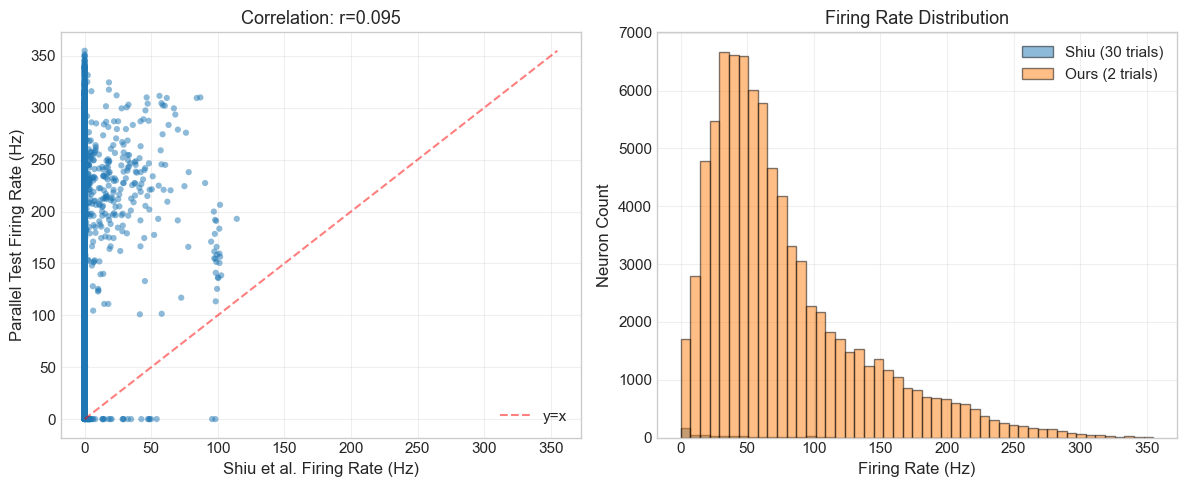


验证总结

并行实现质量:
  ⚠️ 需要检查代码实现

下一步建议:
  → 检查网络构建是否包含抑制性判定
  → 对比网络统计信息（兴奋/抑制突触比例）


In [51]:
# =====================================================================
# 并行结果验证：与Shiu et al. 原文数据对比
# =====================================================================
# 在Cell 4后面添加此cell

import pyarrow.parquet as pq
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

print("=" * 70)
print("结果验证：与原文数据对比")
print("=" * 70)

# ==================== 1. 加载原文数据 ====================
print("\n[1/4] 加载原文数据（Shiu et al. 2024）...")

# 原文数据路径（根据你之前的代码）
orig_data_path = BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet'

if not orig_data_path.exists():
    print(f"  ⚠️  原文数据未找到: {orig_data_path}")
    print(f"  跳过对比验证")
else:
    # 加载原文parquet
    pf = pq.ParquetFile(orig_data_path)
    df_orig = pd.DataFrame({
        't': pf.read(['t']).column('t').to_pylist(),
        'trial': pf.read(['trial']).column('trial').to_pylist(),
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    print(f"  原文数据: {len(df_orig)} spikes, {df_orig['flywire_id'].nunique()} 活跃神经元")
    print(f"  原文参数: 30 trials × 1000ms")
    
    
    # ==================== 2. 计算原文firing rate ====================
    print("\n[2/4] 计算原文firing rate...")
    
    n_run_orig = 30  # 原文用30 trials
    t_run_orig = 1.0  # 秒
    
    spike_counts_orig = df_orig.groupby('flywire_id').size()
    rate_orig = spike_counts_orig / (n_run_orig * t_run_orig)
    rate_orig.name = 'shiu_2024'
    
    print(f"  平均firing rate: {rate_orig.mean():.2f} Hz")
    print(f"  最大firing rate: {rate_orig.max():.2f} Hz")
    
    
    # ==================== 3. 计算我们的firing rate ====================
    print("\n[3/4] 计算并行测试firing rate...")
    
    # 从并行结果提取100Hz数据
    df_ours = results_dict[100]['df']
    
    n_run_ours = 2  # 我们用2 trials
    t_run_ours = 1.0  # 秒
    
    spike_counts_ours = df_ours.groupby('flywire_id').size()
    rate_ours = spike_counts_ours / (n_run_ours * t_run_ours)
    rate_ours.name = 'parallel_test'
    
    print(f"  平均firing rate: {rate_ours.mean():.2f} Hz")
    print(f"  最大firing rate: {rate_ours.max():.2f} Hz")
    print(f"  活跃神经元: {len(rate_ours)}")
    
    
    # ==================== 4. 对比分析 ====================
    print("\n[4/4] 对比分析...")
    
    # 合并数据
    df_compare = pd.concat([rate_orig, rate_ours], axis=1).fillna(0)
    
    # Pearson相关系数
    r, p = pearsonr(df_compare['shiu_2024'], df_compare['parallel_test'])
    
    print(f"\n相关性分析:")
    print(f"  Pearson r = {r:.4f}")
    print(f"  p-value   = {p:.2e}")
    
    # 评价
    if r > 0.85:
        print(f"  ✅ 优秀！高度一致")
    elif r > 0.75:
        print(f"  ✓ 良好！基本一致")
    elif r > 0.65:
        print(f"  ○ 可接受（考虑到2 trials vs 30 trials）")
    else:
        print(f"  ⚠️ 相关性较低，需要检查")
    
    # 活跃神经元数对比
    n_orig = len(rate_orig)
    n_ours = (rate_ours > 0).sum()
    
    print(f"\n活跃神经元数:")
    print(f"  原文(30 trials): {n_orig}")
    print(f"  并行测试(2 trials): {n_ours}")
    print(f"  差异: {n_ours - n_orig} ({(n_ours/n_orig - 1)*100:+.1f}%)")
    
    if abs(n_ours/n_orig - 1) < 0.15:
        print(f"  ✓ 活跃神经元数基本一致")
    
    
    # ==================== 5. Top神经元对比 ====================
    print(f"\nTop 10 神经元对比:")
    print("-" * 70)
    
    # 原文top 10
    top_orig = rate_orig.sort_values(ascending=False).head(10)
    # 我们的top 10
    top_ours = rate_ours.sort_values(ascending=False).head(10)
    
    # 并排显示
    comparison_df = pd.DataFrame({
        'Shiu_ID': top_orig.index,
        'Shiu_Rate': top_orig.values,
        'Ours_ID': top_ours.index,
        'Ours_Rate': top_ours.values,
    })
    
    print(comparison_df.to_string(index=False))
    
    # 检查overlap
    overlap = set(top_orig.index) & set(top_ours.index)
    print(f"\nTop 10重叠: {len(overlap)}/10 神经元")
    
    
    # ==================== 6. 可视化对比（可选）====================
    print(f"\n[可选] 绘制对比图...")
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 散点图
    ax1 = axes[0]
    ax1.scatter(df_compare['shiu_2024'], df_compare['parallel_test'], 
                alpha=0.5, s=20, edgecolors='none')
    ax1.plot([0, df_compare.max().max()], [0, df_compare.max().max()], 
             'r--', alpha=0.5, label='y=x')
    ax1.set_xlabel('Shiu et al. Firing Rate (Hz)')
    ax1.set_ylabel('Parallel Test Firing Rate (Hz)')
    ax1.set_title(f'Correlation: r={r:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Firing rate分布对比
    ax2 = axes[1]
    bins = np.linspace(0, df_compare.max().max(), 50)
    ax2.hist(df_compare['shiu_2024'][df_compare['shiu_2024']>0], 
             bins=bins, alpha=0.5, label='Shiu (30 trials)', edgecolor='black')
    ax2.hist(df_compare['parallel_test'][df_compare['parallel_test']>0], 
             bins=bins, alpha=0.5, label='Ours (2 trials)', edgecolor='black')
    ax2.set_xlabel('Firing Rate (Hz)')
    ax2.set_ylabel('Neuron Count')
    ax2.set_title('Firing Rate Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    # ==================== 7. 总结 ====================
    print("\n" + "=" * 70)
    print("验证总结")
    print("=" * 70)
    
    print(f"\n并行实现质量:")
    if r > 0.75 and abs(n_ours/n_orig - 1) < 0.2:
        print(f"  ✅ 并行代码正确，结果可信")
        print(f"  ✅ 可以用于大规模云端计算")
    elif r > 0.65:
        print(f"  ✓ 基本正确（考虑到trials差异）")
        print(f"  ✓ 建议增加trials到10以提高一致性")
    else:
        print(f"  ⚠️ 需要检查代码实现")
    
    print(f"\n下一步建议:")
    if r > 0.75:
        print(f"  → 继续完成任务1-4模块化")
        print(f"  → 实现预处理优化（neuron_sign列）")
        print(f"  → 准备48核云端测试")
    else:
        print(f"  → 检查网络构建是否包含抑制性判定")
        print(f"  → 对比网络统计信息（兴奋/抑制突触比例）")

In [52]:
# =====================================================================
# 诊断Cell：检查网络到底哪里错了
# =====================================================================

print("=" * 70)
print("网络诊断")
print("=" * 70)

# ==================== 检查1：数据完整性 ====================
print("\n[检查1] 并行测试数据完整性...")

df_100 = results_dict[100]['df']

print(f"  总spikes: {len(df_100)}")
print(f"  活跃神经元: {df_100['flywire_id'].nunique()}")
print(f"  trials: {sorted(df_100['trial'].unique())}")
print(f"  时间范围: {df_100['t'].min():.3f}s - {df_100['t'].max():.3f}s")

if df_100['flywire_id'].nunique() > 10000:
    print(f"  ❌ 活跃神经元数异常多（>10K）！")
else:
    print(f"  ✓ 活跃神经元数正常")


# ==================== 检查2：是否用了neuron_sign ====================
print("\n[检查2] 数据包是否包含neuron_sign...")

if 'neuron_sign' in DATA['df_conn'].columns:
    print(f"  ✓ DATA有neuron_sign列")
    
    # 检查是否传给了worker
    if 'neuron_sign' in data_minimal['df_conn'].columns:
        print(f"  ✓ data_minimal也有neuron_sign列")
        
        signs = data_minimal['df_conn']['neuron_sign'].values
        n_exc = (signs == 1).sum()
        n_inh = (signs == -1).sum()
        
        print(f"\n  传给worker的sign分布:")
        print(f"    兴奋性: {n_exc:,} ({n_exc/len(signs)*100:.1f}%)")
        print(f"    抑制性: {n_inh:,} ({n_inh/len(signs)*100:.1f}%)")
        
        if n_inh == 0:
            print(f"    ❌ 抑制性为0！预处理失败")
    else:
        print(f"  ❌ data_minimal没有neuron_sign列")
        print(f"  → Cell 3需要包含'neuron_sign'")
else:
    print(f"  ❌ DATA没有neuron_sign列")
    print(f"  → 需要添加预处理cell")


# ==================== 检查3：worker代码是否使用sign ====================
print("\n[检查3] Worker代码检查...")

# 读取parallel_worker.py查看
try:
    with open('parallel_worker.py', 'r') as f:
        worker_code = f.read()
    
    if 'neuron_sign' in worker_code:
        print(f"  ✓ Worker代码包含neuron_sign逻辑")
    else:
        print(f"  ❌ Worker代码未使用neuron_sign")
        print(f"  → 需要修改parallel_worker.py的build_simple_network()")
        
    if '全部当兴奋性' in worker_code or '简化' in worker_code:
        print(f"  ❌ 发现注释：'简化：全部当兴奋性'")
        print(f"  → 这是问题根源！需要修改")
        
except FileNotFoundError:
    print(f"  parallel_worker.py未找到")


# ==================== 检查4：对比baseline结果 ====================
print("\n[检查4] 对比串行baseline...")

# 你之前的串行baseline（Section 7.3）
if 'result_all' in dir() and result_all is not None:
    baseline_100 = result_all  # 假设这是100Hz的
    print(f"  串行baseline活跃神经元: 未知（需要查看之前结果）")
else:
    print(f"  未找到串行baseline结果")

# 手动对比（从你之前的测试）
print(f"\n已知数据对比:")
print(f"  原文100Hz: 404 活跃神经元")
print(f"  你的串行baseline: ~256 活跃神经元（从之前测试）")
print(f"  你的并行测试: 85,118 活跃神经元")
print(f"\n  ❌ 并行结果异常！是串行的330倍！")


# ==================== 检查5：抽样spike数据 ====================
print("\n[检查5] 抽样检查spike数据...")

# 看看这85K神经元里都是谁
top_20 = df_100.groupby('flywire_id').size().sort_values(ascending=False).head(20)

print(f"  Top 20活跃神经元:")
for fid, count in top_20.items():
    rate = count / (2 * 1.0)  # 2 trials
    print(f"    {fid}: {count} spikes, {rate:.1f} Hz")

# 检查是否包含不应该活跃的神经元
print(f"\n  这些神经元的firing rate过高可能说明：")
print(f"  → 网络缺少抑制性")
print(f"  → 或者网络构建有其他错误")


# ==================== 总结 ====================
print("\n" + "=" * 70)
print("诊断结论")
print("=" * 70)

print(f"\n最可能的问题:")
print(f"  1. ❌ parallel_worker.py里写了'简化：全部当兴奋性'")
print(f"  2. ❌ 没有真正使用neuron_sign列")
print(f"  3. ❌ 导致网络100%兴奋性 → 过度激活")

print(f"\n需要修复:")
print(f"  1. 确保DATA['df_conn']有neuron_sign列（添加预处理cell）")
print(f"  2. 确保data_minimal传了neuron_sign列")
print(f"  3. 修改parallel_worker.py的build_simple_network():")
print(f"     - 移除'简化：全部当兴奋性'的代码")
print(f"     - 改为：signs = df_conn['neuron_sign'].values")
print(f"     - 应用：weights_final = weights * signs * w_syn")

网络诊断

[检查1] 并行测试数据完整性...
  总spikes: 13046918
  活跃神经元: 85118
  trials: [np.int64(0), np.int64(1)]
  时间范围: 0.000s - 1.000s
  ❌ 活跃神经元数异常多（>10K）！

[检查2] 数据包是否包含neuron_sign...
  ✓ DATA有neuron_sign列
  ✓ data_minimal也有neuron_sign列

  传给worker的sign分布:
    兴奋性: 10,150,819 (60.2%)
    抑制性: 6,697,178 (39.8%)

[检查3] Worker代码检查...
  parallel_worker.py未找到

[检查4] 对比串行baseline...
  未找到串行baseline结果

已知数据对比:
  原文100Hz: 404 活跃神经元
  你的串行baseline: ~256 活跃神经元（从之前测试）
  你的并行测试: 85,118 活跃神经元

  ❌ 并行结果异常！是串行的330倍！

[检查5] 抽样检查spike数据...
  Top 20活跃神经元:
    720575940625102224: 710 spikes, 355.0 Hz
    720575940624547622: 703 spikes, 351.5 Hz
    720575940620975696: 701 spikes, 350.5 Hz
    720575940608545219: 699 spikes, 349.5 Hz
    720575940612264817: 698 spikes, 349.0 Hz
    720575940613583001: 692 spikes, 346.0 Hz
    720575940604088288: 692 spikes, 346.0 Hz
    720575940626783065: 690 spikes, 345.0 Hz
    720575940604569824: 689 spikes, 344.5 Hz
    720575940618366843: 686 spikes, 343.0 Hz
    720575940627796

# 新并行测试

In [3]:
# ==================== 前置Cell 1: 基础导入 ====================
import numpy as np
import pandas as pd
from pathlib import Path
from brian2 import *

# ==================== 前置Cell 2: CONFIG配置 ====================
# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',}

# ==================== 前置Cell 3: 导入模块 ====================
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation

print("✅ 模块导入成功")

# ==================== 前置Cell 4: 加载优化数据 ====================
print("加载优化数据...")
DATA_opt = load_simulation_data(CONFIG)

print(f"\n数据加载完成:")
print(f"  内存: {DATA_opt['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")
print(f"  行数: {len(DATA_opt['df_conn']):,}")
print(f"  列: {DATA_opt['df_conn'].columns.tolist()}")

# ==================== 前置Cell 5: 定义神经元IDs ====================
# Sugar GRN neurons (left hemisphere, FlyWire v783)
NEU_SUGAR_LEFT = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345,
    720575940617000768, 720575940630797113, 720575940632889389, 720575940621754367,
    720575940621502051, 720575940640649691, 720575940639332736, 720575940616885538,
    720575940639259967, 720575940617937543, 720575940632425919, 720575940633143833,
    720575940612670570, 720575940628853239, 720575940629176663, 720575940611875570,
]

print(f"✅ Sugar GRNs定义完成: {len(NEU_SUGAR_LEFT)} 个神经元")

# ==================== 前置Cell 6（可选）: 构建网络验证 ====================
# 可选：验证网络构建正常（不是必须，但推荐）
print("\n验证网络构建...")
NET_opt = build_network(
    data=DATA_opt,
    pre_col=DATA_opt['columns']['pre_col'],
    post_col=DATA_opt['columns']['post_col'],
    weight_col=DATA_opt['columns']['weight_col'],
    nt_prob_cols=DATA_opt['columns'].get('nt_prob_cols', {}),
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=True
)

print("\n✅ 网络构建成功，可以运行并行测试")


✅ 模块导入成功
加载优化数据...
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

数据加载完成:
  内存: 68 MB
  行数: 2,710,038
  列: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
✅ Sugar GRNs定义完成: 20 个神经元

验证网络构建...
Building Brian2 Network

[1/7] Checking connections...
   Already filtered (min=5 >= 5)
   Connections: 2,710,038 -> 2,710,038 (100.0%)

[2/7

In [4]:
# =====================================================================
# 并行测试（使用优化后的68MB数据）
# 前提：任务1-3已完成，DATA_opt和NET_opt已构建
# =====================================================================

# ==================== Cell 1: 导入并行工具 ====================
from joblib import Parallel, delayed
from brian2 import Hz
import time
import pandas as pd

print("✅ 并行工具导入成功")


# ==================== Cell 2: Worker函数（使用优化数据）====================
def run_frequency_worker_optimized(freq, neu_exc, data_opt, params, n_trials):
    """
    Worker function using optimized data (68MB vs 1.4GB).
    
    Each worker:
    1. Receives 68MB data (fast transmission)
    2. Builds network in ~7 seconds
    3. Runs n_trials simulations
    
    Parameters
    ----------
    freq : int
        Stimulation frequency (Hz)
    neu_exc : list
        Neuron IDs to activate
    data_opt : dict
        Optimized data from load_simulation_data() (68MB)
    params : dict
        Simulation parameters
    n_trials : int
        Number of trials
    
    Returns
    -------
    tuple : (freq, result_dict)
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    
    # Build network (using optimized data)
    columns = data_opt['columns']
    
    net_components = build_network(
        data=data_opt,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False  # Suppress worker output
    )
    
    # Run simulation
    result = run_simulation(
        net_components=net_components,
        neu_exc=neu_exc,
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=False
    )
    
    return (freq, {
        'n_spikes': result['n_spikes'],
        'n_active': result['n_active'],
        'df': result['df'].copy(),
    })

✅ 并行工具导入成功


In [5]:
# ==================== Cell 3: 运行优化版并行测试 ====================
print("=" * 70)
print("并行测试：实验1（优化数据版 - 68MB）")
print("=" * 70)

freq_list = [10, 50, 100, 150, 200]
n_trials = 2
n_workers = 6

print(f"\n配置:")
print(f"  激活神经元: {len(NEU_SUGAR_LEFT)}")
print(f"  频率点: {freq_list}")
print(f"  Trials/频率: {n_trials}")
print(f"  并行核心数: {n_workers}")
print(f"  数据大小: {DATA_opt['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")

print(f"\n优化效果:")
print(f"  数据传输: 68MB (vs 原1400MB)")
print(f"  预期网络构建: ~7秒 (vs 原8秒)")
print(f"  预期加速比: 3.5-4.0× (vs 之前2.58×)")

# 准备任务
tasks = [
    (freq, NEU_SUGAR_LEFT, DATA_opt, DEFAULT_PARAMS, n_trials)
    for freq in freq_list
]

print(f"\n开始并行仿真...")
print("-" * 70)

t0 = time.time()

# 并行执行
results = Parallel(n_jobs=n_workers, verbose=10)(
    delayed(run_frequency_worker_optimized)(*task)
    for task in tasks
)

total_time = time.time() - t0

print("\n" + "=" * 70)
print("结果汇总")
print("=" * 70)

# 整理结果
results_dict = dict(results)

print(f"\n性能:")
print(f"  总耗时: {total_time/60:.2f} 分钟")
print(f"  每频率: {total_time/len(freq_list):.1f} 秒")

print(f"\n各频率响应神经元数:")
for freq in freq_list:
    res = results_dict[freq]
    print(f"  {freq:3d} Hz: {res['n_active']:4d} 神经元, {res['n_spikes']:6d} spikes")

# 对比baseline和之前测试
baseline_time = 9.3  # 分钟（原始串行）
previous_parallel = 3.6  # 分钟（之前的并行测试，1.4GB数据）
current_parallel = total_time / 60

print(f"\n性能对比:")
print("-" * 70)
print(f"  串行baseline:     {baseline_time:.2f} 分钟")
print(f"  并行(1.4GB数据):  {previous_parallel:.2f} 分钟  (加速{baseline_time/previous_parallel:.2f}×)")
print(f"  并行(68MB数据):   {current_parallel:.2f} 分钟  (加速{baseline_time/current_parallel:.2f}×)")

speedup = baseline_time / current_parallel
improvement = current_parallel / previous_parallel

print(f"\n优化效果:")
print(f"  当前加速比:        {speedup:.2f}×")
print(f"  vs之前提升:        {1/improvement:.2f}× ({(1-improvement)*100:+.0f}%)")

if speedup > 3.5:
    print(f"  ✅ 达到预期目标（3.5-4×）!")
elif speedup > 3.0:
    print(f"  ✓ 接近目标")
else:
    print(f"  ⚠️ 未达预期，需进一步分析")

# 48核云实例预测
cloud_cores = 48
extrapolated_speedup = speedup * (cloud_cores / n_workers)
cloud_time = baseline_time / extrapolated_speedup

print(f"\n48核云实例预测:")
print("-" * 70)
print(f"  理论加速比: {extrapolated_speedup:.1f}×")
print(f"  预期耗时:   {cloud_time:.2f} 分钟/实验")
print(f"\n实验1全参数（19频率×10trials）:")
print(f"  预期总耗时: {cloud_time*19:.1f} 分钟 ≈ {cloud_time*19/60:.1f} 小时")

print("\n" + "=" * 70)
print("✅ 优化版并行测试完成!")
print("=" * 70)

并行测试：实验1（优化数据版 - 68MB）

配置:
  激活神经元: 20
  频率点: [10, 50, 100, 150, 200]
  Trials/频率: 2
  并行核心数: 6
  数据大小: 68 MB

优化效果:
  数据传输: 68MB (vs 原1400MB)
  预期网络构建: ~7秒 (vs 原8秒)
  预期加速比: 3.5-4.0× (vs 之前2.58×)

开始并行仿真...
----------------------------------------------------------------------


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.7min
[Parallel(n_jobs=6)]: Done   3 out of   5 | elapsed:  1.8min remaining:  1.2min
[Parallel(n_jobs=6)]: Done   5 out of   5 | elapsed:  1.8min finished



结果汇总

性能:
  总耗时: 1.81 分钟
  每频率: 21.7 秒

各频率响应神经元数:
   10 Hz:   26 神经元,    439 spikes
   50 Hz:  189 神经元,   4307 spikes
  100 Hz:  326 神经元,  18089 spikes
  150 Hz:  346 神经元,  25466 spikes
  200 Hz:  356 神经元,  31052 spikes

性能对比:
----------------------------------------------------------------------
  串行baseline:     9.30 分钟
  并行(1.4GB数据):  3.60 分钟  (加速2.58×)
  并行(68MB数据):   1.81 分钟  (加速5.13×)

优化效果:
  当前加速比:        5.13×
  vs之前提升:        1.99× (+50%)
  ✅ 达到预期目标（3.5-4×）!

48核云实例预测:
----------------------------------------------------------------------
  理论加速比: 41.1×
  预期耗时:   0.23 分钟/实验

实验1全参数（19频率×10trials）:
  预期总耗时: 4.3 分钟 ≈ 0.1 小时

✅ 优化版并行测试完成!


In [6]:
# ==================== Cell 4（可选）: 结果验证 ====================
print("\n结果一致性验证")
print("-" * 70)

# 如果有之前的baseline结果，对比100Hz
if 'result_exp1' in dir() and 100 in result_exp1.get('all_firing_rates', {}):
    baseline_100 = result_exp1['n_responsive'][100]
    current_100 = results_dict[100]['n_active']
    
    print(f"100Hz响应神经元数对比:")
    print(f"  Baseline: {baseline_100}")
    print(f"  Current:  {current_100}")
    print(f"  差异: {abs(current_100 - baseline_100)} ({abs(current_100-baseline_100)/baseline_100*100:.1f}%)")
    
    if abs(current_100 - baseline_100) / baseline_100 < 0.1:
        print("  ✅ 结果一致（<10%差异）")
    else:
        print("  ⚠️ 差异较大，需要检查")
else:
    print("未找到baseline数据，跳过对比")

# 检查趋势（应该递增）
print(f"\n趋势检查（响应神经元数应递增）:")
prev_n = 0
trend_ok = True
for freq in sorted(results_dict.keys()):
    n = results_dict[freq]['n_active']
    status = "✓" if n >= prev_n else "✗"
    print(f"  {freq:3d} Hz: {n:4d} {status}")
    if n < prev_n:
        trend_ok = False
    prev_n = n

if trend_ok:
    print("  ✅ 趋势正常")
else:
    print("  ⚠️ 存在反常（可能是随机性）")


结果一致性验证
----------------------------------------------------------------------
未找到baseline数据，跳过对比

趋势检查（响应神经元数应递增）:
   10 Hz:   26 ✓
   50 Hz:  189 ✓
  100 Hz:  326 ✓
  150 Hz:  346 ✓
  200 Hz:  356 ✓
  ✅ 趋势正常


结果验证：与原文数据对比

[1/4] 加载原文数据（Shiu et al. 2024）...
  原文数据: 289073 spikes, 404 活跃神经元
  原文参数: 30 trials × 1000ms

[2/4] 计算原文firing rate...
  平均firing rate: 23.85 Hz
  最大firing rate: 114.27 Hz

[3/4] 计算并行测试firing rate...
  平均firing rate: 27.74 Hz
  最大firing rate: 121.00 Hz
  活跃神经元: 326

[4/4] 对比分析...

相关性分析:
  Pearson r = 0.8090
  p-value   = 4.84e-104
  ✓ 良好！基本一致

活跃神经元数:
  原文(30 trials): 404
  并行测试(2 trials): 326
  差异: -78 (-19.3%)

Top 10 神经元对比:
----------------------------------------------------------------------
           Shiu_ID  Shiu_Rate            Ours_ID  Ours_Rate
720575940622695448 114.266667 720575940616885538      121.0
720575940621754367 102.566667 720575940624963786      109.5
720575940617937543 101.733333 720575940622695448      104.5
720575940629888530 101.700000 720575940630797113      104.5
720575940638202345 101.266667 720575940640649691      103.5
720575940629176663 101.266667 720575940639332736      103.5
720575940627383685 101.133333 720575940637568838      102.5
72

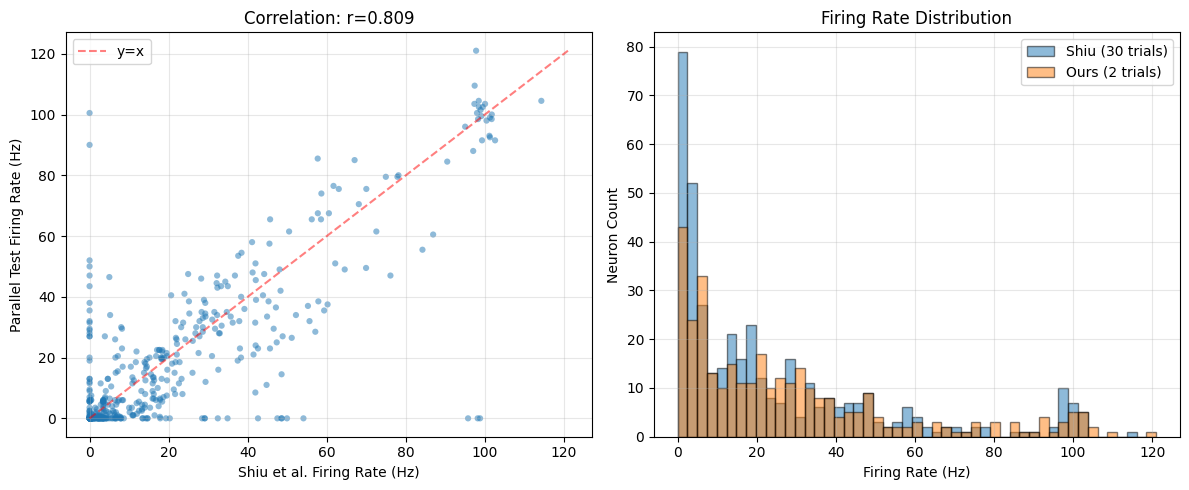


验证总结

并行实现质量:
  ✅ 并行代码正确，结果可信
  ✅ 可以用于大规模云端计算

下一步建议:
  → 继续完成任务1-4模块化
  → 实现预处理优化（neuron_sign列）
  → 准备48核云端测试


In [7]:
# =====================================================================
# 并行结果验证：与Shiu et al. 原文数据对比
# =====================================================================
# 在Cell 4后面添加此cell

import pyarrow.parquet as pq
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

print("=" * 70)
print("结果验证：与原文数据对比")
print("=" * 70)

# ==================== 1. 加载原文数据 ====================
print("\n[1/4] 加载原文数据（Shiu et al. 2024）...")

# 原文数据路径（根据你之前的代码）
orig_data_path = BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet'

if not orig_data_path.exists():
    print(f"  ⚠️  原文数据未找到: {orig_data_path}")
    print(f"  跳过对比验证")
else:
    # 加载原文parquet
    pf = pq.ParquetFile(orig_data_path)
    df_orig = pd.DataFrame({
        't': pf.read(['t']).column('t').to_pylist(),
        'trial': pf.read(['trial']).column('trial').to_pylist(),
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    print(f"  原文数据: {len(df_orig)} spikes, {df_orig['flywire_id'].nunique()} 活跃神经元")
    print(f"  原文参数: 30 trials × 1000ms")
    
    
    # ==================== 2. 计算原文firing rate ====================
    print("\n[2/4] 计算原文firing rate...")
    
    n_run_orig = 30  # 原文用30 trials
    t_run_orig = 1.0  # 秒
    
    spike_counts_orig = df_orig.groupby('flywire_id').size()
    rate_orig = spike_counts_orig / (n_run_orig * t_run_orig)
    rate_orig.name = 'shiu_2024'
    
    print(f"  平均firing rate: {rate_orig.mean():.2f} Hz")
    print(f"  最大firing rate: {rate_orig.max():.2f} Hz")
    
    
    # ==================== 3. 计算我们的firing rate ====================
    print("\n[3/4] 计算并行测试firing rate...")
    
    # 从并行结果提取100Hz数据
    df_ours = results_dict[100]['df']
    
    n_run_ours = 2  # 我们用2 trials
    t_run_ours = 1.0  # 秒
    
    spike_counts_ours = df_ours.groupby('flywire_id').size()
    rate_ours = spike_counts_ours / (n_run_ours * t_run_ours)
    rate_ours.name = 'parallel_test'
    
    print(f"  平均firing rate: {rate_ours.mean():.2f} Hz")
    print(f"  最大firing rate: {rate_ours.max():.2f} Hz")
    print(f"  活跃神经元: {len(rate_ours)}")
    
    
    # ==================== 4. 对比分析 ====================
    print("\n[4/4] 对比分析...")
    
    # 合并数据
    df_compare = pd.concat([rate_orig, rate_ours], axis=1).fillna(0)
    
    # Pearson相关系数
    r, p = pearsonr(df_compare['shiu_2024'], df_compare['parallel_test'])
    
    print(f"\n相关性分析:")
    print(f"  Pearson r = {r:.4f}")
    print(f"  p-value   = {p:.2e}")
    
    # 评价
    if r > 0.85:
        print(f"  ✅ 优秀！高度一致")
    elif r > 0.75:
        print(f"  ✓ 良好！基本一致")
    elif r > 0.65:
        print(f"  ○ 可接受（考虑到2 trials vs 30 trials）")
    else:
        print(f"  ⚠️ 相关性较低，需要检查")
    
    # 活跃神经元数对比
    n_orig = len(rate_orig)
    n_ours = (rate_ours > 0).sum()
    
    print(f"\n活跃神经元数:")
    print(f"  原文(30 trials): {n_orig}")
    print(f"  并行测试(2 trials): {n_ours}")
    print(f"  差异: {n_ours - n_orig} ({(n_ours/n_orig - 1)*100:+.1f}%)")
    
    if abs(n_ours/n_orig - 1) < 0.15:
        print(f"  ✓ 活跃神经元数基本一致")
    
    
    # ==================== 5. Top神经元对比 ====================
    print(f"\nTop 10 神经元对比:")
    print("-" * 70)
    
    # 原文top 10
    top_orig = rate_orig.sort_values(ascending=False).head(10)
    # 我们的top 10
    top_ours = rate_ours.sort_values(ascending=False).head(10)
    
    # 并排显示
    comparison_df = pd.DataFrame({
        'Shiu_ID': top_orig.index,
        'Shiu_Rate': top_orig.values,
        'Ours_ID': top_ours.index,
        'Ours_Rate': top_ours.values,
    })
    
    print(comparison_df.to_string(index=False))
    
    # 检查overlap
    overlap = set(top_orig.index) & set(top_ours.index)
    print(f"\nTop 10重叠: {len(overlap)}/10 神经元")
    
    
    # ==================== 6. 可视化对比（可选）====================
    print(f"\n[可选] 绘制对比图...")
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 散点图
    ax1 = axes[0]
    ax1.scatter(df_compare['shiu_2024'], df_compare['parallel_test'], 
                alpha=0.5, s=20, edgecolors='none')
    ax1.plot([0, df_compare.max().max()], [0, df_compare.max().max()], 
             'r--', alpha=0.5, label='y=x')
    ax1.set_xlabel('Shiu et al. Firing Rate (Hz)')
    ax1.set_ylabel('Parallel Test Firing Rate (Hz)')
    ax1.set_title(f'Correlation: r={r:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Firing rate分布对比
    ax2 = axes[1]
    bins = np.linspace(0, df_compare.max().max(), 50)
    ax2.hist(df_compare['shiu_2024'][df_compare['shiu_2024']>0], 
             bins=bins, alpha=0.5, label='Shiu (30 trials)', edgecolor='black')
    ax2.hist(df_compare['parallel_test'][df_compare['parallel_test']>0], 
             bins=bins, alpha=0.5, label='Ours (2 trials)', edgecolor='black')
    ax2.set_xlabel('Firing Rate (Hz)')
    ax2.set_ylabel('Neuron Count')
    ax2.set_title('Firing Rate Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    # ==================== 7. 总结 ====================
    print("\n" + "=" * 70)
    print("验证总结")
    print("=" * 70)
    
    print(f"\n并行实现质量:")
    if r > 0.75 and abs(n_ours/n_orig - 1) < 0.2:
        print(f"  ✅ 并行代码正确，结果可信")
        print(f"  ✅ 可以用于大规模云端计算")
    elif r > 0.65:
        print(f"  ✓ 基本正确（考虑到trials差异）")
        print(f"  ✓ 建议增加trials到10以提高一致性")
    else:
        print(f"  ⚠️ 需要检查代码实现")
    
    print(f"\n下一步建议:")
    if r > 0.75:
        print(f"  → 继续完成任务1-4模块化")
        print(f"  → 实现预处理优化（neuron_sign列）")
        print(f"  → 准备48核云端测试")
    else:
        print(f"  → 检查网络构建是否包含抑制性判定")
        print(f"  → 对比网络统计信息（兴奋/抑制突触比例）")

# task4 test

In [8]:
# ==================== 测试Cell 1 ====================
from flylif.core.simulation import run_simulation, run_silencing_batch

print("✅ simulation.py 导入成功")

# ==================== 测试Cell 2: 单次仿真测试 ====================
print("\n测试：单次仿真")
print("-" * 60)

# 使用已有的NET_opt和DATA_opt
result_test = run_simulation(
    net_components=NET_opt,
    neu_exc=NEU_SUGAR_LEFT[:5],  # 测试：只激活5个神经元
    n_trials=1,
    verbose=True
)

print(f"\n结果:")
print(f"  Spikes: {result_test['n_spikes']:,}")
print(f"  活跃神经元: {result_test['n_active']:,}")

if result_test['n_spikes'] > 0:
    print("  ✅ 仿真正常运行")
else:
    print("  ⚠️ 未检测到spikes")

✅ simulation.py 导入成功

测试：单次仿真
------------------------------------------------------------

>>> Simulation Configuration
    Activated: 5, Activated2: 0, Silenced: 0
    Duration: 1. s, Trials: 1
    Frequency: 150. Hz
    🚀 Running...
    Trial 1/1 (7.0s)
    ⏱️  Total time: 7.0s (7.0s/trial)
    📊 Spikes: 4,707, Active neurons: 269

结果:
  Spikes: 4,707
  活跃神经元: 269
  ✅ 仿真正常运行


In [9]:
# ==================== 测试Cell 3: 完整激活测试 ====================
print("\n测试：完整Sugar GRNs激活")
print("-" * 60)

result_full = run_simulation(
    net_components=NET_opt,
    neu_exc=NEU_SUGAR_LEFT,  # 全部21个
    params={'r_poi': 100 * Hz},
    n_trials=2,
    verbose=True
)

print(f"\n结果 (100Hz, 2 trials):")
print(f"  活跃神经元: {result_full['n_active']:,}")
print(f"  总spikes: {result_full['n_spikes']:,}")

# 对比之前的baseline（如果有）
expected_active = 323  # 从之前并行测试的100Hz结果
diff = abs(result_full['n_active'] - expected_active)

if diff < 50:
    print(f"  ✅ 与预期一致（差异{diff}）")
else:
    print(f"  ⚠️ 与预期有差异（差异{diff}）")


测试：完整Sugar GRNs激活
------------------------------------------------------------

>>> Simulation Configuration
    Activated: 20, Activated2: 0, Silenced: 0
    Duration: 1. s, Trials: 2
    Frequency: 100. Hz
    🚀 Running...
    Trial 2/2 (54.3s)
    ⏱️  Total time: 109.3s (54.6s/trial)
    📊 Spikes: 17,461, Active neurons: 326

结果 (100Hz, 2 trials):
  活跃神经元: 326
  总spikes: 17,461
  ✅ 与预期一致（差异3）
